In [ ]:
%pip install "numpy>=2.0,<2.3" --force-reinstall

In [29]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import mplhep as hep
import yaml
from collections import defaultdict
import math
import pandas as pd
from IPython.display import display, Markdown
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
import re


In [30]:
yaml_file_path = '../../configs/ntuples/signal_2mu2e_v10.yaml'
# Open and read the YAML file
with open(yaml_file_path, 'r') as file:
    data = yaml.safe_load(file)
signals_2mu2e_all = list(data["llpNanoAOD_v2"]["samples"].keys())


In [31]:
output_dir = Path("Mother_Tracking_LJ_Kinematics_SIG")
out = {}

for sample in signals_2mu2e_all:
    path = output_dir / f"{sample}.coffea"

    if not path.exists():
        print(f"Missing: {sample}")
        continue

    loaded = coffea.util.load(path)

    if "out" in loaded:
        out[sample] = loaded["out"][sample]
    else:
        out[sample] = loaded[sample] if sample in loaded else loaded

print(f"Loaded {len(out)} / {len(signals_2mu2e_all)} 2Mu2E signal samples")


Loaded 90 / 90 2Mu2E signal samples


In [32]:
channels = [
    "data_control_region_1muLj_cosmic_veto",
    "data_control_region_1egmLj_cosmic_veto",
    "data_control_region_1muLj_1egmLj_cosmic_veto",
    "data_control_region_2muLj_cosmic_veto",
]


In [33]:
SIGNAL_CATEGORY_ORDER = [
    "Dark Photon", "e", r"$\mu$", "Quark/Gluon", "Others",
]

OBJECT_HISTOGRAMS = {
    "Electron": "fs_e_gen_mother_id",
    "Muon": "fs_mu_gen_mother_id",
    "Photon": "fs_pho_gen_mother_id",
}

def categorize_signal_mother(pdgid):
    abs_id = abs(pdgid)
    if abs_id == 32:
        return "Dark Photon"
    if abs_id == 11:
        return "e"
    if abs_id == 13:
        return r"$\mu$"
    if abs_id in (1, 2, 3, 4, 5, 6, 9, 21):
        return "Quark/Gluon"
    return "Others"

def get_sample_output(output, sample):
    if isinstance(output, dict) and "out" in output:
        return output["out"][sample]
    return output[sample]

def get_channel_histogram(sample_output, histogram_name, channel):
    return sample_output["hists"][histogram_name][channel, :]

def histogram_values_and_variances(histogram):
    values = np.asarray(histogram.values(flow=False), dtype=float)

    try:
        variances = histogram.variances(flow=False)
    except TypeError:
        variances = histogram.variances()
    except Exception:
        variances = None

    if variances is None:
        variances = np.abs(values)
    else:
        variances = np.asarray(variances, dtype=float)
        variances = np.where(np.isfinite(variances) & (variances >= 0), variances, 0.0)

    return values, variances

def sum_hist_values_and_variances(output, sample_names, channel, histogram_name):
    values = None
    variances = None

    for sample in sample_names:
        try:
            sample_output = get_sample_output(output, sample)
        except KeyError:
            print(f"[WARNING] sample not found: {sample}. Skipping.")
            continue

        if histogram_name not in sample_output["hists"]:
            print(f"[WARNING] histogram not found for {sample}: {histogram_name}. Skipping.")
            continue

        sample_hist = get_channel_histogram(sample_output, histogram_name, channel)
        sample_values, sample_variances = histogram_values_and_variances(sample_hist)

        values = sample_values.copy() if values is None else values + sample_values
        variances = sample_variances.copy() if variances is None else variances + sample_variances

    if values is None:
        raise RuntimeError(
            f"No valid histogram values found for histogram={histogram_name}, channel={channel}"
        )

    return values, variances

def categorize_hist_values_and_variances(values, variances, categorizer):
    category_counts = defaultdict(float)
    category_variances = defaultdict(float)
    other_counts = defaultdict(float)

    for pdgid, (count, variance) in enumerate(zip(values, variances)):
        if count == 0 and variance == 0:
            continue

        category = categorizer(pdgid)
        category_counts[category] += float(count)
        category_variances[category] += float(variance)

        if category == "Others":
            other_counts[pdgid] += float(count)

    return category_counts, category_variances, other_counts

def make_category_tables(output, sample_groups, channel, histogram_name, categorizer, category_order):
    yields = {}
    variances = {}
    other_details = {}

    for group, sample_names in sample_groups.items():
        values, summed_variances = sum_hist_values_and_variances(
            output,
            sample_names,
            channel,
            histogram_name,
        )
        group_counts, group_variances, group_other = categorize_hist_values_and_variances(
            values,
            summed_variances,
            categorizer,
        )
        yields[group] = group_counts
        variances[group] = group_variances
        other_details[group] = group_other

    yield_table = pd.DataFrame(yields).T.fillna(0)
    yield_table = yield_table.reindex(columns=category_order, fill_value=0)

    variance_table = pd.DataFrame(variances).T.fillna(0)
    variance_table = variance_table.reindex(columns=category_order, fill_value=0)
    error_table = np.sqrt(variance_table)

    other_table = pd.DataFrame(other_details).T.fillna(0)
    if not other_table.empty:
        other_table = other_table.loc[:, (other_table != 0).any(axis=0)]
        other_table = other_table.reindex(sorted(other_table.columns), axis=1)

    return yield_table, error_table, other_table

def make_object_category_table(output, sample_names, channel, categorizer, category_order):
    object_counts = {}

    for object_name, histogram_name in OBJECT_HISTOGRAMS.items():
        values, variances = sum_hist_values_and_variances(output, sample_names, channel, histogram_name)
        object_counts[object_name], _, _ = categorize_hist_values_and_variances(values, variances, categorizer)

    return pd.DataFrame(object_counts).fillna(0).reindex(category_order, fill_value=0)


In [34]:
SIGNAL_MASS_ORDER = ["100GeV", "150GeV", "200GeV", "500GeV", "800GeV", "1000GeV"]
SIGNAL_DARK_PHOTON_MASS_ORDER = ["0p25GeV", "1p2GeV", "5p0GeV"]

def make_signal_mass_groups(signal_samples):
    signal_mass_groups = defaultdict(list)

    for sample in signal_samples:
        parts = sample.split("_")
        if len(parts) < 4:
            print(f"[WARNING] unexpected signal sample name: {sample}")
            continue
        signal_mass_groups[parts[1]].append(sample)

    return {
        mass: sorted(signal_mass_groups[mass])
        for mass in SIGNAL_MASS_ORDER
        if mass in signal_mass_groups
    }

def make_signal_detail_groups(signal_samples):
    signal_detail_groups = defaultdict(list)

    for sample in signal_samples:
        parts = sample.split("_")
        if len(parts) < 4:
            print(f"[WARNING] unexpected signal sample name: {sample}")
            continue
        group_name = "_".join(parts[1:3])
        signal_detail_groups[group_name].append(sample)

    ordered_groups = {}
    for mass in SIGNAL_MASS_ORDER:
        for dark_photon_mass in SIGNAL_DARK_PHOTON_MASS_ORDER:
            group_name = f"{mass}_{dark_photon_mass}"
            if group_name in signal_detail_groups:
                ordered_groups[group_name] = sorted(signal_detail_groups[group_name])

    return ordered_groups

def make_signal_lxy_groups(signal_samples):
    return {
        sample: [sample]
        for sample in sorted(signal_samples)
    }

signal_samples_loaded = [
    sample for sample in out.keys()
    if sample.startswith(("2Mu2E_"))
]

signal_mass_groups = make_signal_mass_groups(signal_samples_loaded)
signal_detail_groups = make_signal_detail_groups(signal_samples_loaded)
signal_lxy_groups = make_signal_lxy_groups(signal_samples_loaded)


In [35]:
MASS_COLORS = {
    "100GeV": "#3f90da",
    "150GeV": "#ffa90e",
    "200GeV": "#bd1f01",
    "500GeV": "#94a4a2",
    "800GeV": "#832db6",
    "1000GeV": "#a96b59",
}

DETAIL_COLORS = {
    "100GeV_0p25GeV": "#3f90da",
    "100GeV_1p2GeV": "#6aaed6",
    "100GeV_5p0GeV": "#9ecae1",
    "150GeV_0p25GeV": "#ffa90e",
    "150GeV_1p2GeV": "#f7c267",
    "150GeV_5p0GeV": "#fdd49e",
    "200GeV_0p25GeV": "#bd1f01",
    "200GeV_1p2GeV": "#e34a33",
    "200GeV_5p0GeV": "#fcae91",
    "500GeV_0p25GeV": "#94a4a2",
    "500GeV_1p2GeV": "#6b8f8f",
    "500GeV_5p0GeV": "#b7c7c4",
    "800GeV_0p25GeV": "#832db6",
    "800GeV_1p2GeV": "#9e67c7",
    "800GeV_5p0GeV": "#c2a5df",
    "1000GeV_0p25GeV": "#a96b59",
    "1000GeV_1p2GeV": "#c58b7c",
    "1000GeV_5p0GeV": "#d8b3a7",
}

LXY_COLORS = {
    sample: color
    for sample, color in zip(
        signal_lxy_groups,
        [
            "#3f90da", "#ffa90e", "#bd1f01", "#94a4a2", "#832db6",
            "#a96b59", "#e76300", "#b9ac70", "#92dadd", "#964a8b",
        ] * 20,
    )
}

PROCESS_COLORS = {
    **MASS_COLORS,
    **DETAIL_COLORS,
    **LXY_COLORS,
}

def add_bar_errorbars(ax, table, error_table, color="black", capsize=2, elinewidth=1.1):
    if error_table is None:
        return

    aligned_errors = error_table.reindex(index=table.index, columns=table.columns).fillna(0.0)

    for process, container in zip(table.index, ax.containers):
        if process not in aligned_errors.index:
            continue
        errors = aligned_errors.loc[process, table.columns].to_numpy(dtype=float)
        centers = np.array([patch.get_x() + patch.get_width() / 2 for patch in container.patches])
        heights = np.array([patch.get_height() for patch in container.patches], dtype=float)
        visible = np.isfinite(heights) & np.isfinite(errors) & (heights > 0)
        if np.any(visible):
            ax.errorbar(
                centers[visible],
                heights[visible],
                yerr=errors[visible],
                fmt="none",
                ecolor=color,
                elinewidth=elinewidth,
                capsize=capsize,
                zorder=5,
            )

def plot_category_table(
    table,
    title,
    ylabel,
    logy=False,
    ylim=None,
    figsize=(24, 12),
    color_map=None,
    legend_title="Signal",
    error_table=None,
):
    colors = None
    if color_map is not None:
        colors = [
            color_map.get(process, None)
            for process in table.index
        ]

    ax = table.T.plot(
        kind="bar",
        figsize=figsize,
        width=0.8,
        logy=logy,
        color=colors,
        edgecolor="black",
    )

    add_bar_errorbars(ax, table, error_table)

    ax.set_title(title)
    ax.set_xlabel("Mother category")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(
        title=legend_title,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    if ylim is not None:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()
    plt.close()


In [36]:
def make_signal_category_tables(
    output,
    signal_groups,
    channel,
    histogram_name="fs_gen_mother_id",
    categorizer=categorize_signal_mother,
    category_order=SIGNAL_CATEGORY_ORDER,
):
    return make_category_tables(
        output=output,
        sample_groups=signal_groups,
        channel=channel,
        histogram_name=histogram_name,
        categorizer=categorizer,
        category_order=category_order,
    )

def make_and_show_signal_set(
    output,
    signal_groups,
    channel,
    set_label,
    table_store,
    histogram_name="fs_gen_mother_id",
    figsize=(24, 12),
    color_map=None,
    legend_title="Signal",
):
    yield_table, error_table, other_table = make_signal_category_tables(
        output=output,
        signal_groups=signal_groups,
        channel=channel,
        histogram_name=histogram_name,
        categorizer=categorize_signal_mother,
        category_order=SIGNAL_CATEGORY_ORDER,
    )

    table_store[channel] = {
        "yield": yield_table,
        "error": error_table,
        "other": other_table,
    }

    print()
    print("-" * 120)
    print(f"{channel}: {set_label}")
    print("-" * 120)

    plot_inputs = [("Inclusive", yield_table, error_table)]

    if histogram_name == "fs_gen_mother_id":
        table_store[channel]["objects"] = {}
        for object_name, object_histogram_name in OBJECT_HISTOGRAMS.items():
            object_yield_table, object_error_table, object_other_table = make_signal_category_tables(
                output=output,
                signal_groups=signal_groups,
                channel=channel,
                histogram_name=object_histogram_name,
                categorizer=categorize_signal_mother,
                category_order=SIGNAL_CATEGORY_ORDER,
            )
            table_store[channel]["objects"][object_name] = {
                "yield": object_yield_table,
                "error": object_error_table,
                "other": object_other_table,
            }
            plot_inputs.append((object_name, object_yield_table, object_error_table))

    for object_label, plot_yield_table, plot_error_table in plot_inputs:
        title_label = set_label if object_label == "Inclusive" else f"{set_label} ({object_label})"

        plot_category_table(
            plot_yield_table,
            f"{channel}: {title_label} mother composition",
            "Weighted object yield",
            logy=True,
            figsize=figsize,
            color_map=color_map,
            legend_title=legend_title,
            error_table=plot_error_table,
        )

    return yield_table, error_table, other_table



Channel: data_control_region_1muLj_cosmic_veto

------------------------------------------------------------------------------------------------------------------------
data_control_region_1muLj_cosmic_veto: inclusive signal mass
------------------------------------------------------------------------------------------------------------------------


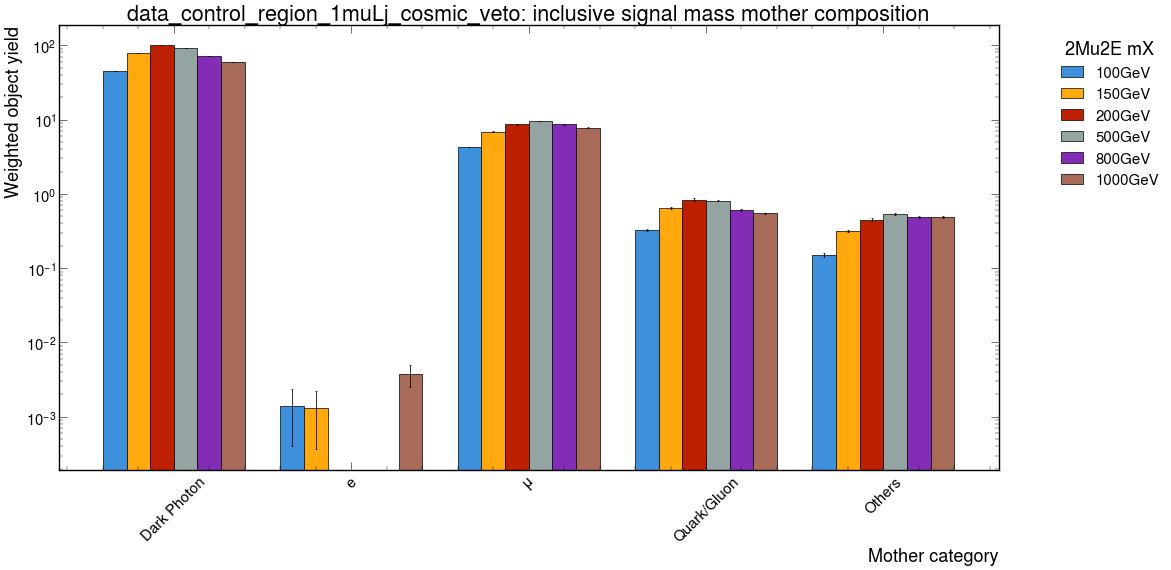

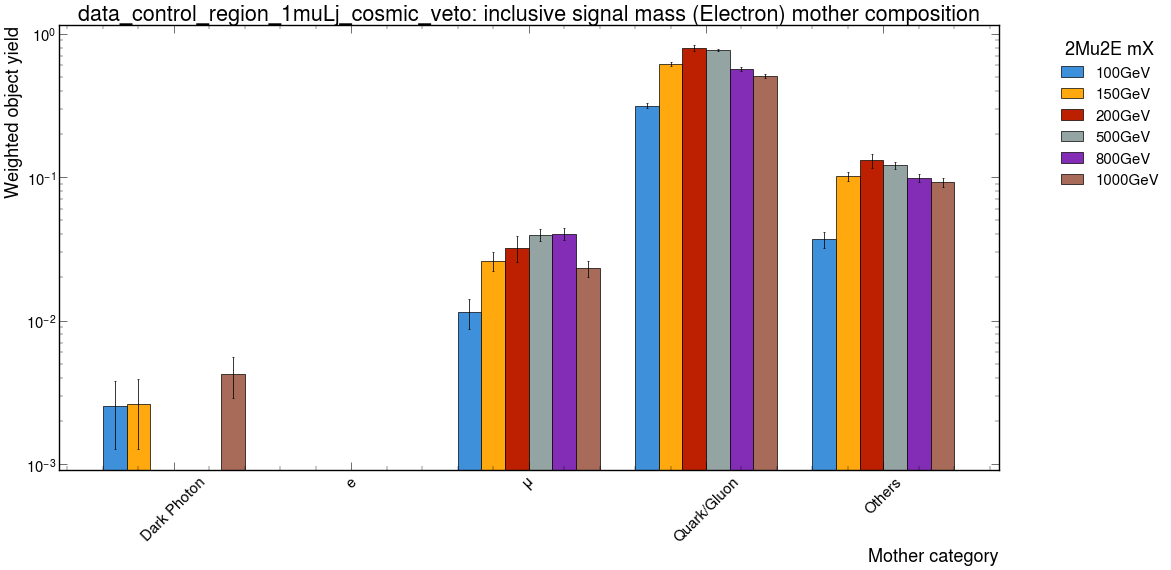

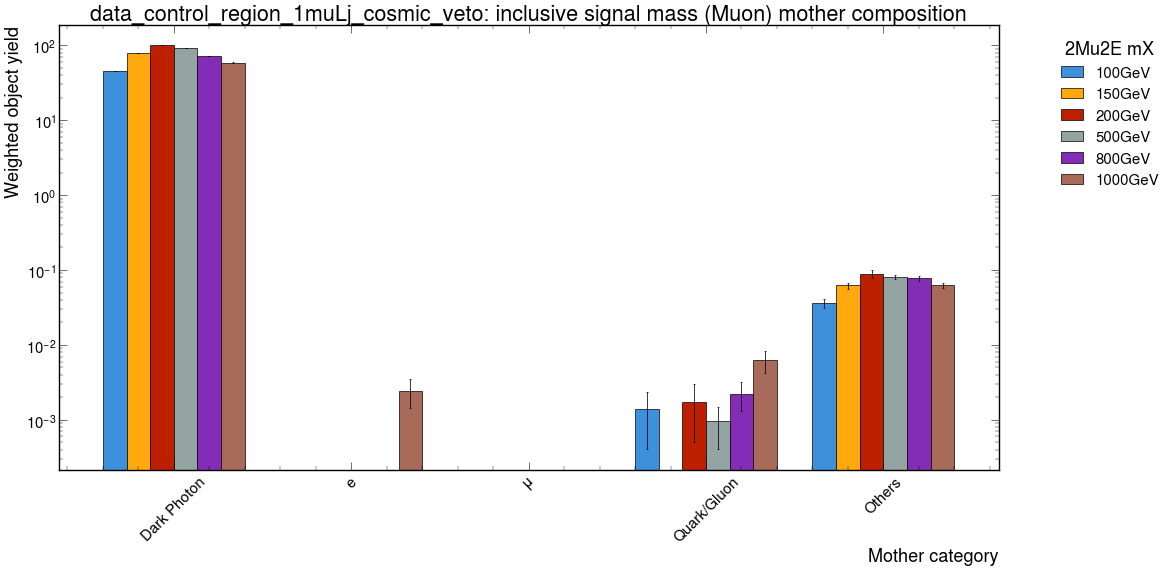

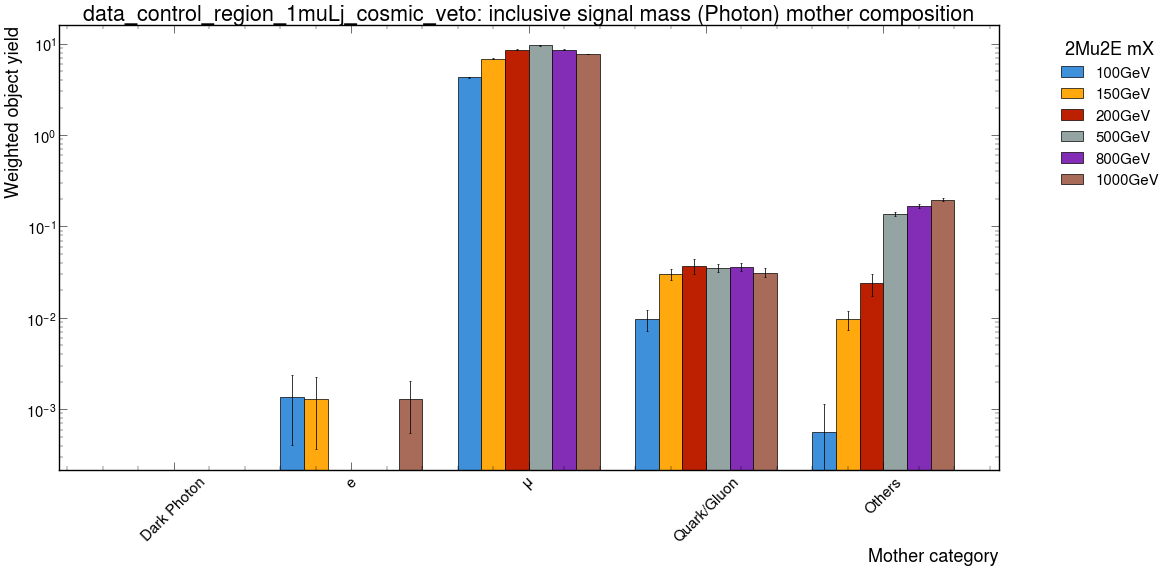


Channel: data_control_region_1egmLj_cosmic_veto

------------------------------------------------------------------------------------------------------------------------
data_control_region_1egmLj_cosmic_veto: inclusive signal mass
------------------------------------------------------------------------------------------------------------------------


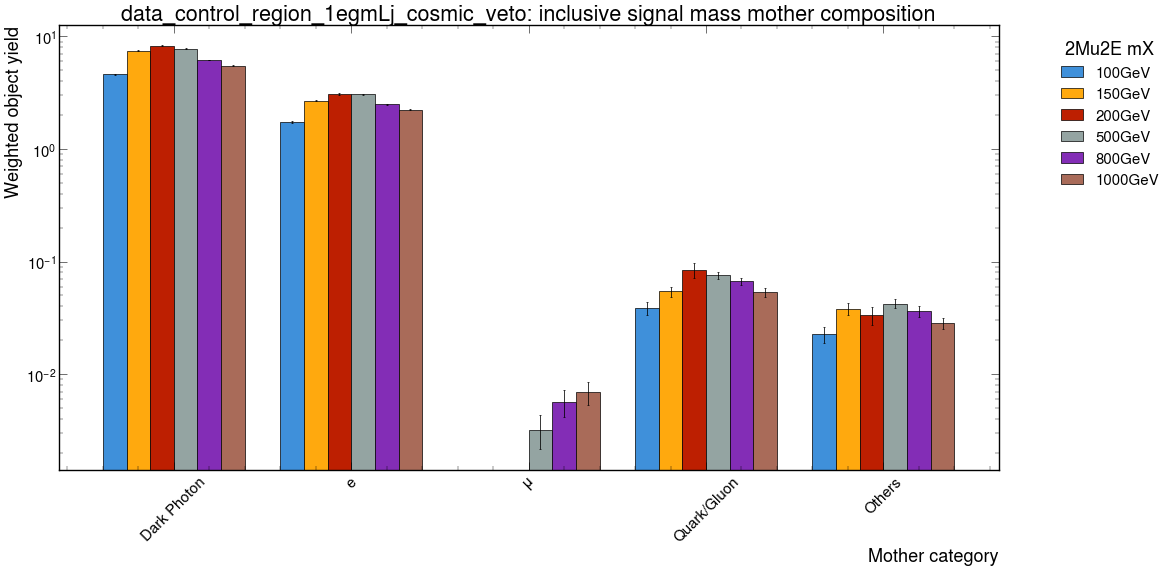

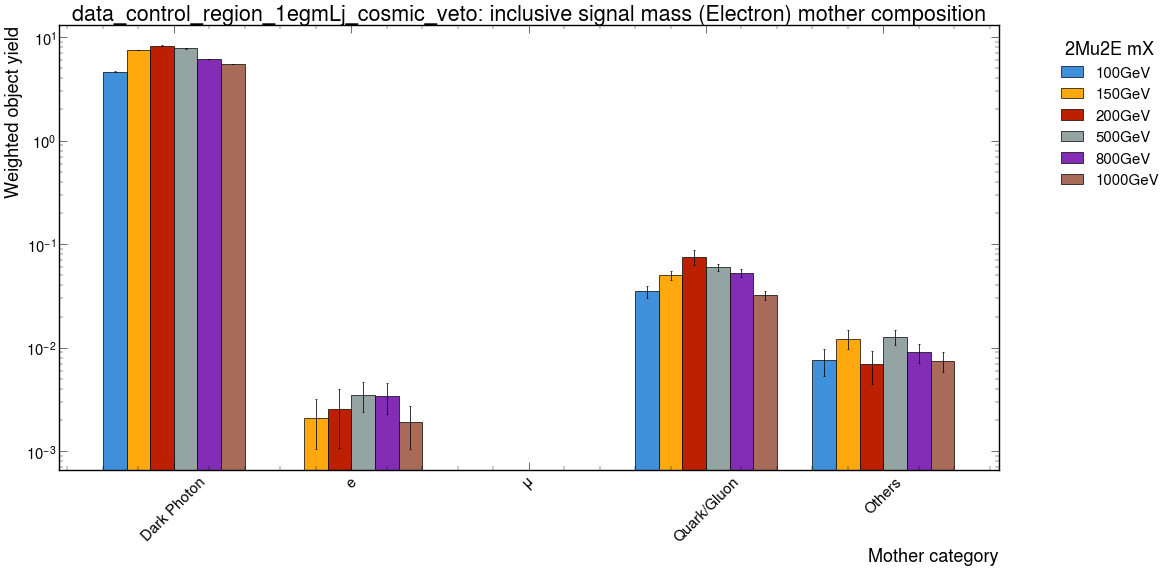

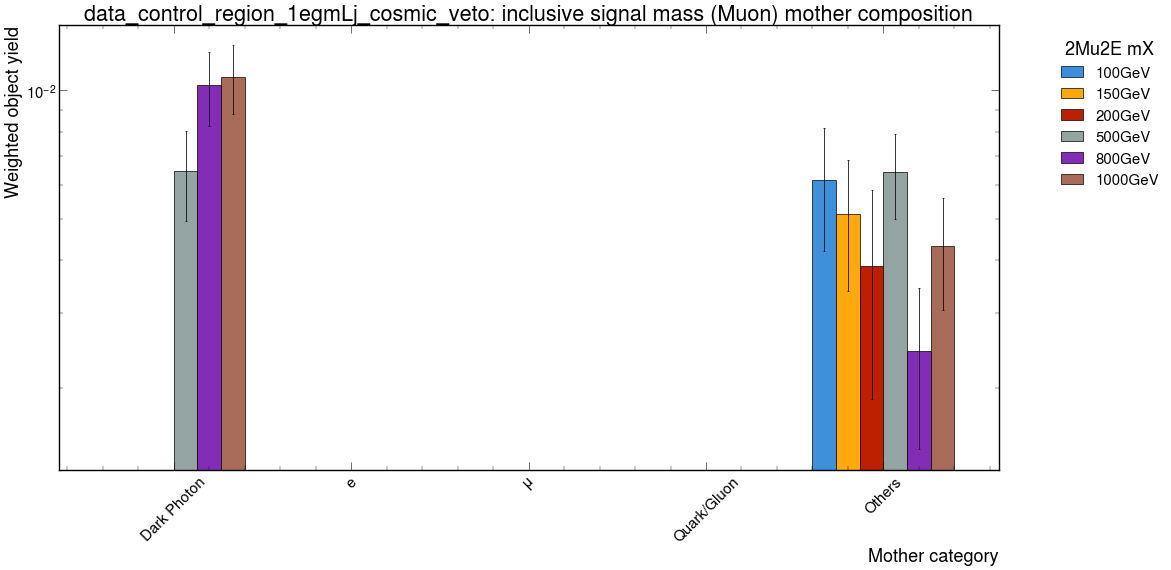

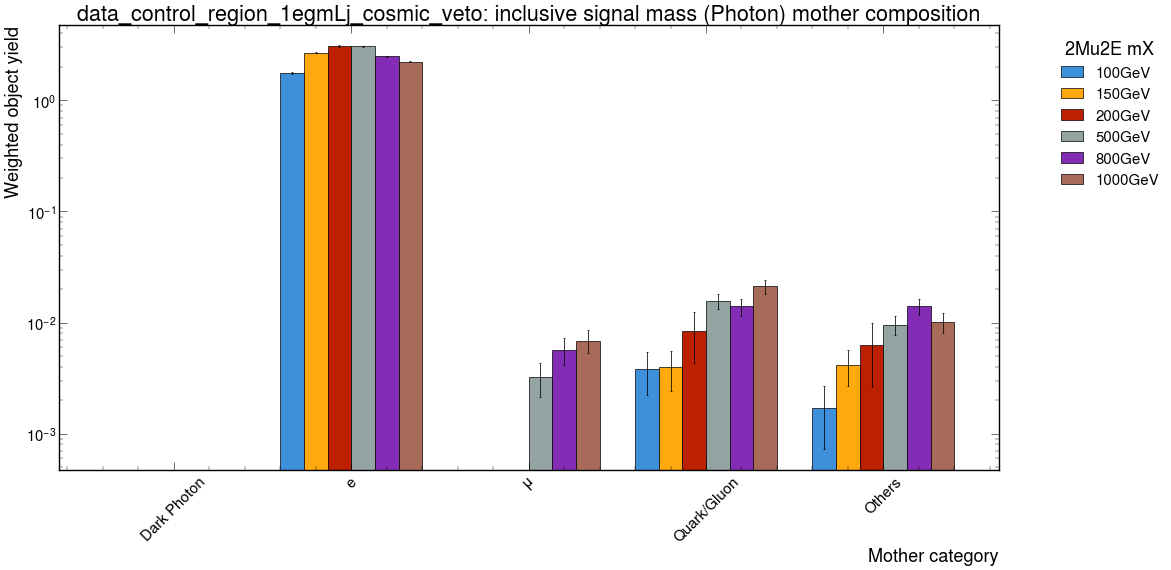


Channel: data_control_region_1muLj_1egmLj_cosmic_veto

------------------------------------------------------------------------------------------------------------------------
data_control_region_1muLj_1egmLj_cosmic_veto: inclusive signal mass
------------------------------------------------------------------------------------------------------------------------


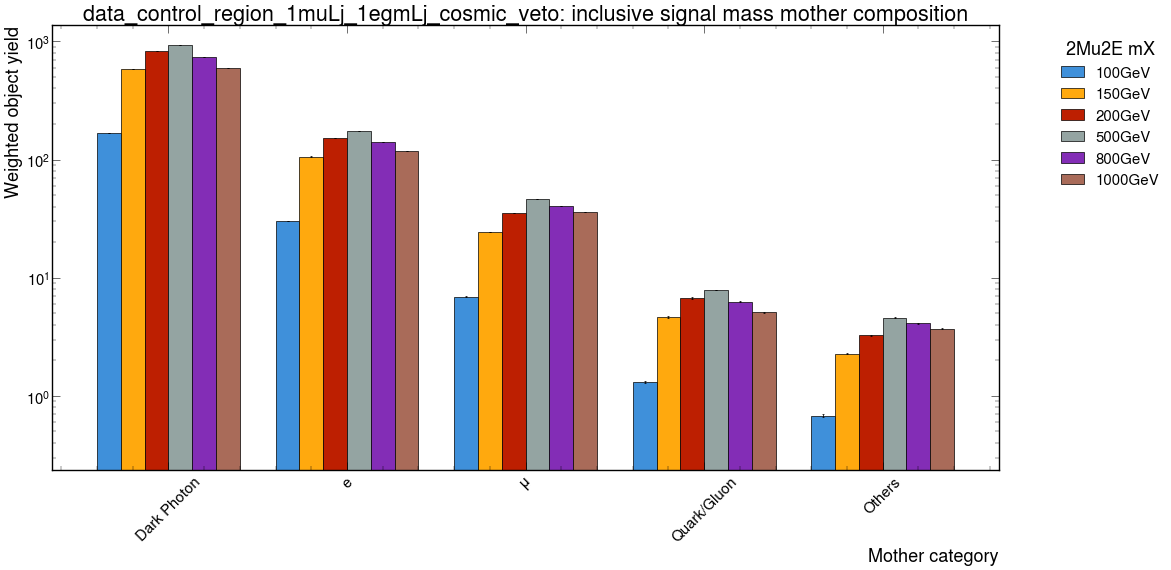

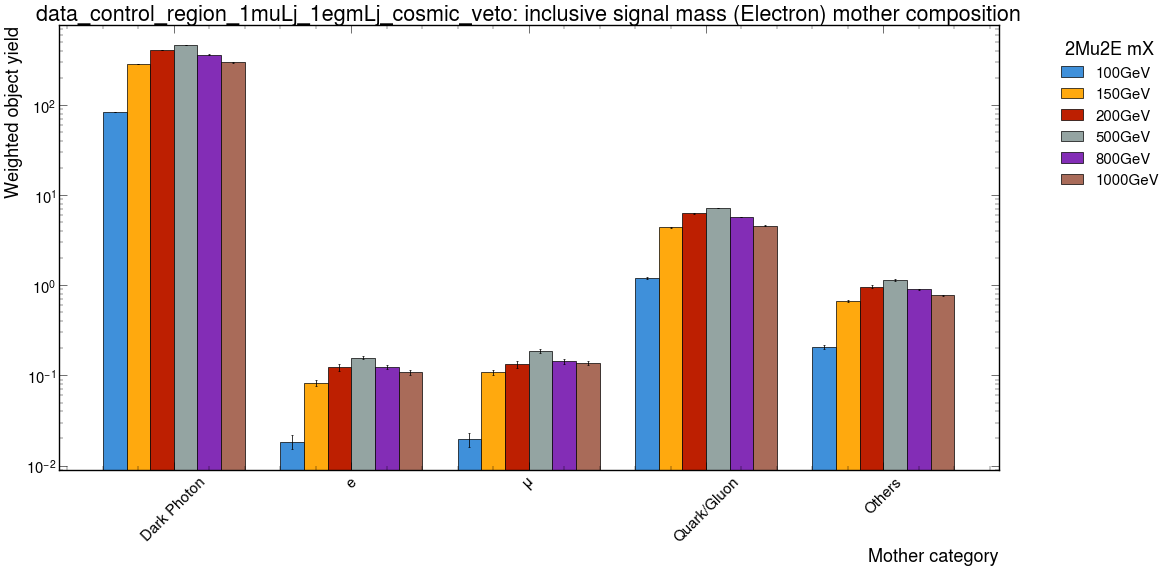

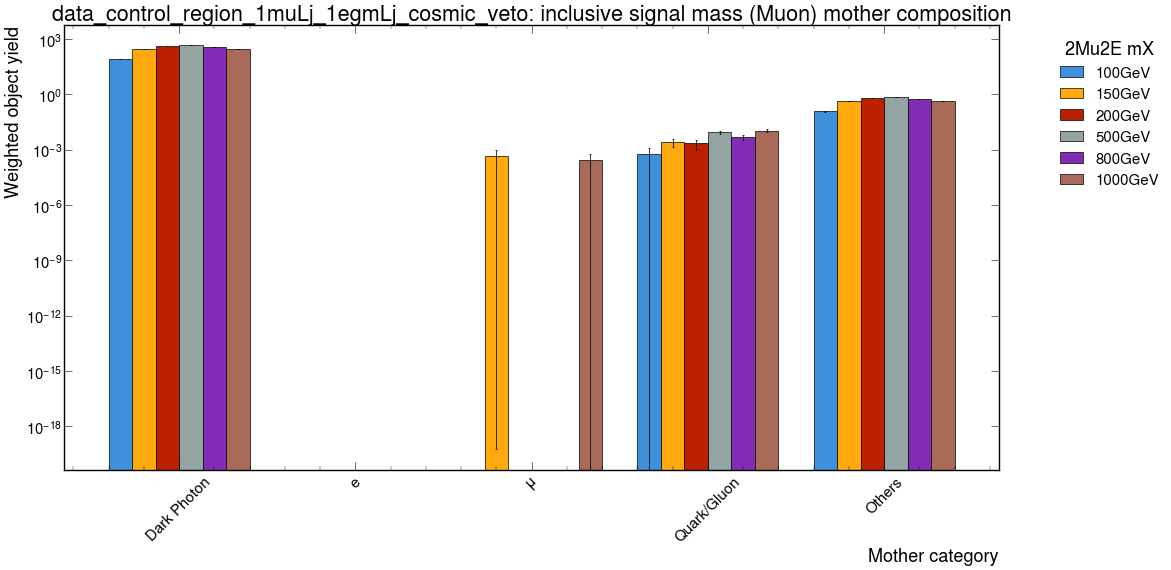

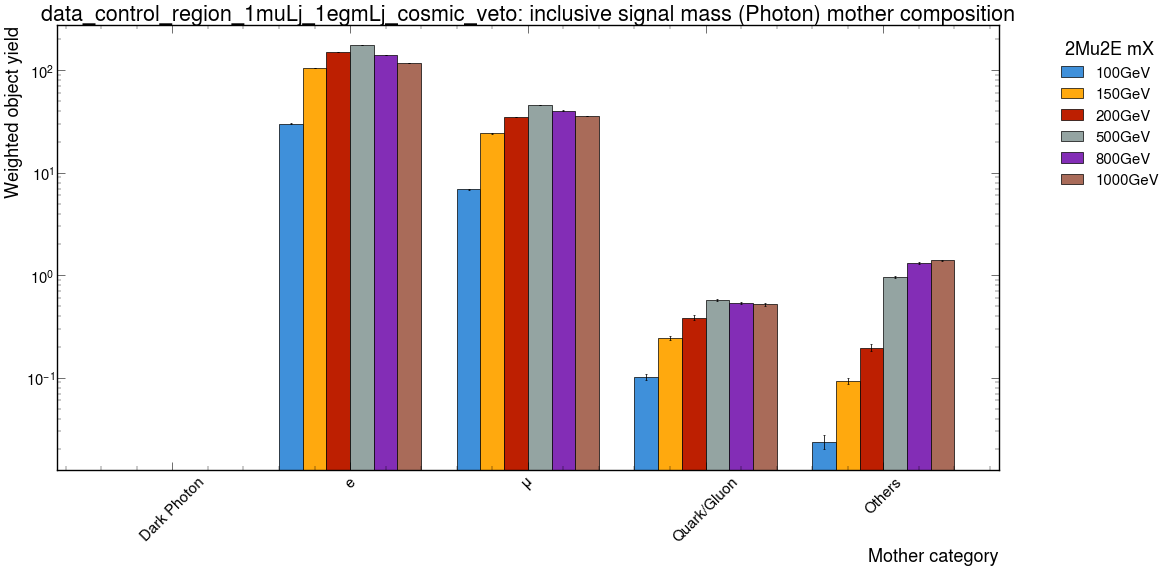


Channel: data_control_region_2muLj_cosmic_veto

------------------------------------------------------------------------------------------------------------------------
data_control_region_2muLj_cosmic_veto: inclusive signal mass
------------------------------------------------------------------------------------------------------------------------


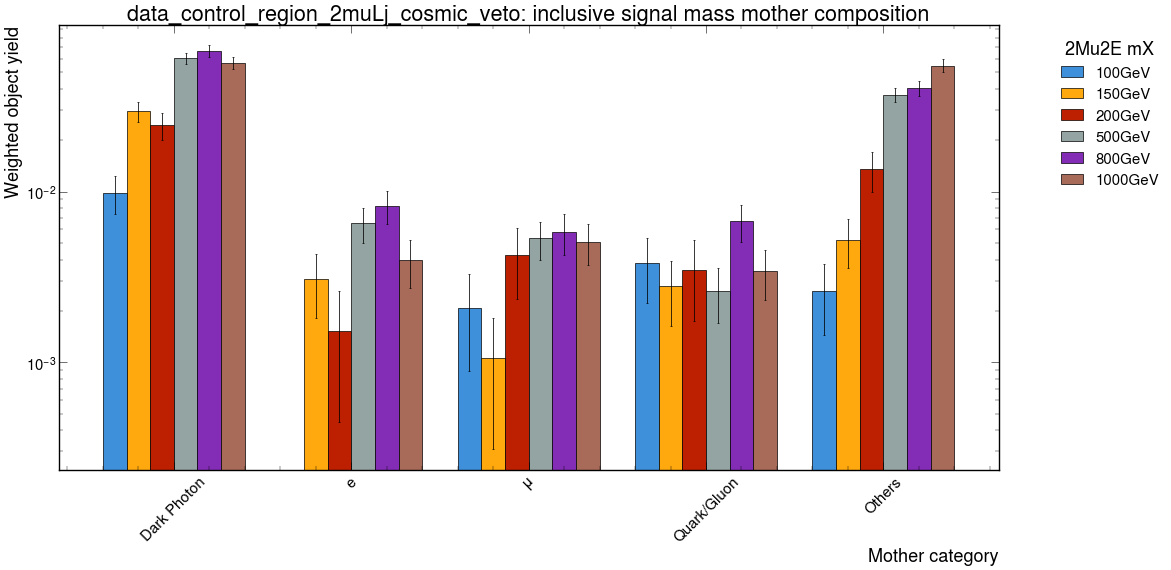

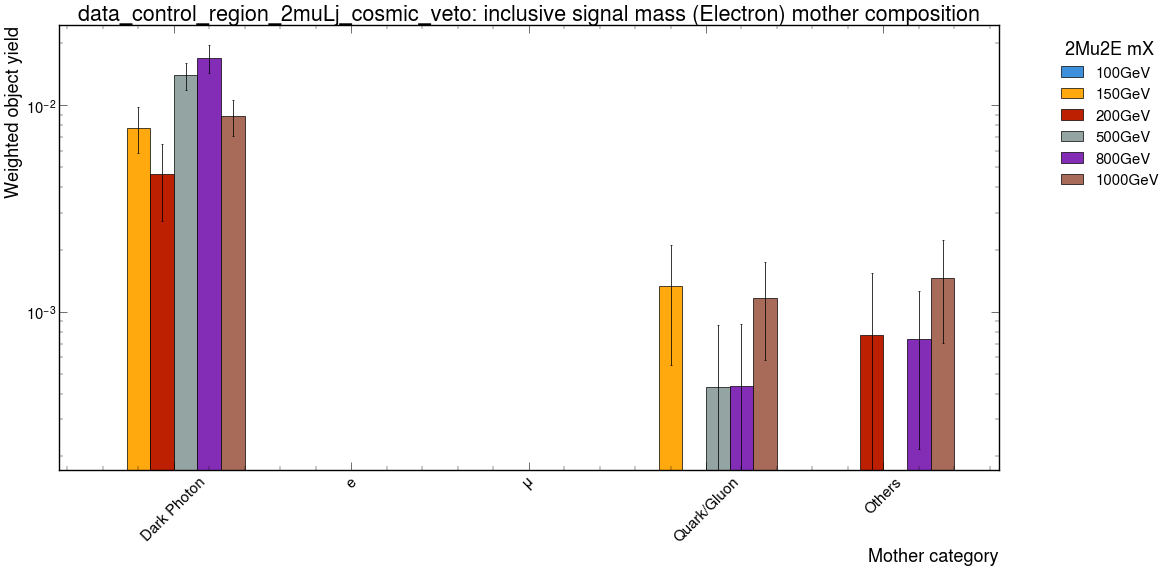

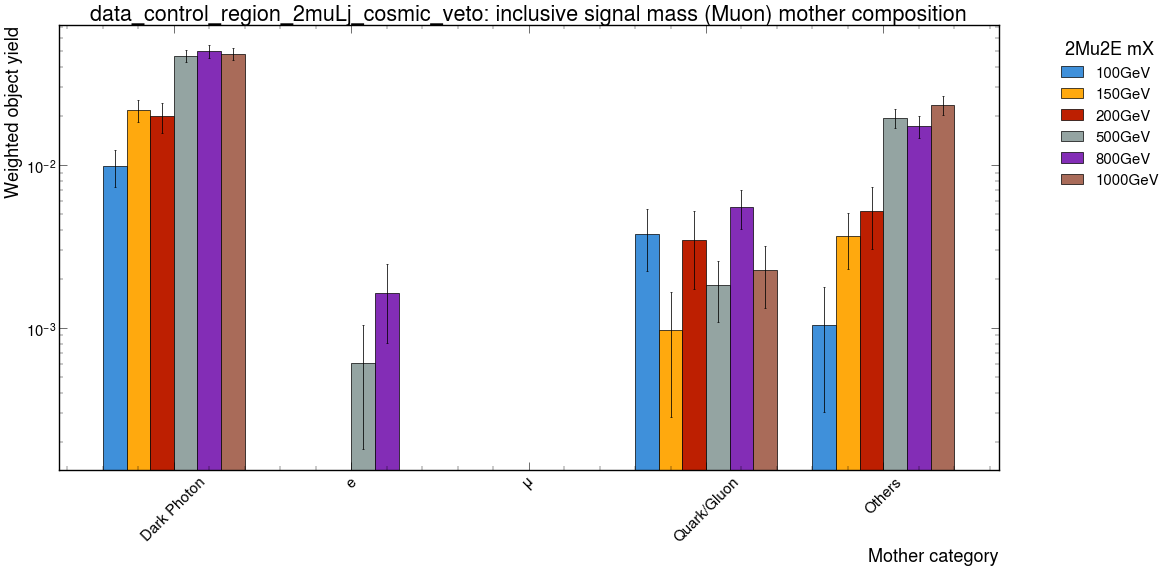

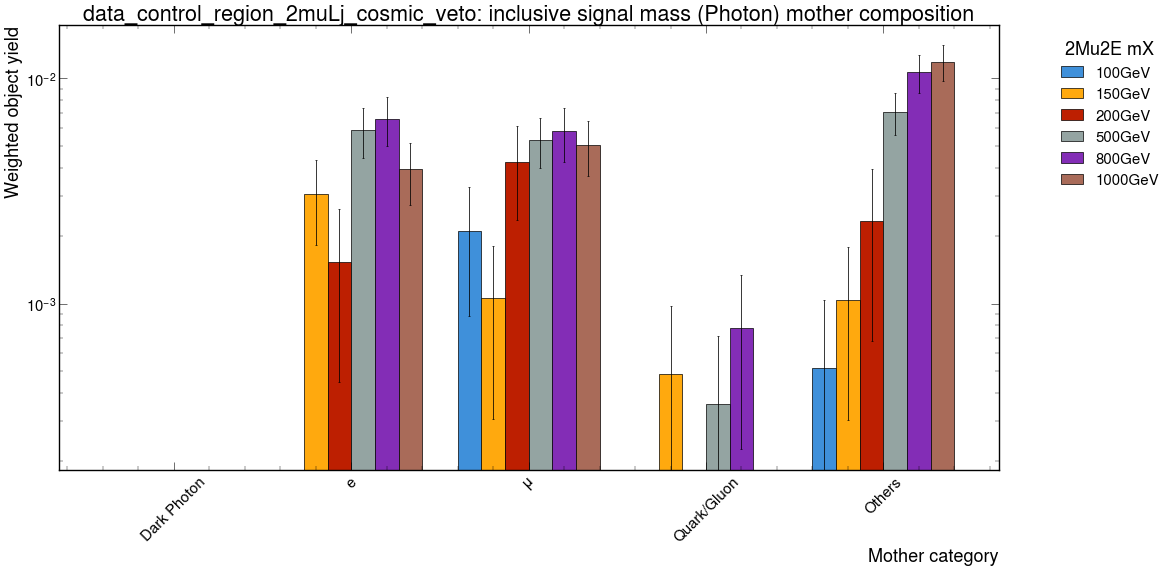

In [38]:
# ============================================================
# Cell 5. Inclusive signal masses only
# 100 / 150 / 200 / 500 / 800 / 1000 GeV
# ============================================================

signal_mass_tables = {}

for channel in channels:
    print()
    print("=" * 120)
    print(f"Channel: {channel}")
    print("=" * 120)

    make_and_show_signal_set(
        output=out,
        signal_groups=signal_mass_groups,
        channel=channel,
        set_label="inclusive signal mass",
        table_store=signal_mass_tables,
        figsize=(24, 12),
        color_map=MASS_COLORS,
        legend_title="2Mu2E mX",
    )



Channel: data_control_region_1muLj_cosmic_veto

------------------------------------------------------------------------------------------------------------------------
data_control_region_1muLj_cosmic_veto: signal mass and dark-photon mass detail
------------------------------------------------------------------------------------------------------------------------


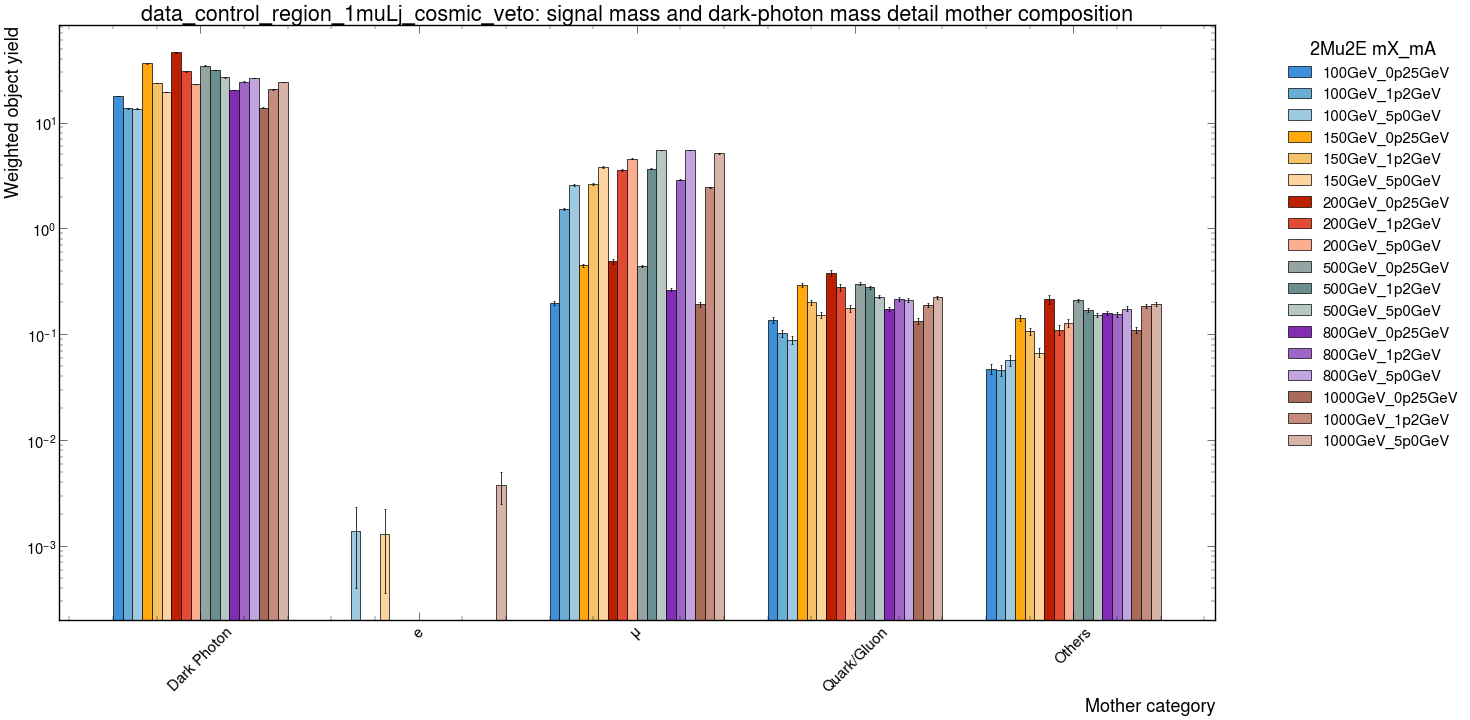

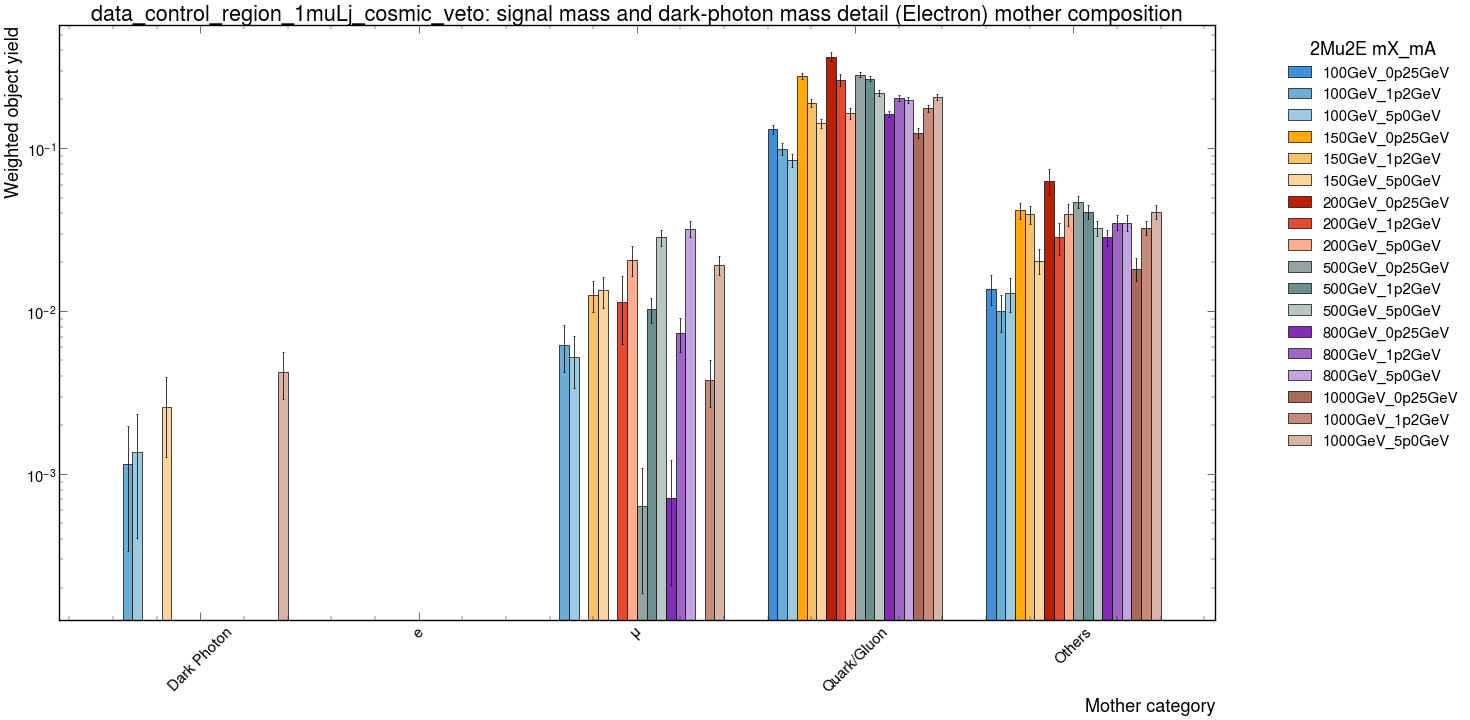

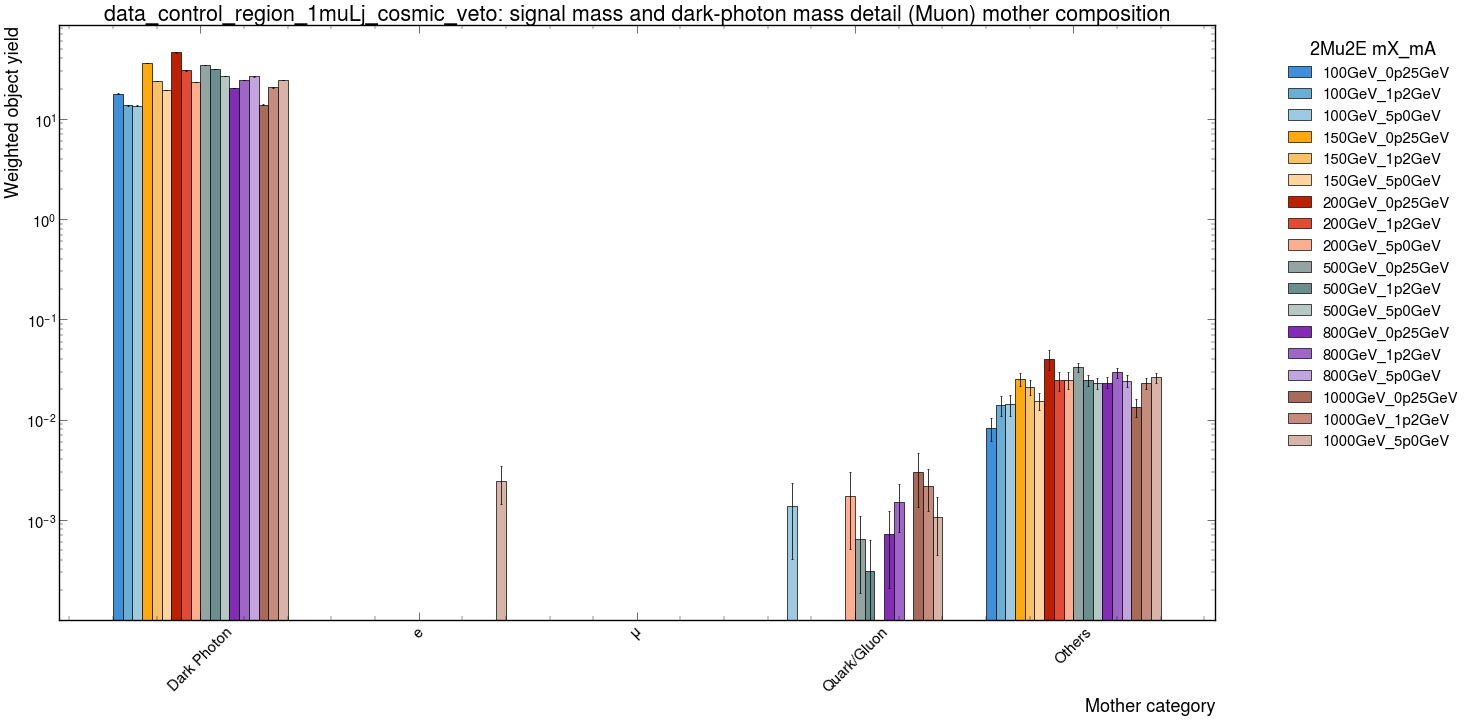

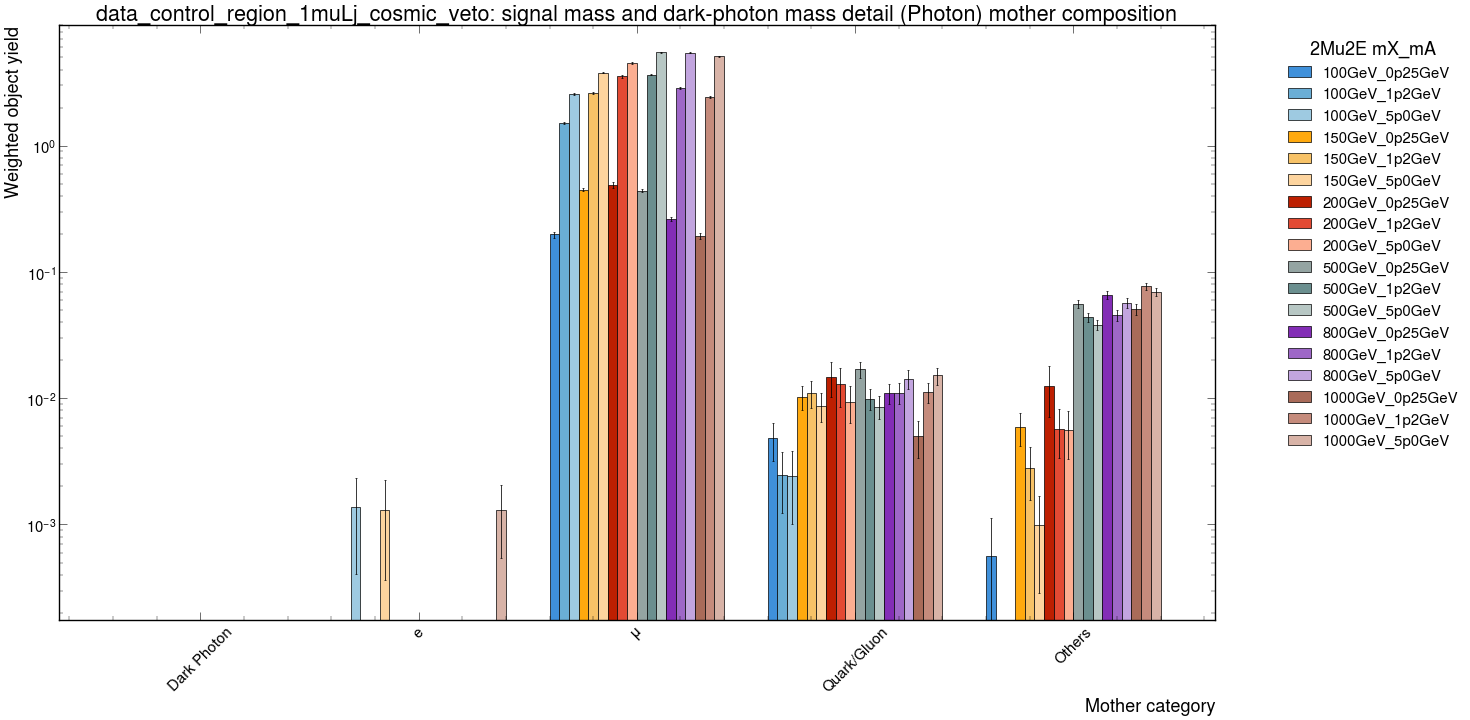


Channel: data_control_region_1egmLj_cosmic_veto

------------------------------------------------------------------------------------------------------------------------
data_control_region_1egmLj_cosmic_veto: signal mass and dark-photon mass detail
------------------------------------------------------------------------------------------------------------------------


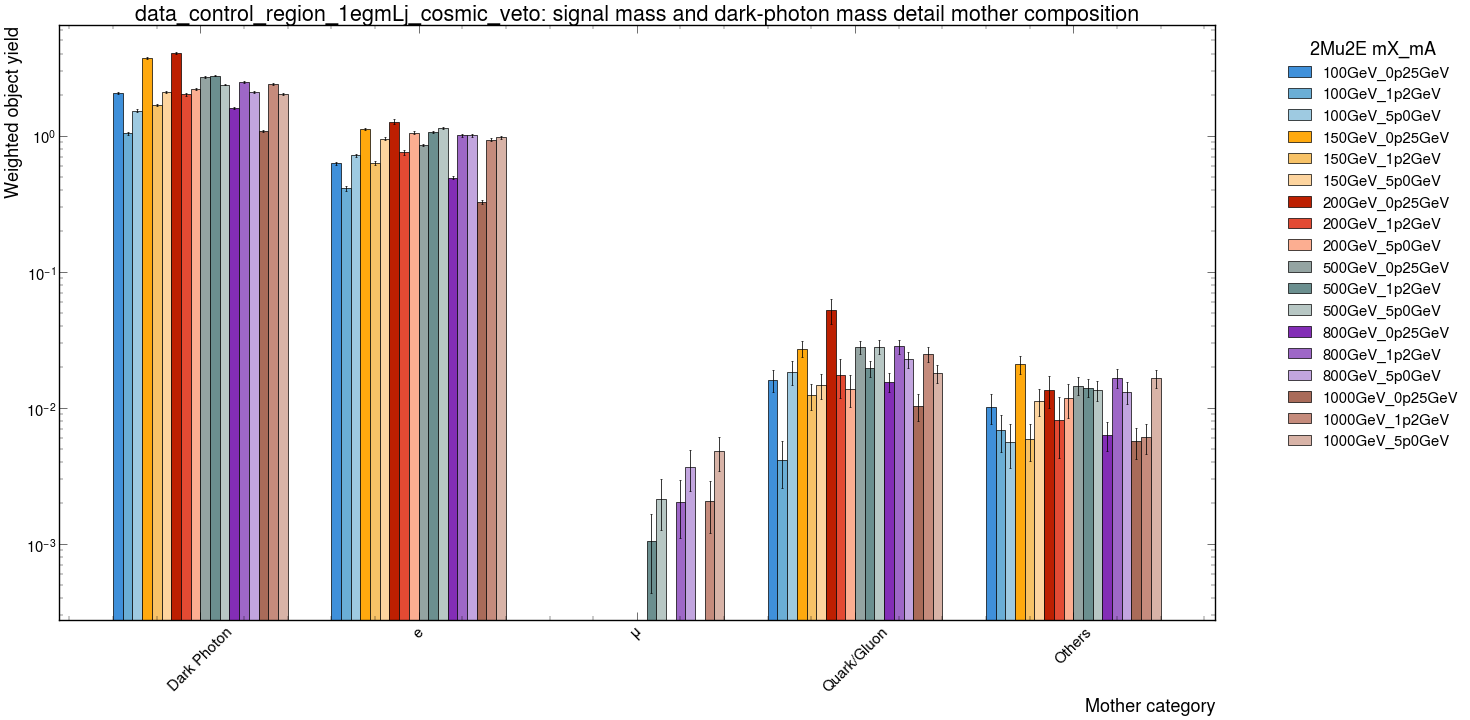

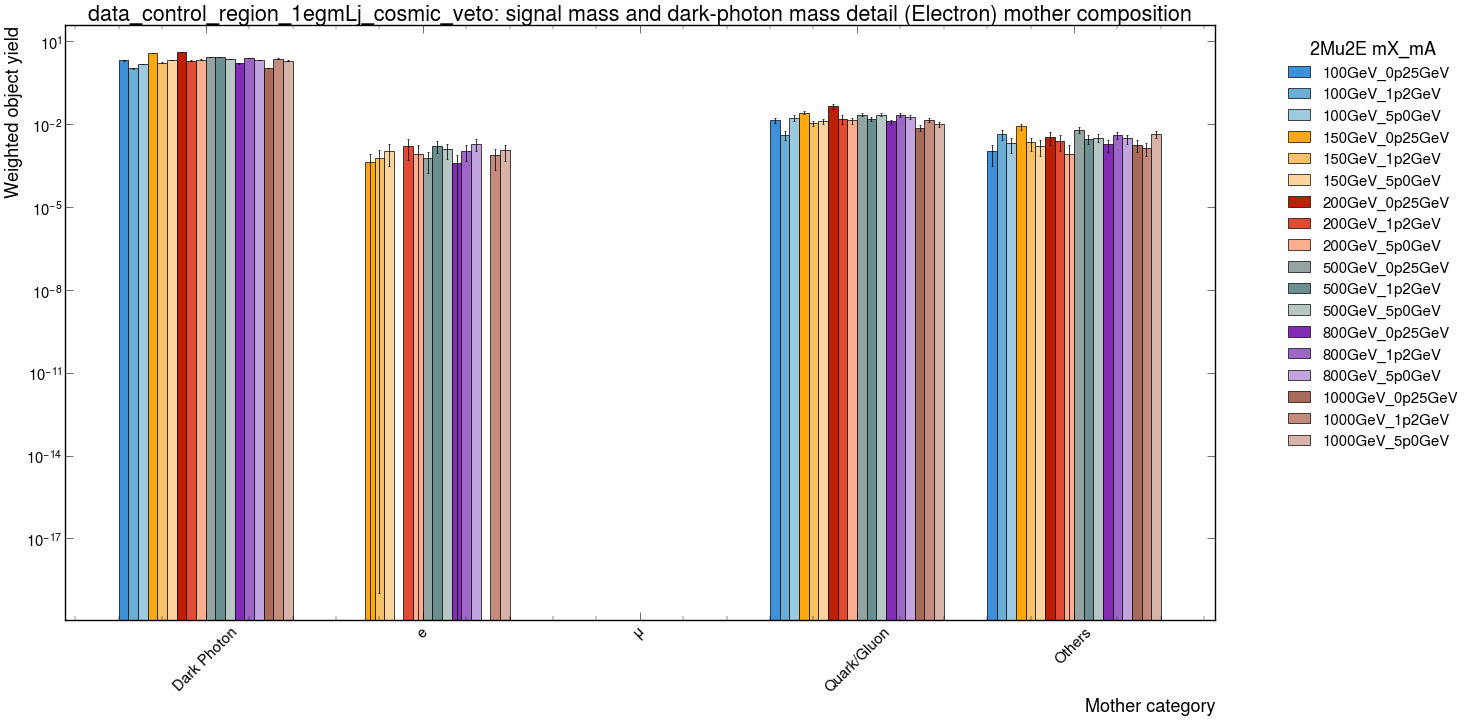

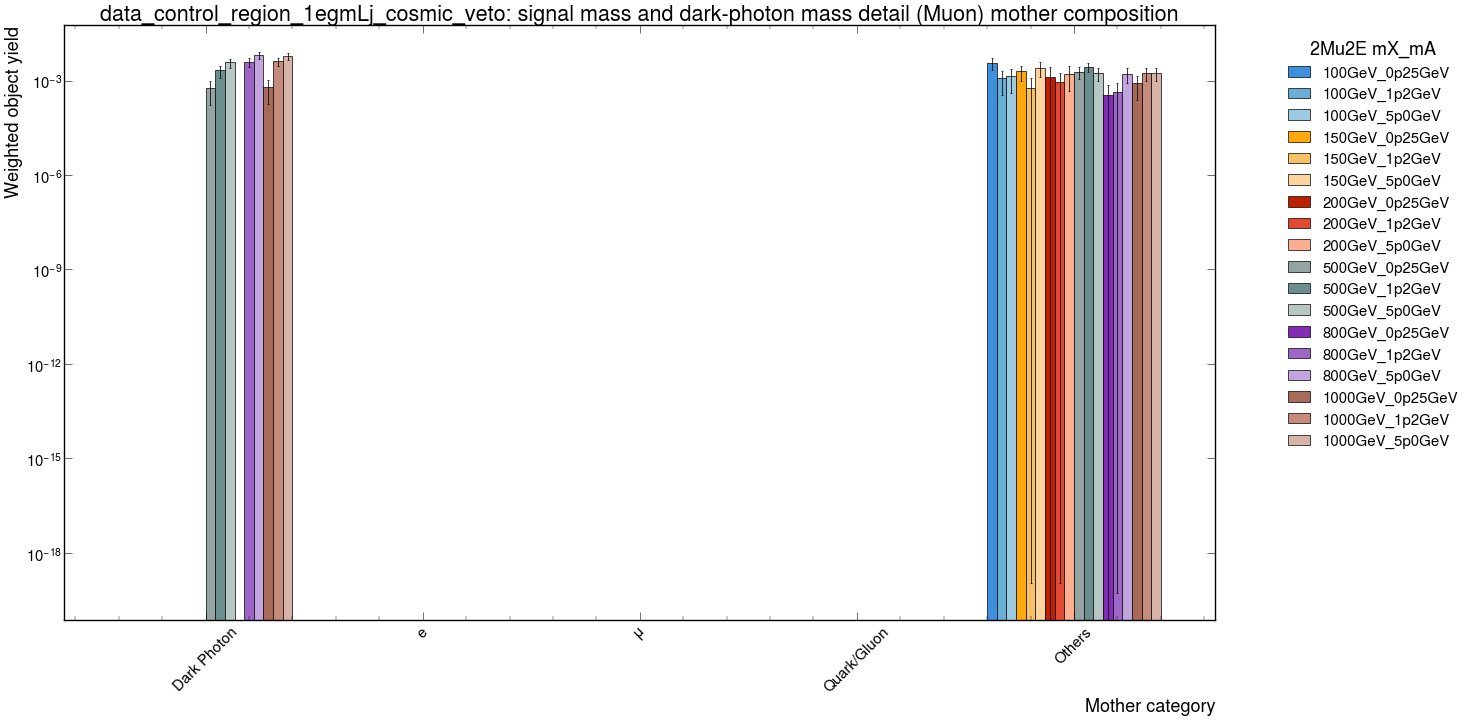

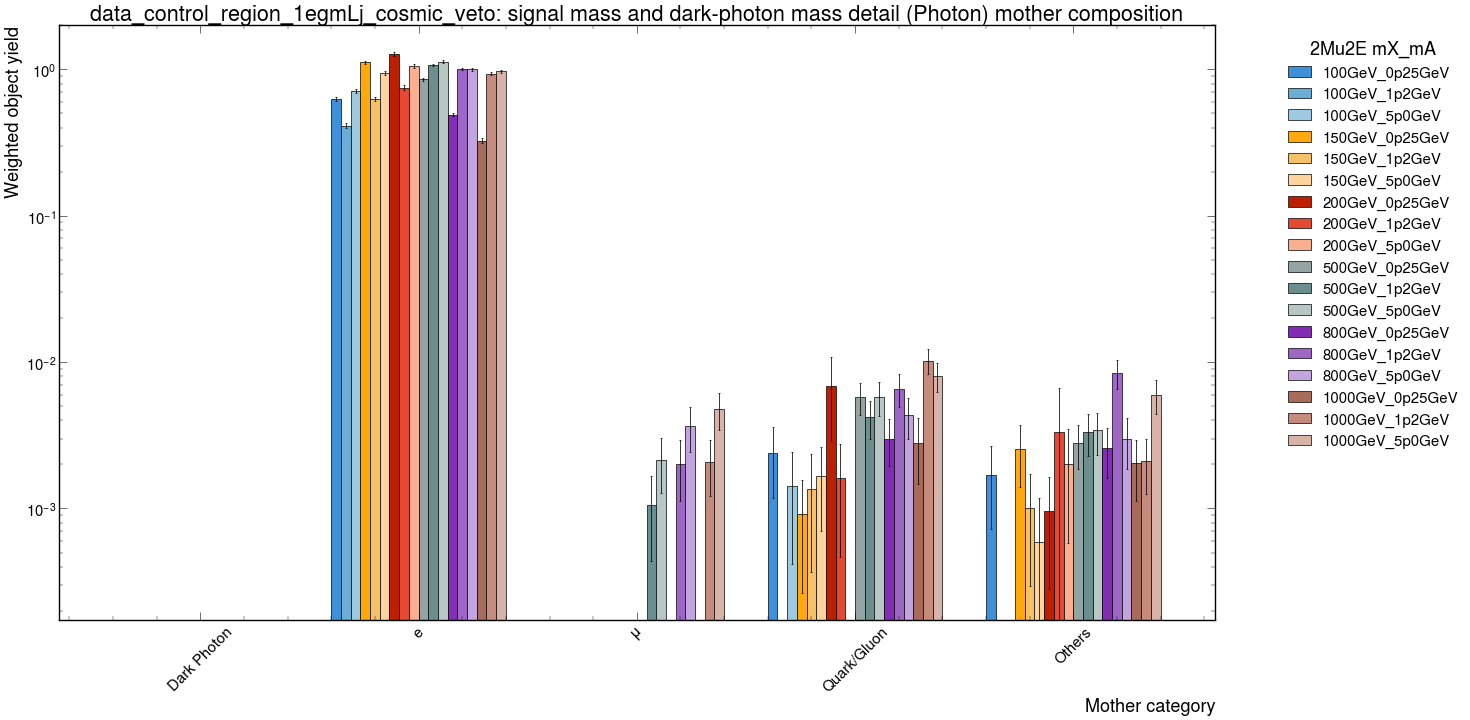


Channel: data_control_region_1muLj_1egmLj_cosmic_veto

------------------------------------------------------------------------------------------------------------------------
data_control_region_1muLj_1egmLj_cosmic_veto: signal mass and dark-photon mass detail
------------------------------------------------------------------------------------------------------------------------


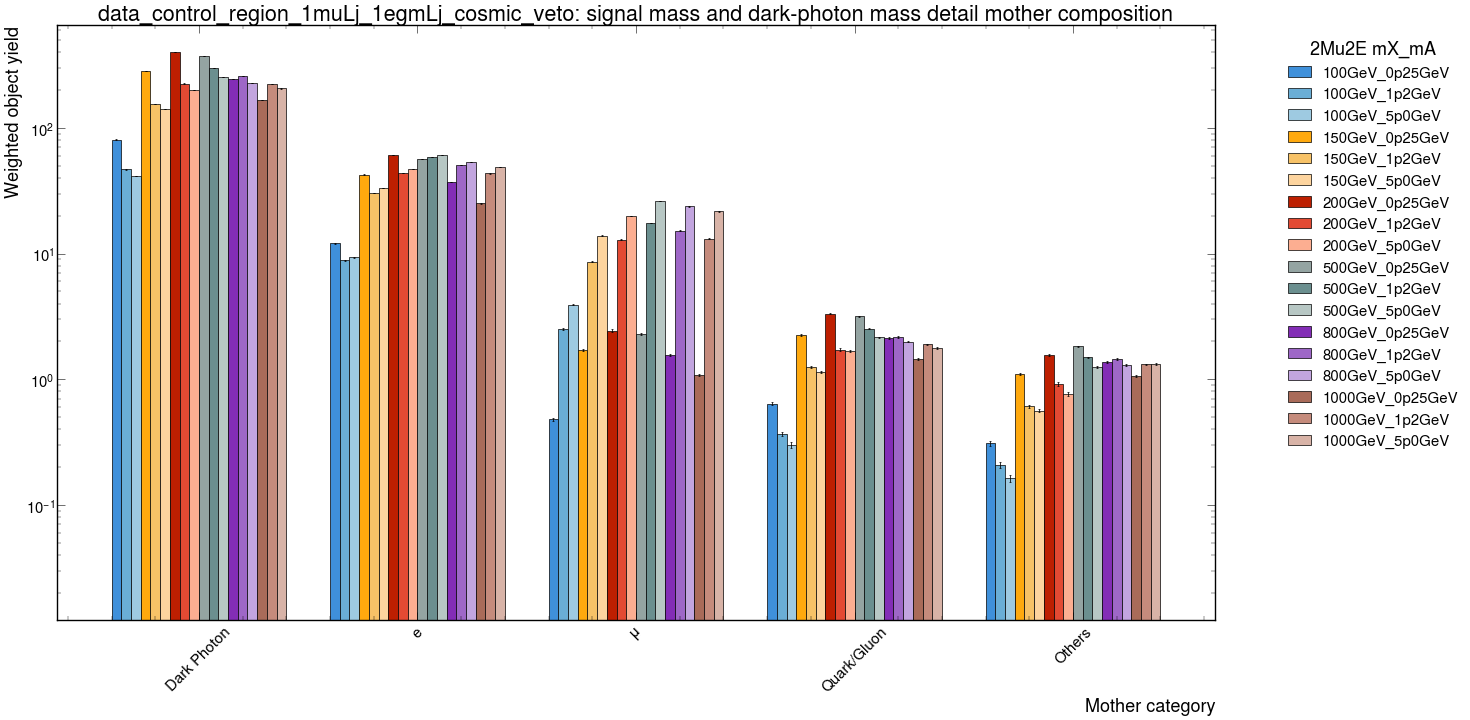

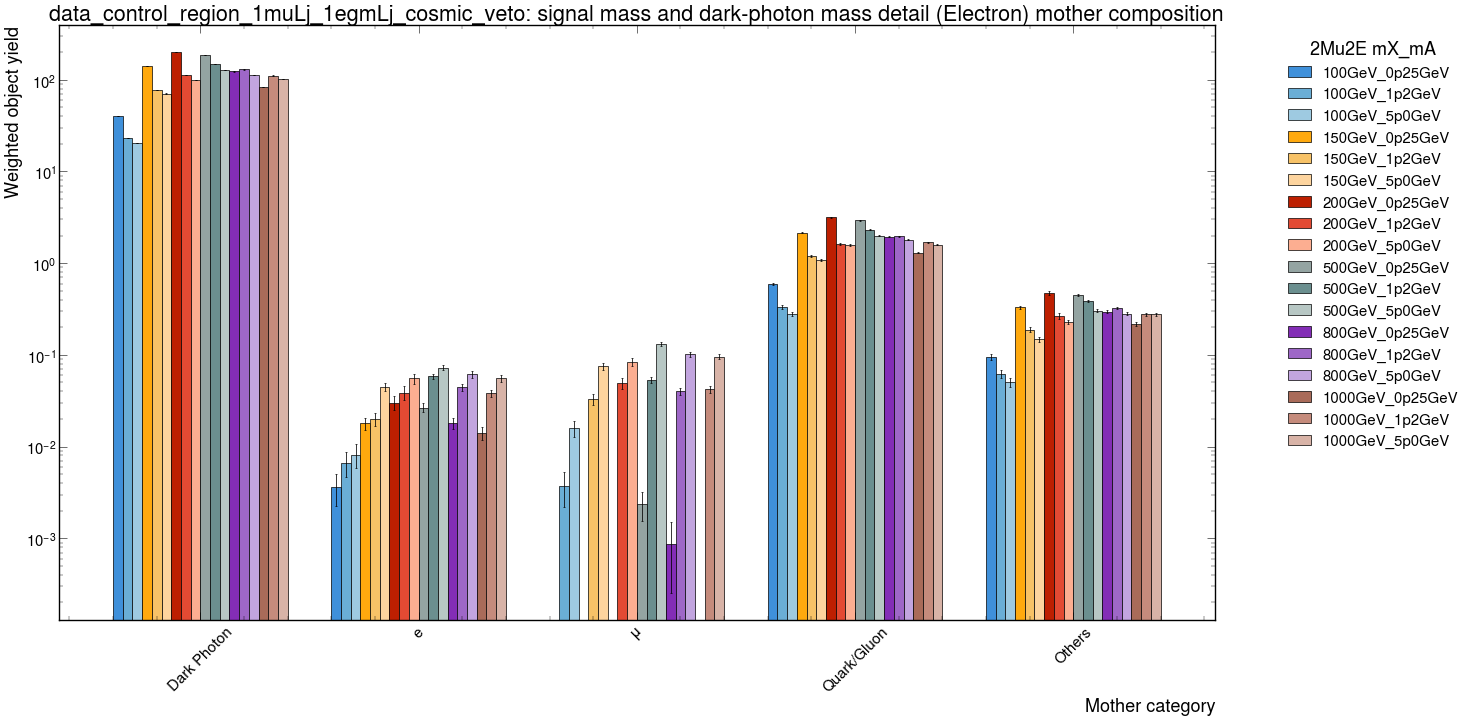

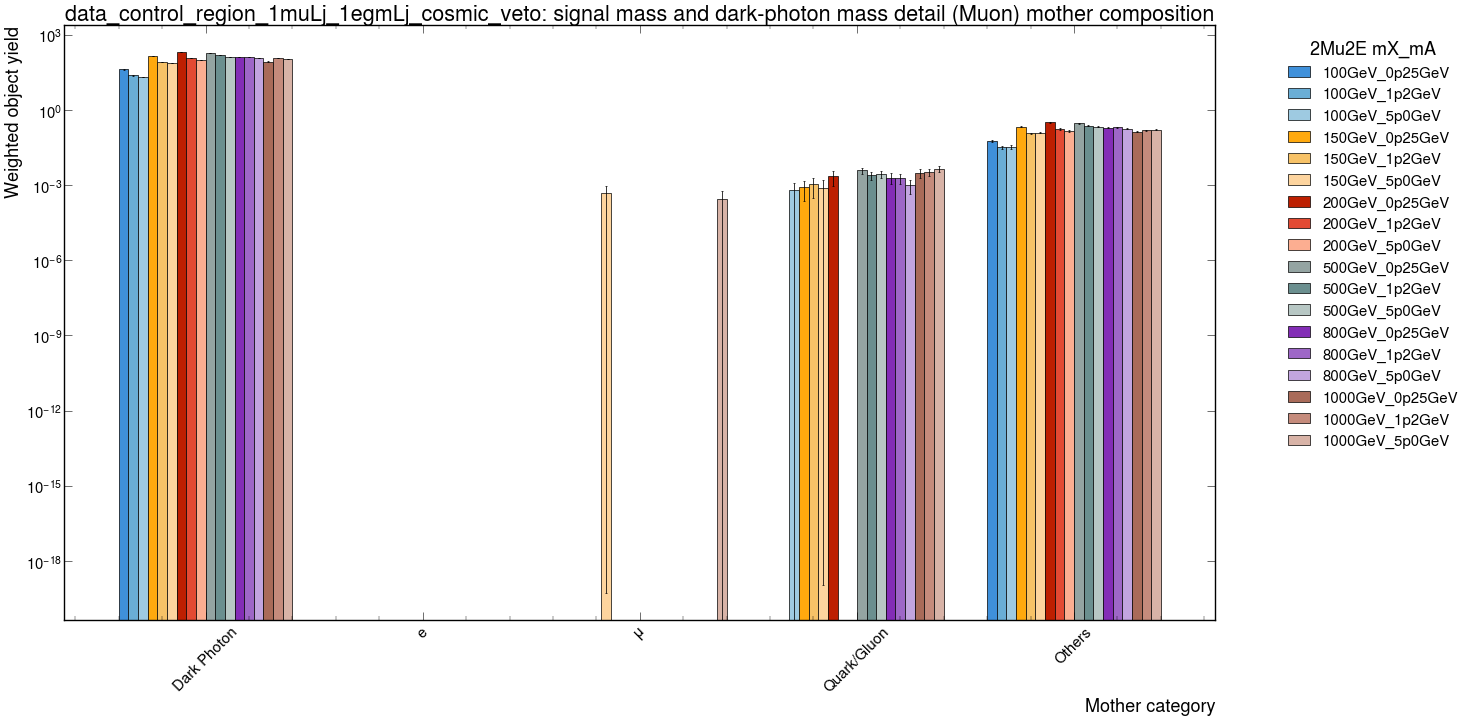

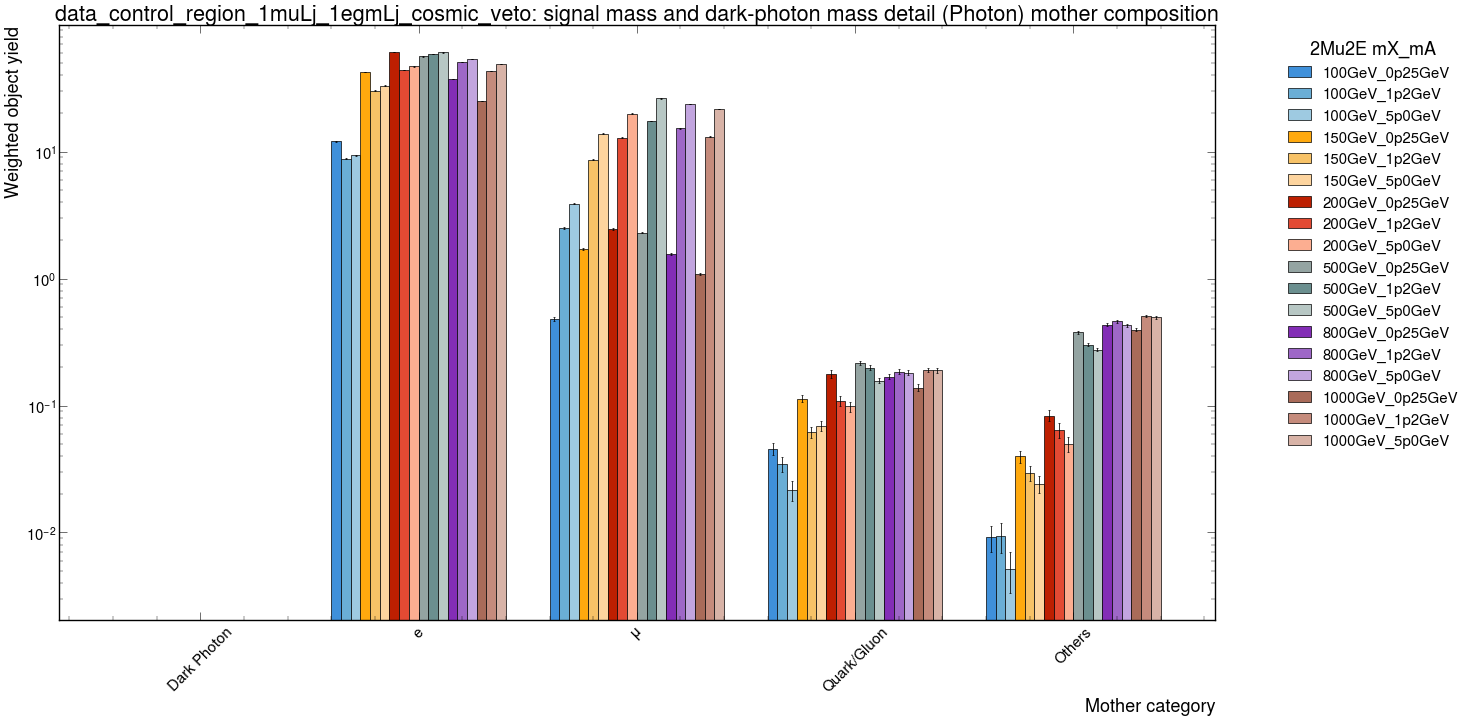


Channel: data_control_region_2muLj_cosmic_veto

------------------------------------------------------------------------------------------------------------------------
data_control_region_2muLj_cosmic_veto: signal mass and dark-photon mass detail
------------------------------------------------------------------------------------------------------------------------


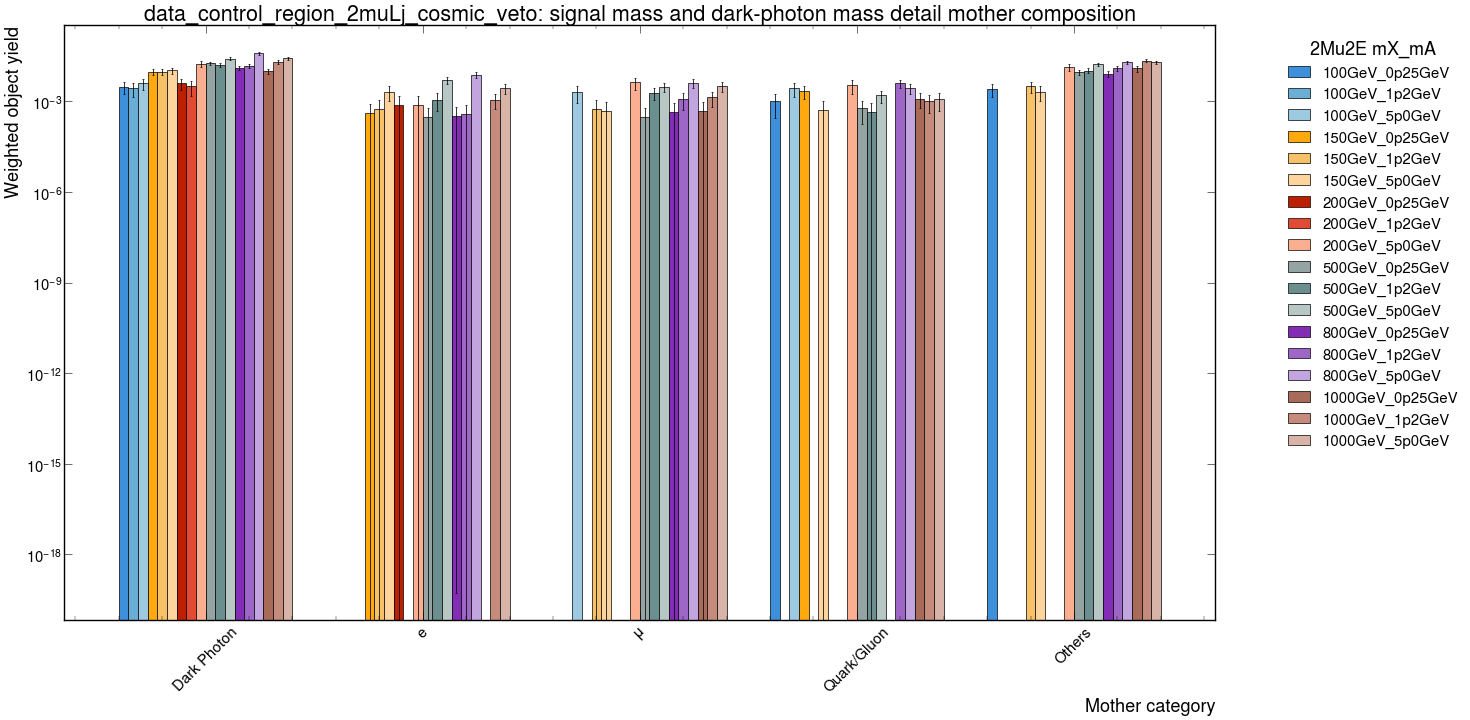

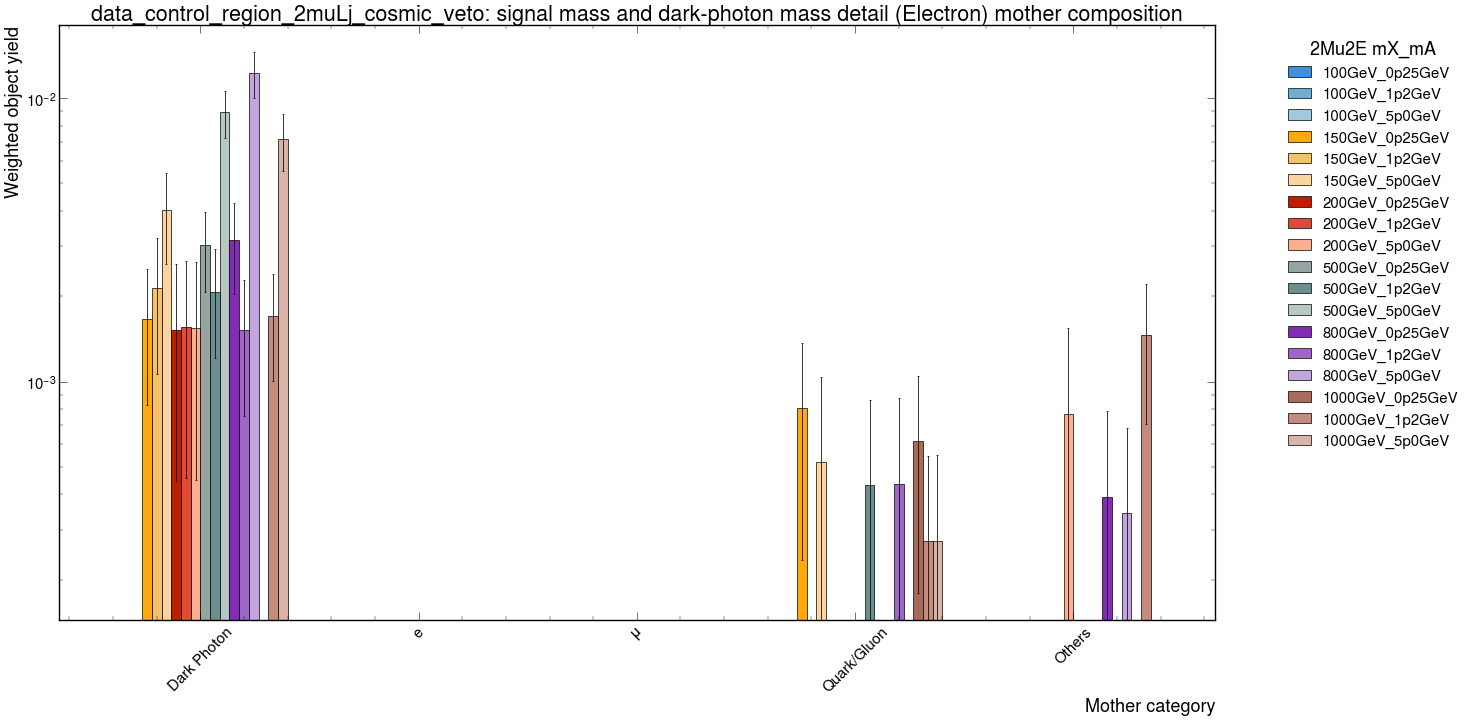

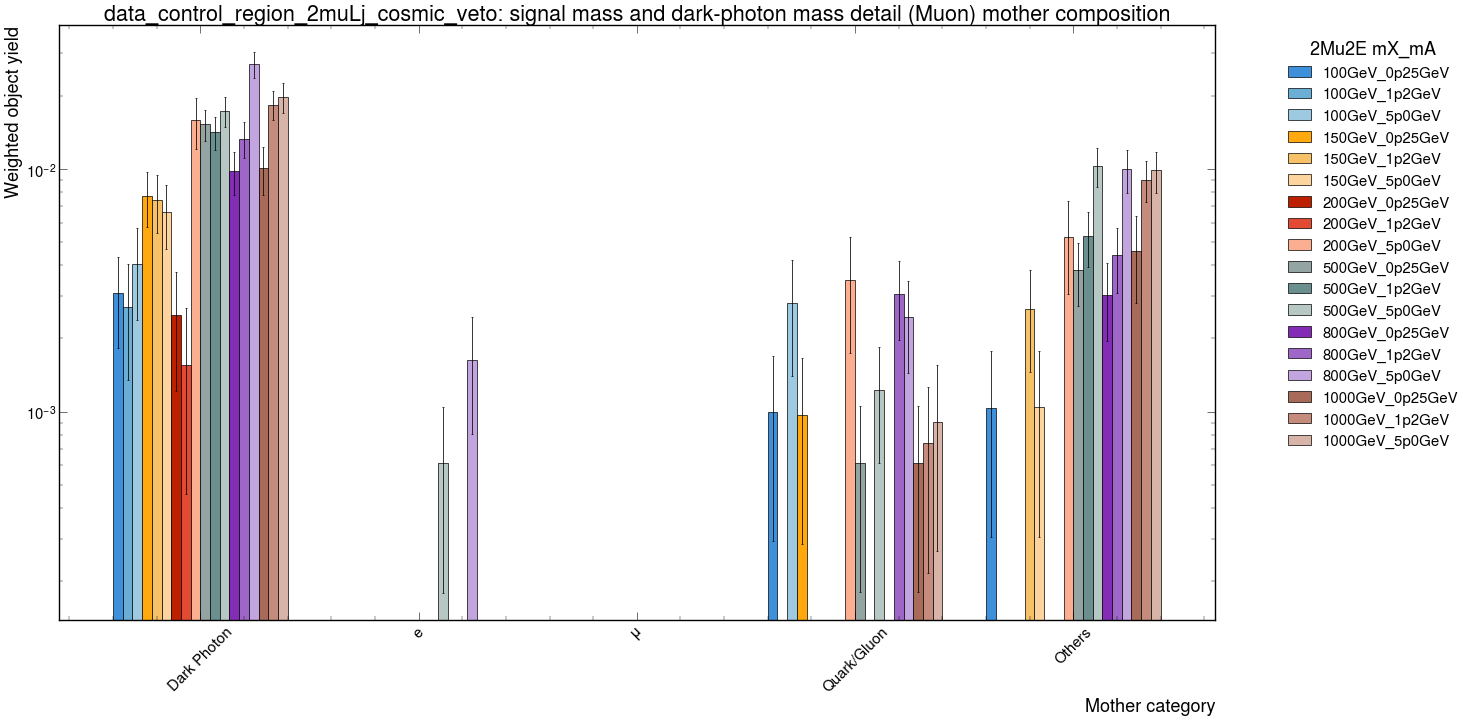

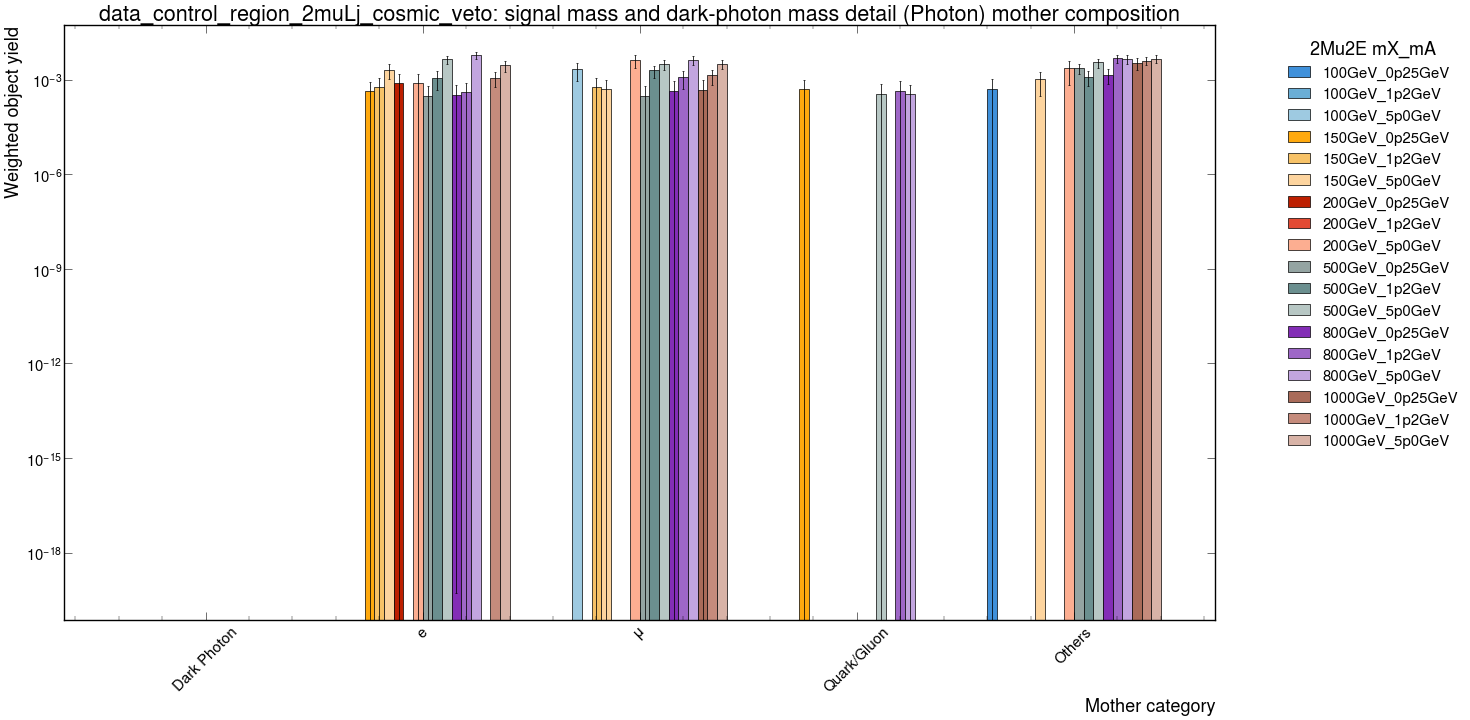

In [39]:
# ============================================================
# Cell 6. Signal mass and dark-photon mass details
# 100-0.25 / 100-1.2 / ... / 1000-5.0
# ============================================================

signal_detail_tables = {}

for channel in channels:
    print()
    print("=" * 120)
    print(f"Channel: {channel}")
    print("=" * 120)

    make_and_show_signal_set(
        output=out,
        signal_groups=signal_detail_groups,
        channel=channel,
        set_label="signal mass and dark-photon mass detail",
        table_store=signal_detail_tables,
        figsize=(30, 15),
        color_map=DETAIL_COLORS,
        legend_title="2Mu2E mX_mA",
    )


In [ ]:
# ============================================================
# Cell 7. Signal lxy sub-processes only
# disabled by default because it makes many plots
# ============================================================

RUN_SIGNAL_LXY_SUBPROCESSES = False
signal_lxy_tables = {}

if RUN_SIGNAL_LXY_SUBPROCESSES:
    for channel in channels:
        print()
        print("=" * 120)
        print(f"Channel: {channel}")
        print("=" * 120)

        make_and_show_signal_set(
            output=out,
            signal_groups=signal_lxy_groups,
            channel=channel,
            set_label="signal lxy sub-process",
            table_store=signal_lxy_tables,
            figsize=(36, 18),
            color_map=LXY_COLORS,
            legend_title="Signal sample",
        )


In [40]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

def _is_int_like(x):
    try:
        int(x)
        return True
    except Exception:
        return False

def iter_other_counts(other_obj):
    if isinstance(other_obj, pd.DataFrame):
        columns_are_pdgid = all(_is_int_like(x) for x in other_obj.columns)

        if columns_are_pdgid:
            for process, row in other_obj.iterrows():
                for pdgid, yield_value in row.items():
                    yield process, pdgid, yield_value
        else:
            for process in other_obj.columns:
                for pdgid, yield_value in other_obj[process].items():
                    yield process, pdgid, yield_value
    else:
        for process, other_counts in other_obj.items():
            for pdgid, yield_value in other_counts.items():
                yield process, pdgid, yield_value

def make_other_pdgid_table(table_store, top_n=None, min_yield=0):
    rows = []

    for channel, channel_payload in table_store.items():
        if isinstance(channel_payload, dict) and "other" in channel_payload:
            table_sets = {"": channel_payload}
        else:
            table_sets = channel_payload

        for set_label, payload in table_sets.items():
            if not isinstance(payload, dict) or "other" not in payload:
                continue

            entries = []
            for process, pdgid, yield_value in iter_other_counts(payload["other"]):
                if pd.isna(yield_value) or yield_value <= min_yield:
                    continue
                entries.append((process, pdgid, yield_value))

            if top_n is not None:
                grouped = defaultdict(list)
                for process, pdgid, yield_value in entries:
                    grouped[process].append((pdgid, yield_value))

                entries = []
                for process, items in grouped.items():
                    for pdgid, yield_value in sorted(items, key=lambda x: x[1], reverse=True)[:top_n]:
                        entries.append((process, pdgid, yield_value))

            for process, pdgid, yield_value in entries:
                rows.append({
                    "channel": channel,
                    "set": set_label,
                    "process": process,
                    "mother_pdgid": int(pdgid),
                    "abs_mother_pdgid": abs(int(pdgid)),
                    "yield": float(yield_value),
                })

    return pd.DataFrame(rows)

def display_other_pdgid_tables(table_stores, top_n=None, min_yield=0):
    for store_name, table_store in table_stores.items():
        other_df = make_other_pdgid_table(
            table_store,
            top_n=top_n,
            min_yield=min_yield,
        )

        display(Markdown(f"## {store_name}: Others mother PDG IDs"))

        if other_df.empty:
            display(Markdown("No `Others` entries found."))
            continue

        other_df = other_df.sort_values("yield", ascending=False).reset_index(drop=True)
        if top_n is not None:
            other_df = other_df.head(top_n)
        display(other_df)

table_stores_to_check = {}

for name in [
    "signal_mass_tables",
    "signal_detail_tables",
    "signal_lxy_tables",
]:
    if name in globals():
        table_stores_to_check[name] = globals()[name]

display_other_pdgid_tables(
    table_stores_to_check,
    top_n=50,
    min_yield=1e-6,
)


## signal_mass_tables: Others mother PDG IDs

,channel,set,process,mother_pdgid,abs_mother_pdgid,yield
0,data_control_region_1muLj_1egmLj_cosmic_veto,,500GeV,411,411,1.497573
1,data_control_region_1muLj_1egmLj_cosmic_veto,,1000GeV,111,111,1.422382
2,data_control_region_1muLj_1egmLj_cosmic_veto,,800GeV,111,111,1.370568
3,data_control_region_1muLj_1egmLj_cosmic_veto,,200GeV,411,411,1.270087
4,data_control_region_1muLj_1egmLj_cosmic_veto,,800GeV,411,411,1.159328
5,data_control_region_1muLj_1egmLj_cosmic_veto,,500GeV,421,421,1.147318
6,data_control_region_1muLj_1egmLj_cosmic_veto,,500GeV,111,111,1.078147
7,data_control_region_1muLj_1egmLj_cosmic_veto,,200GeV,421,421,1.039777
8,data_control_region_1muLj_1egmLj_cosmic_veto,,1000GeV,411,411,0.945239
9,data_control_region_1muLj_1egmLj_cosmic_veto,,150GeV,411,411,0.924801


## signal_detail_tables: Others mother PDG IDs

,channel,set,process,mother_pdgid,abs_mother_pdgid,yield
0,data_control_region_1muLj_1egmLj_cosmic_veto,,200GeV_0p25GeV,411,411,0.618259
1,data_control_region_1muLj_1egmLj_cosmic_veto,,500GeV_0p25GeV,411,411,0.592421
2,data_control_region_1muLj_1egmLj_cosmic_veto,,1000GeV_1p2GeV,111,111,0.524803
3,data_control_region_1muLj_1egmLj_cosmic_veto,,200GeV_0p25GeV,421,421,0.504547
4,data_control_region_1muLj_1egmLj_cosmic_veto,,500GeV_1p2GeV,411,411,0.504263
5,data_control_region_1muLj_1egmLj_cosmic_veto,,1000GeV_5p0GeV,111,111,0.499955
6,data_control_region_1muLj_1egmLj_cosmic_veto,,800GeV_1p2GeV,111,111,0.473771
7,data_control_region_1muLj_1egmLj_cosmic_veto,,500GeV_0p25GeV,421,421,0.471883
8,data_control_region_1muLj_1egmLj_cosmic_veto,,800GeV_0p25GeV,111,111,0.461848
9,data_control_region_1muLj_1egmLj_cosmic_veto,,150GeV_0p25GeV,411,411,0.443127


## signal_lxy_tables: Others mother PDG IDs

,channel,set,process,mother_pdgid,abs_mother_pdgid,yield
0,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_2p0mm,411,411,0.035356
1,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_0p2mm,411,411,0.034818
2,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_0p02mm,411,411,0.033313
3,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_0p02mm,421,421,0.032361
4,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_0p2mm,421,421,0.031700
5,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_2p0mm,421,421,0.023903
6,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_10p0mm,411,411,0.014185
7,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_10p0mm,421,421,0.011916
8,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_0p02mm,111,111,0.008566
9,data_control_region_1muLj_1egmLj_cosmic_veto,2Mu2E_100GeV_0p25GeV,2Mu2E_100GeV_0p25GeV_2p0mm,111,111,0.008465



inclusive signal mass: Inclusive


/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


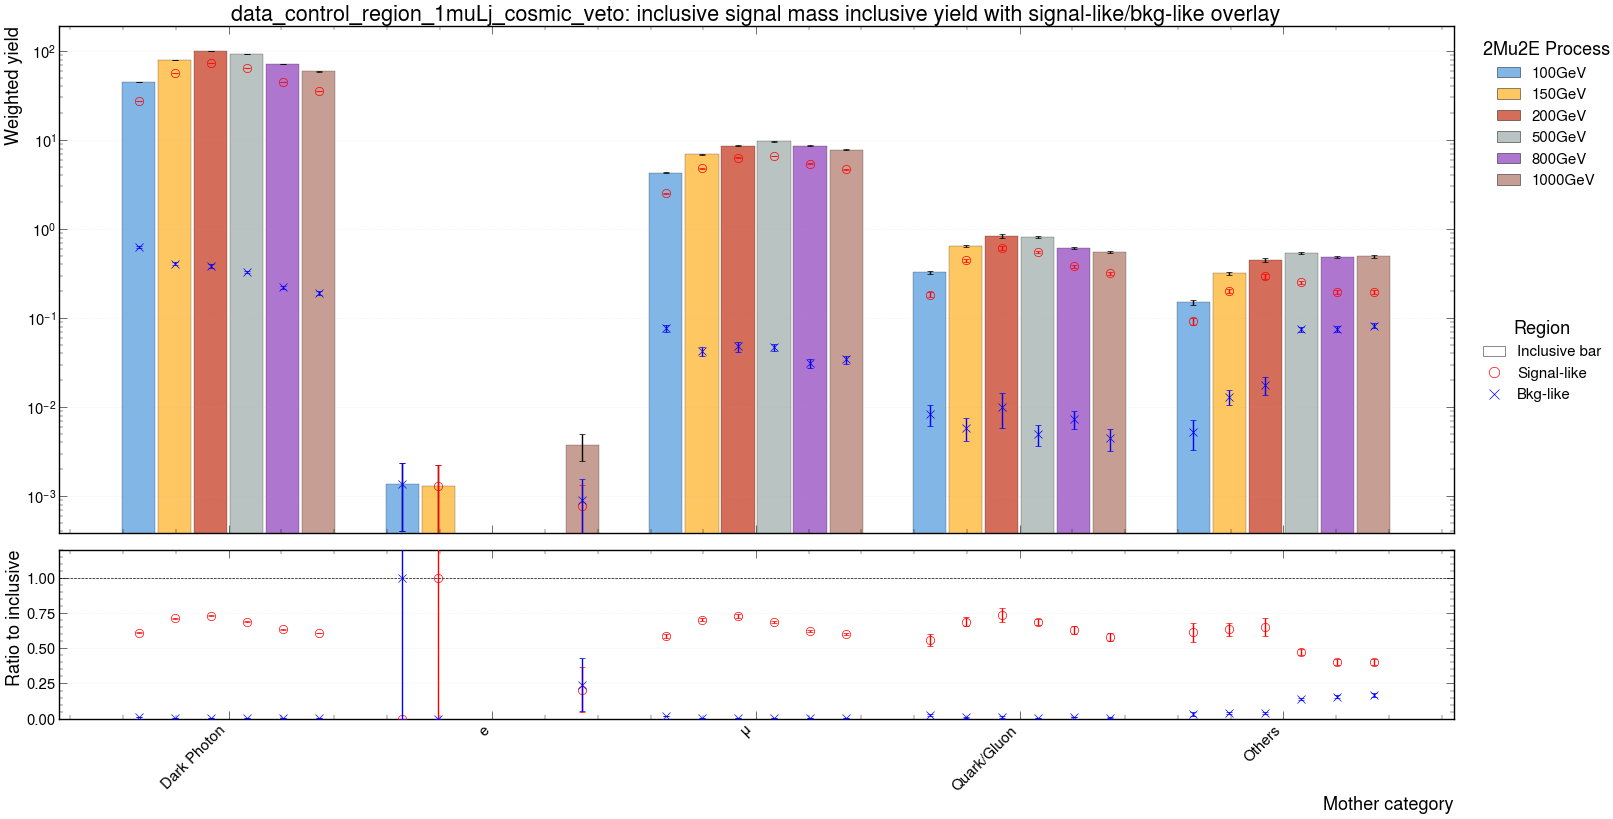

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


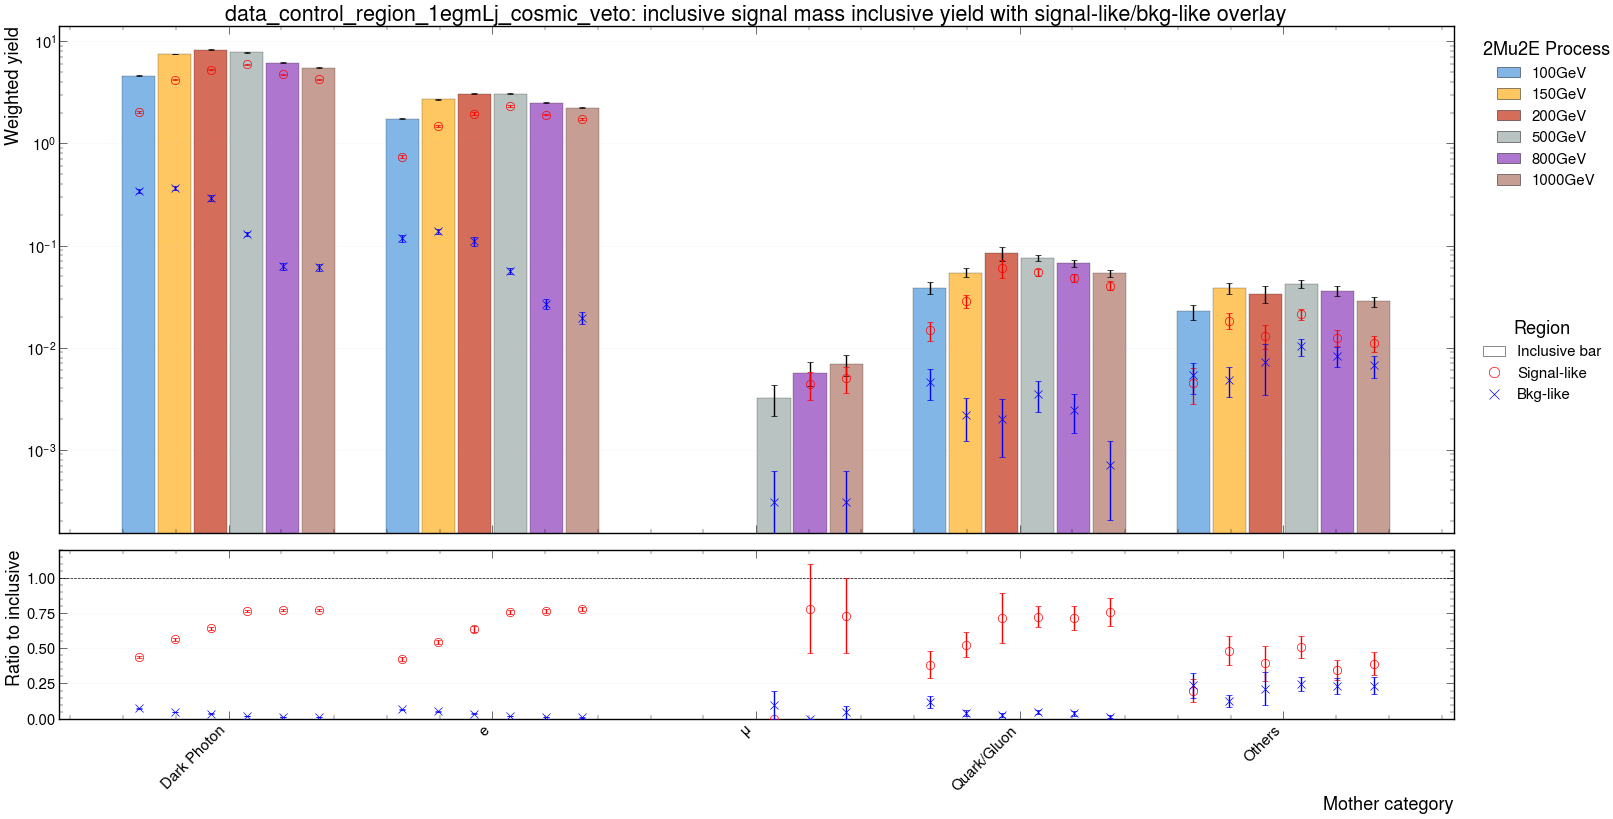

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


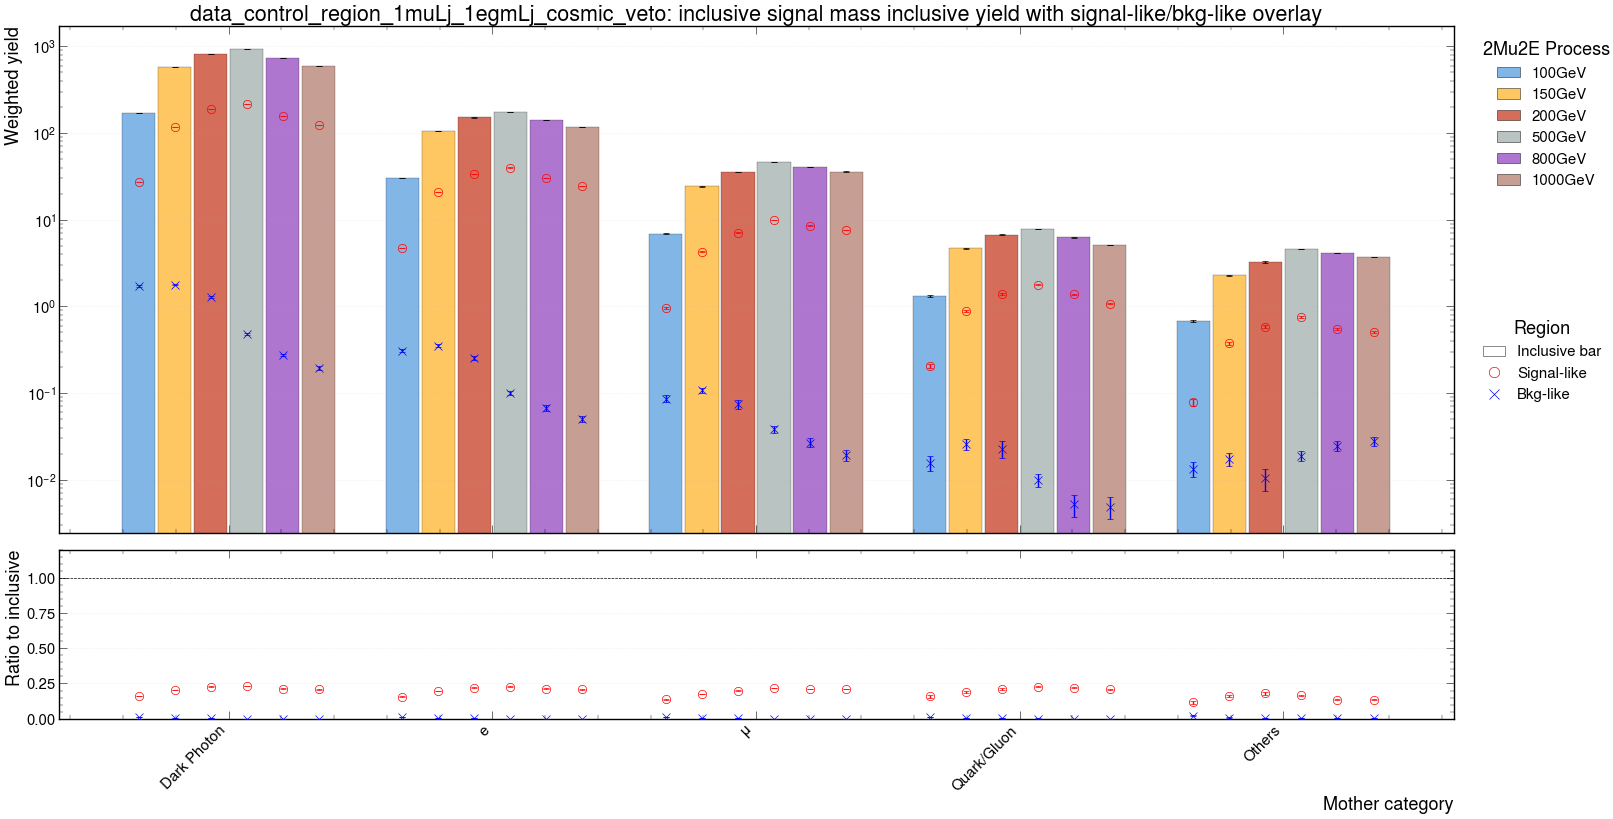

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


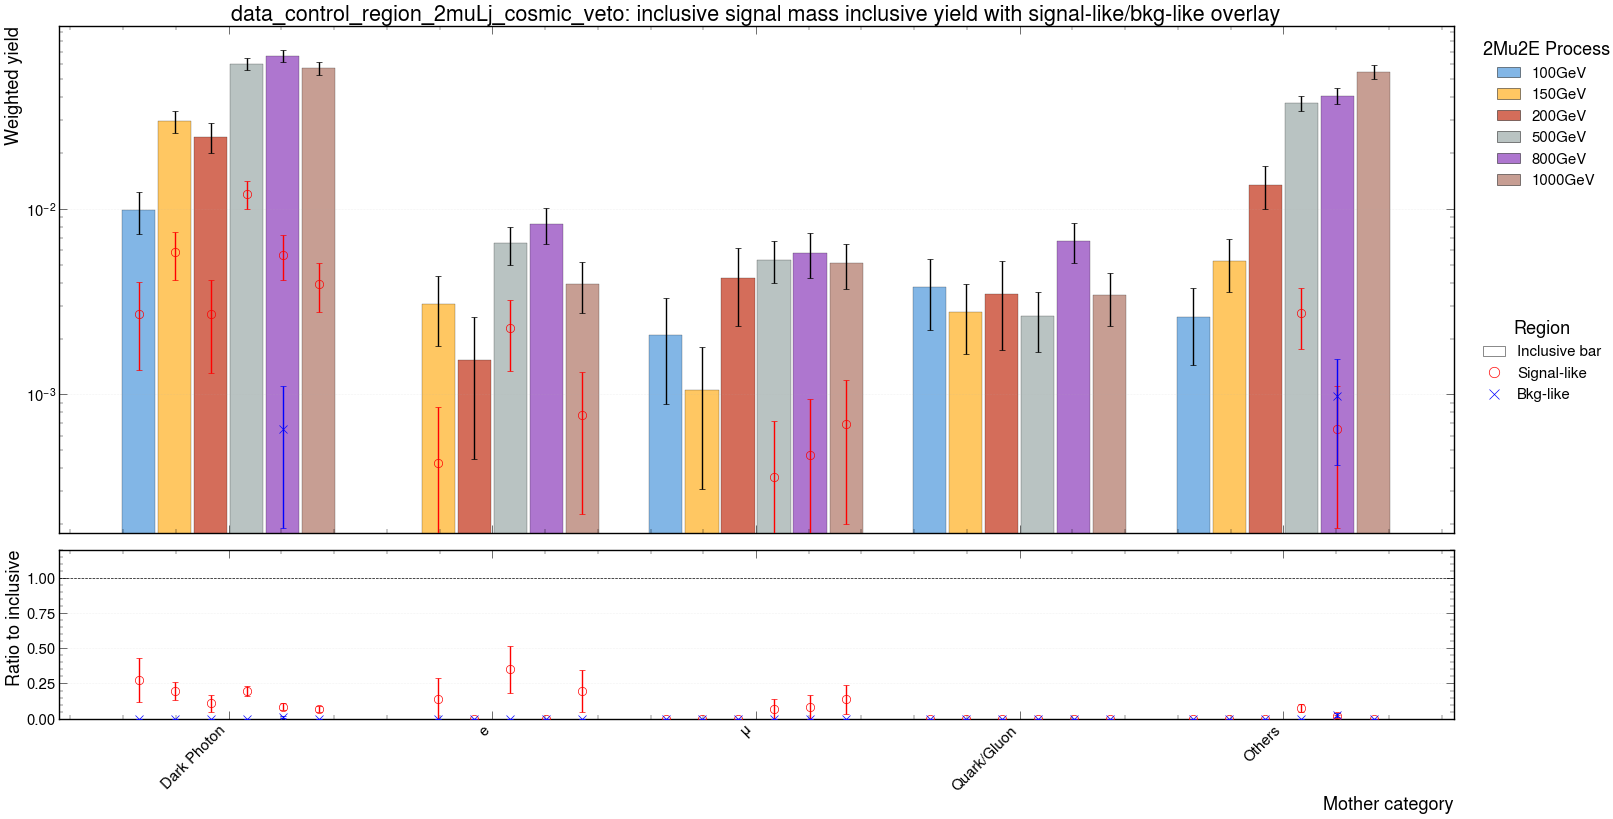


inclusive signal mass: Electron


/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


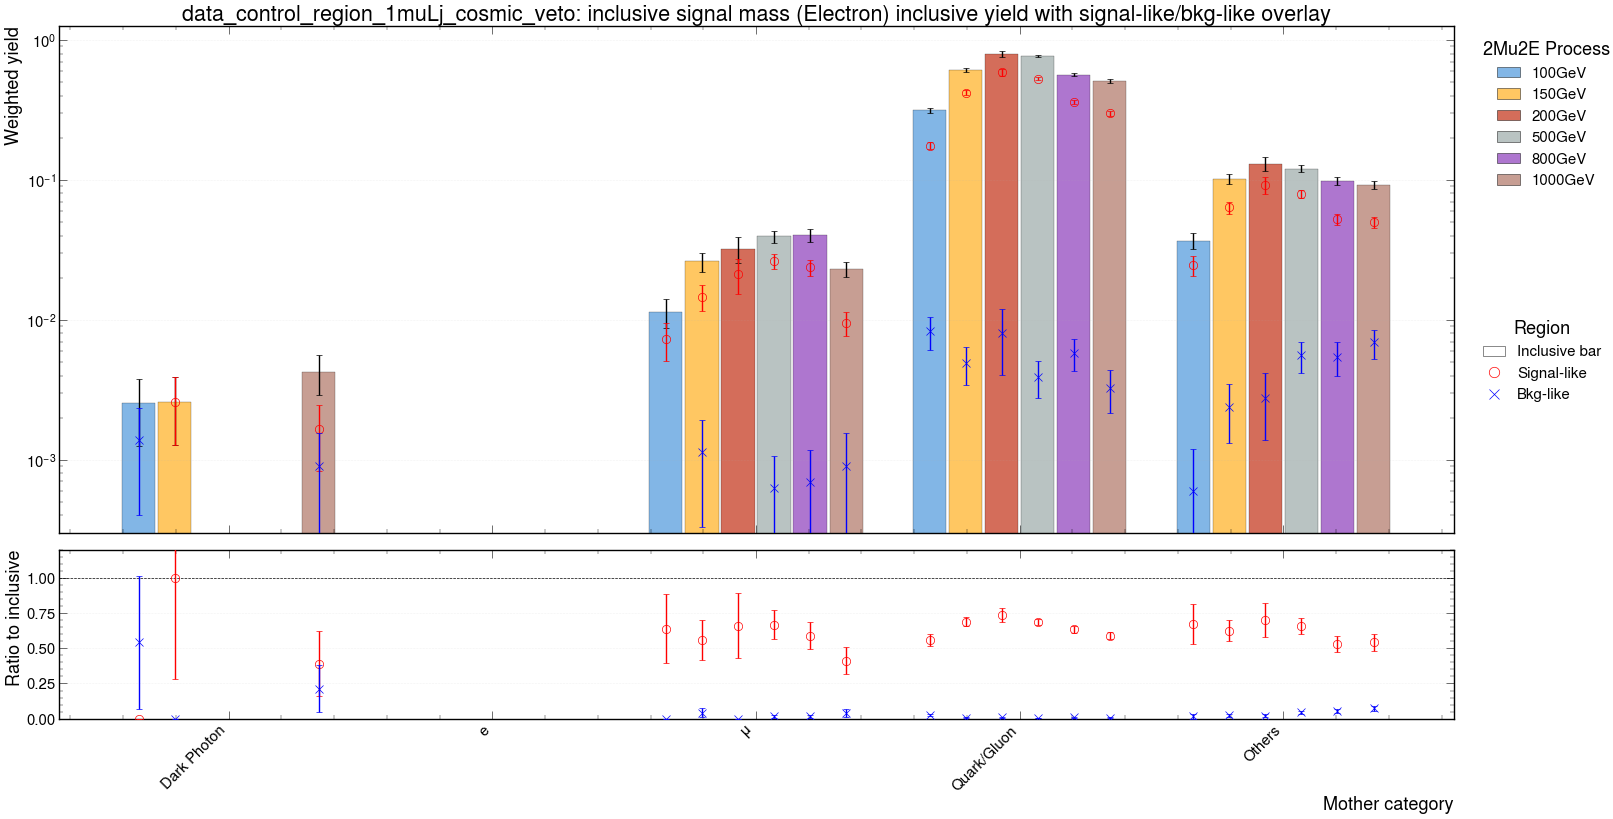

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


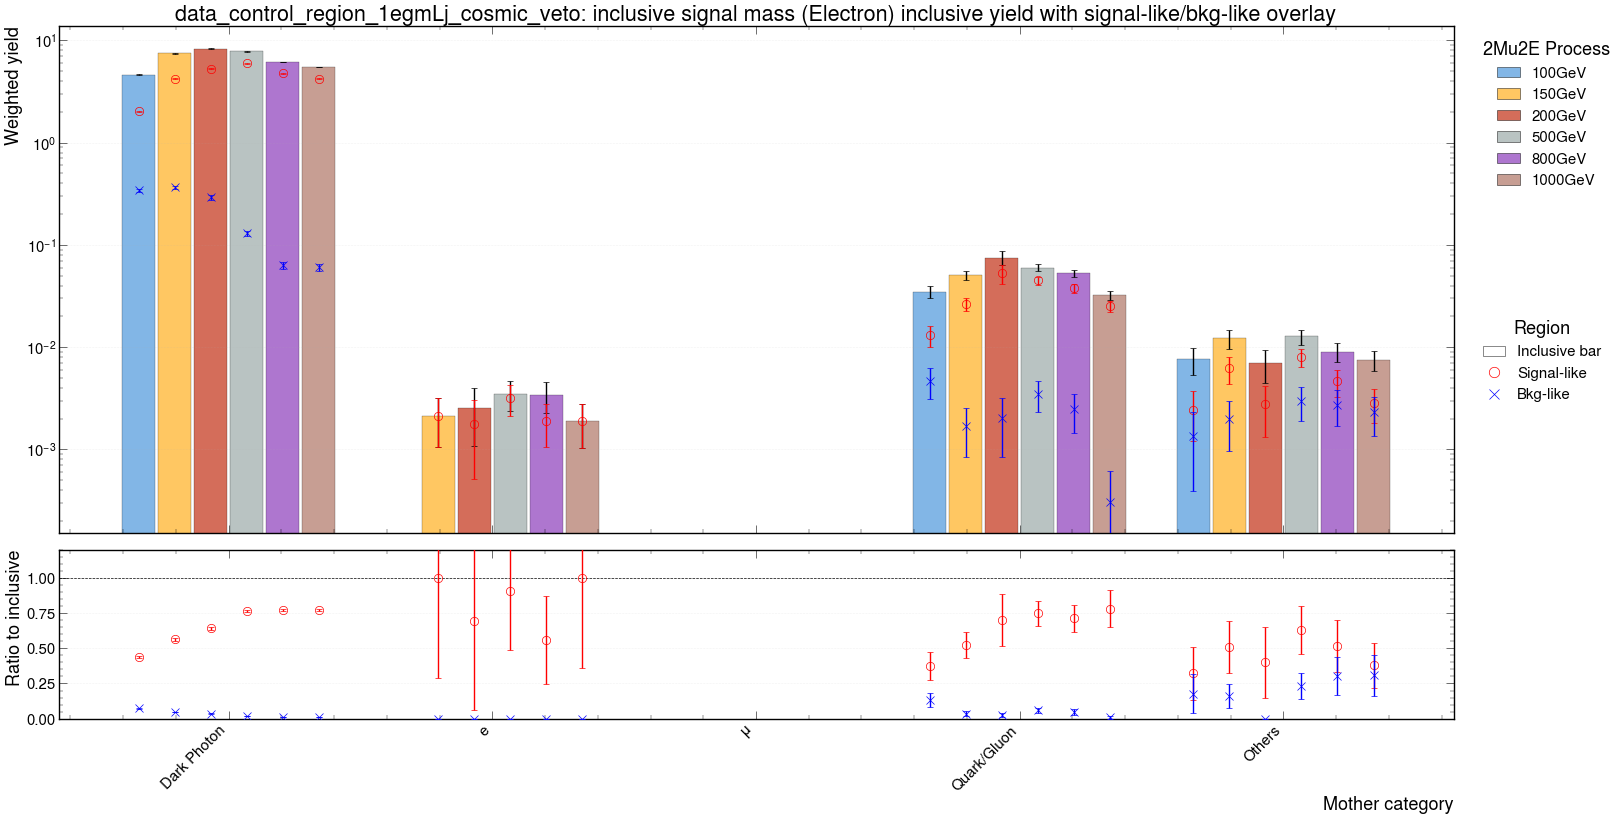

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


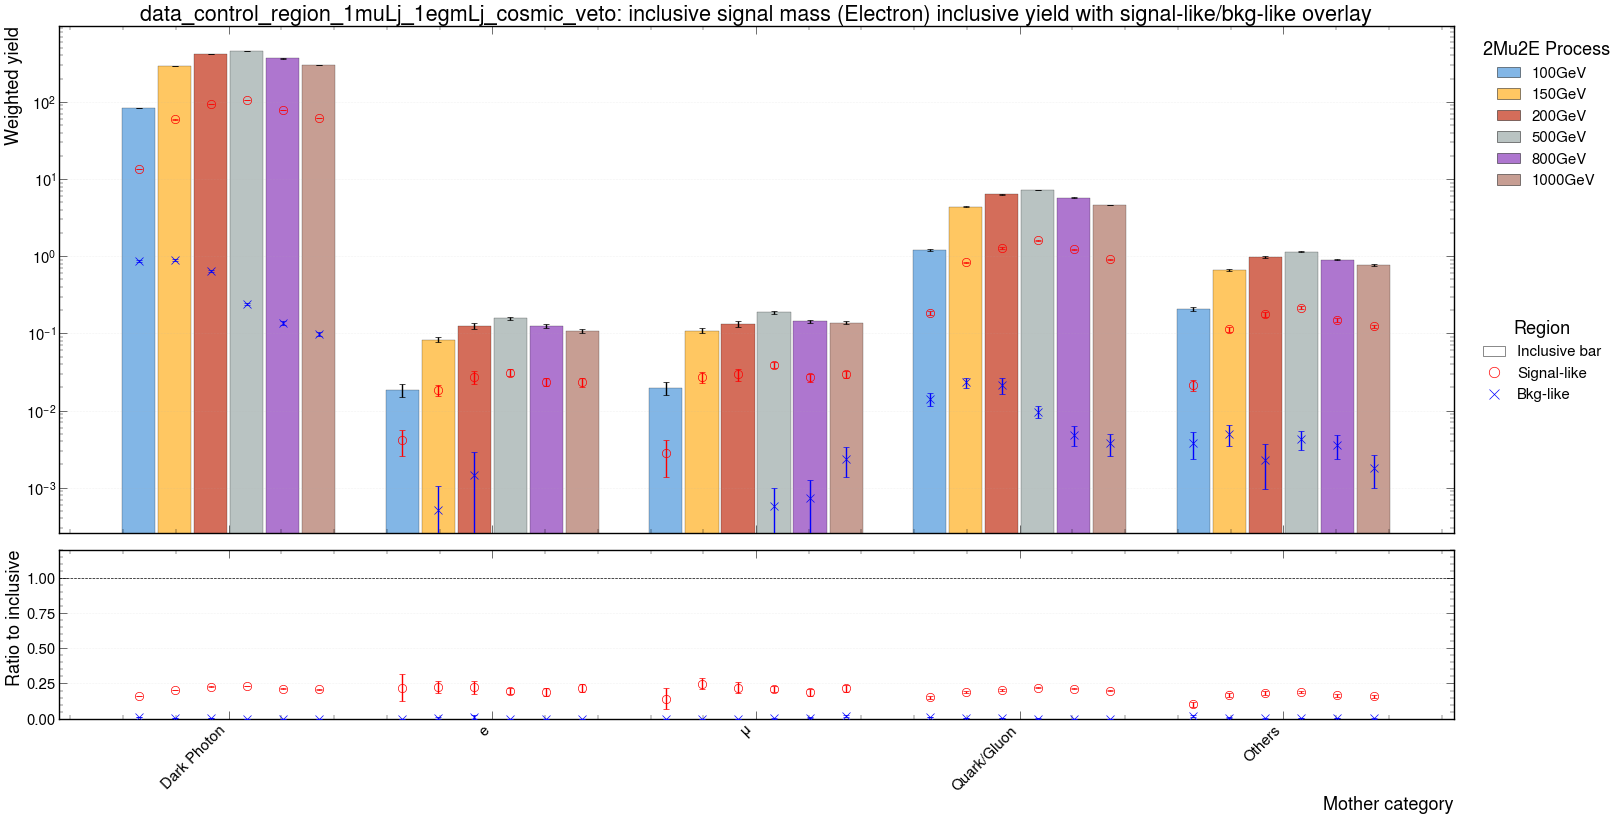

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


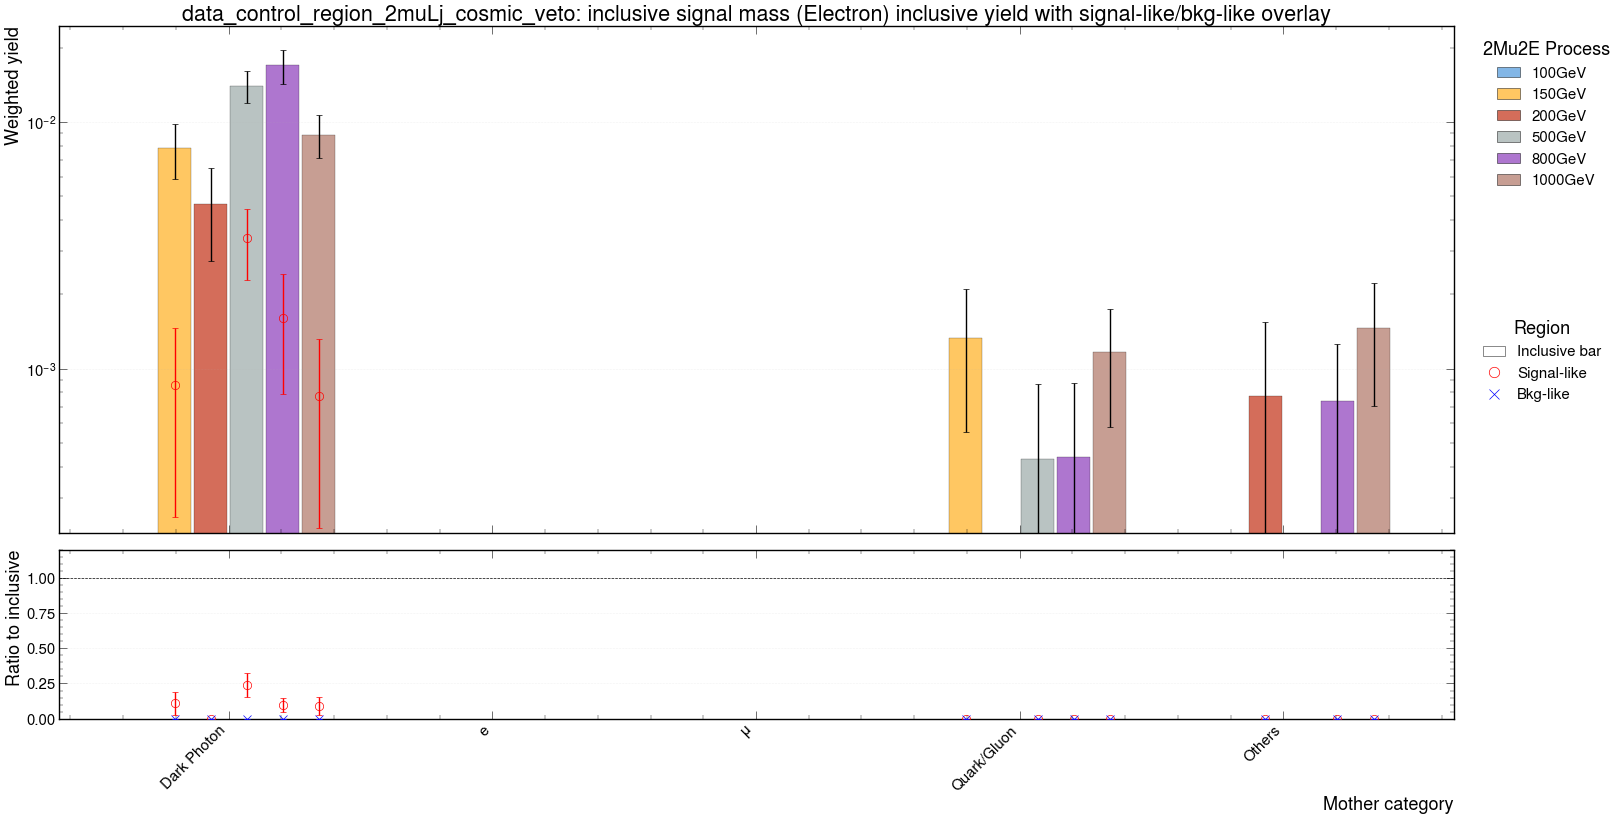


inclusive signal mass: Muon


/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


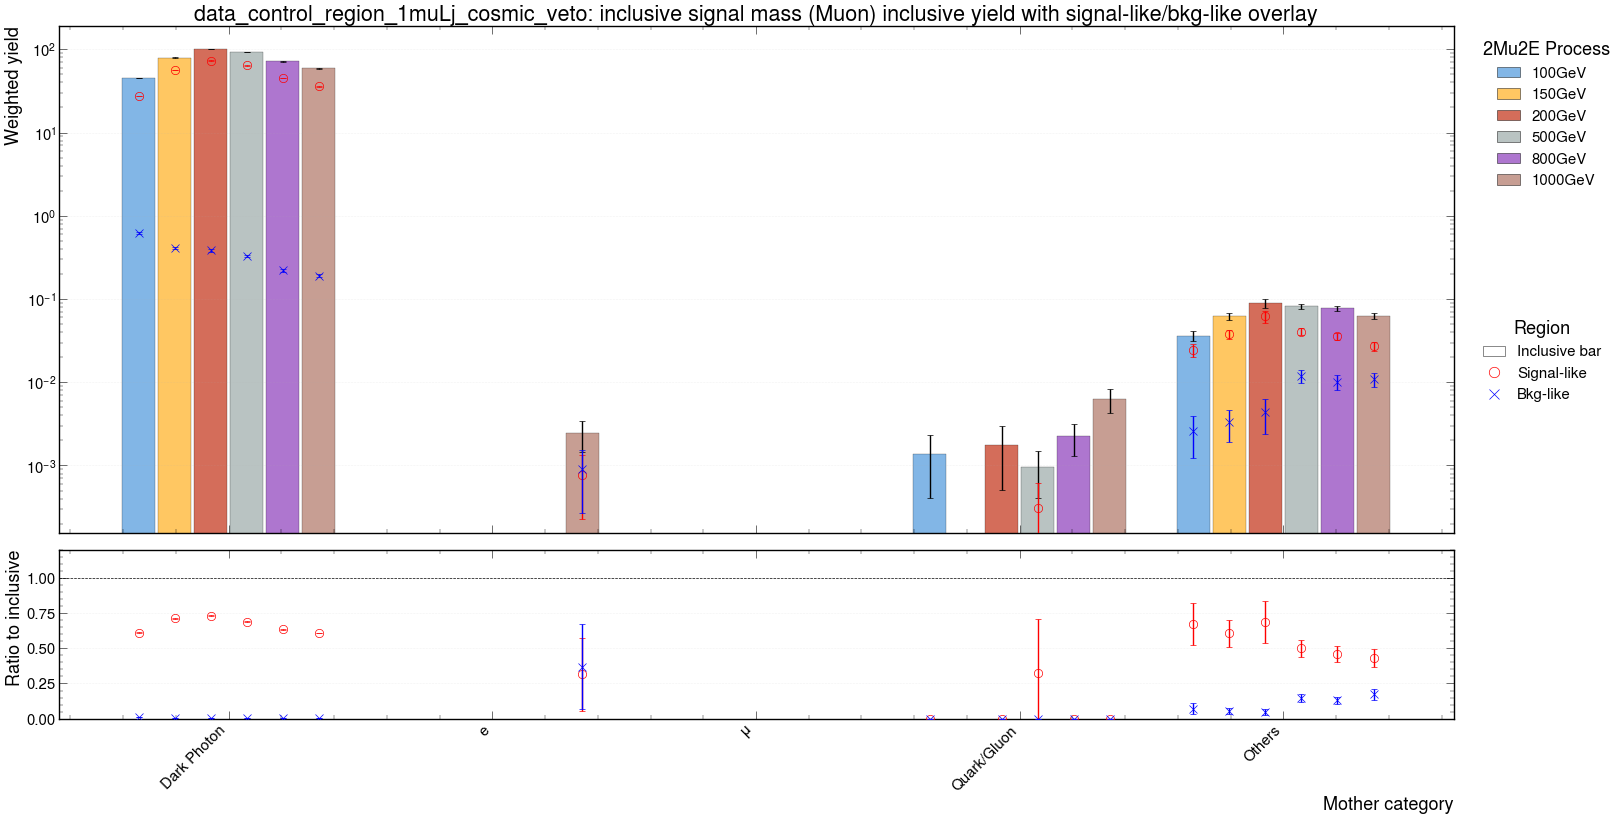

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


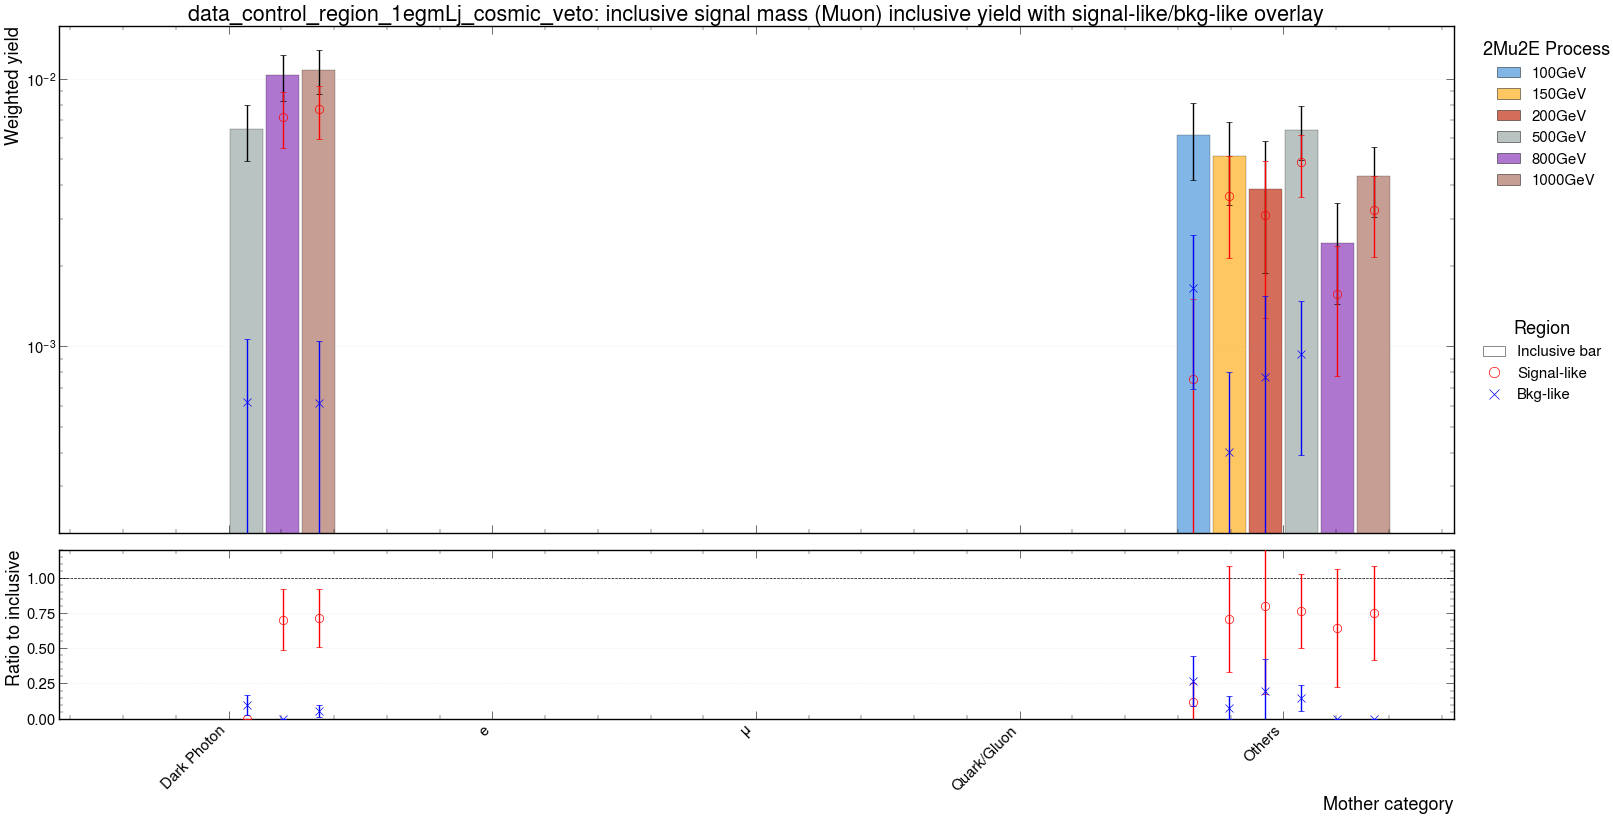

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


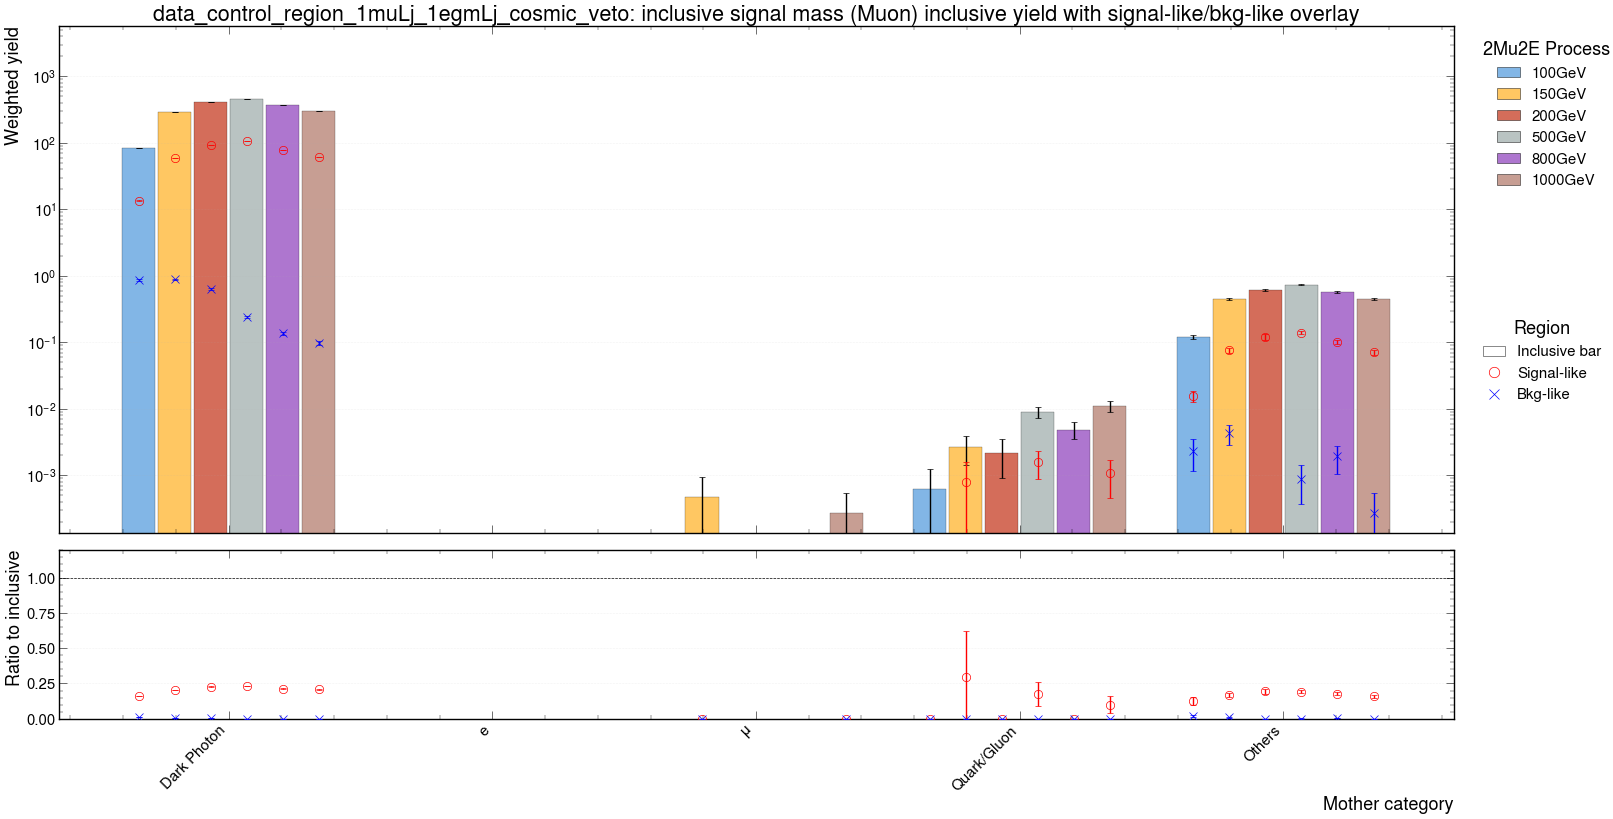

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


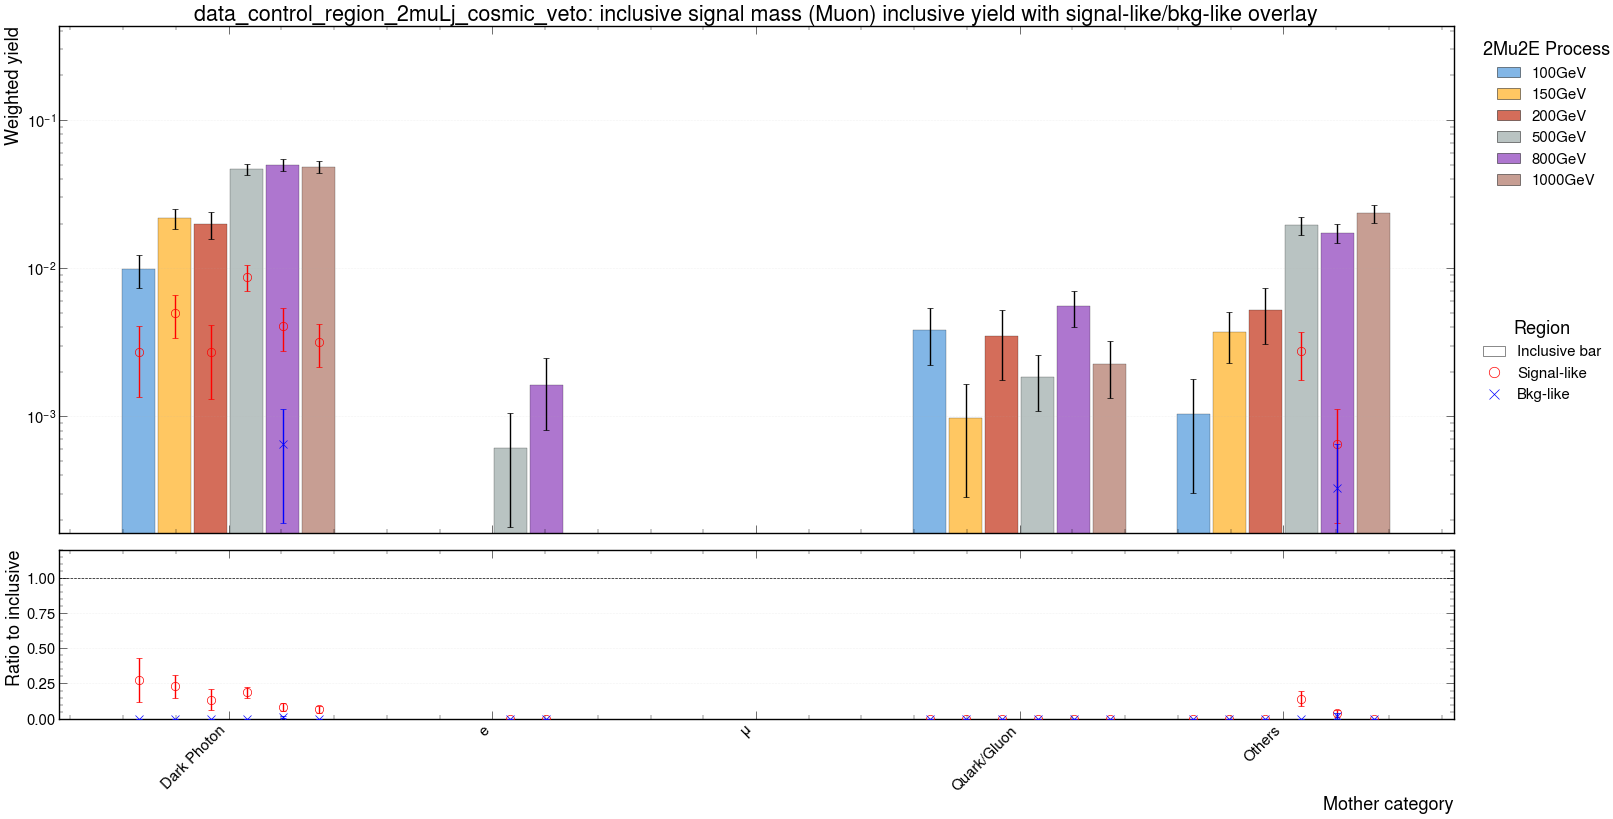


inclusive signal mass: Photon


/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


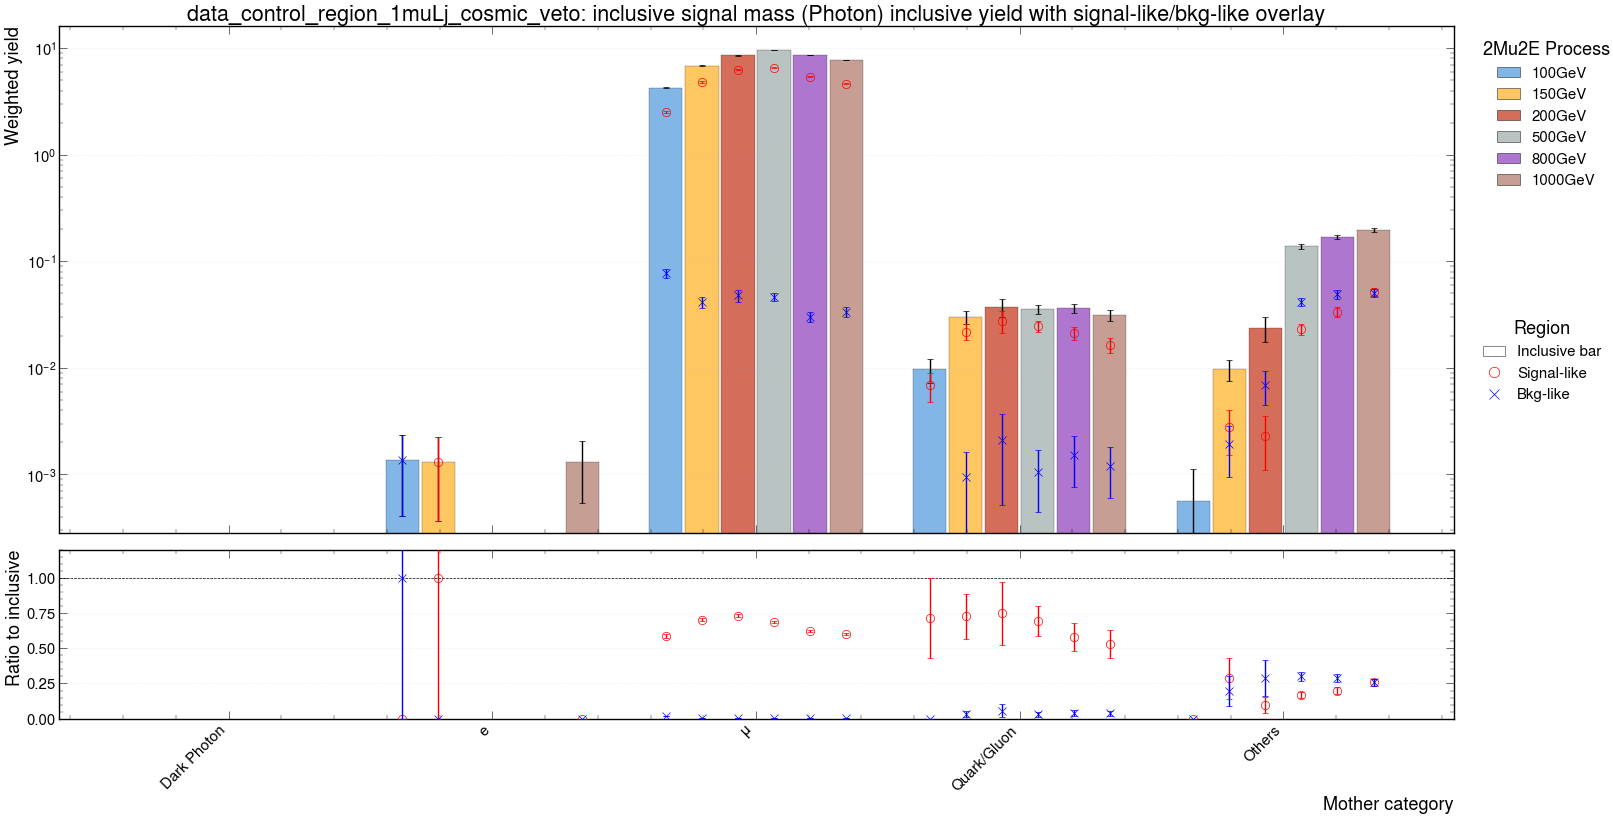

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


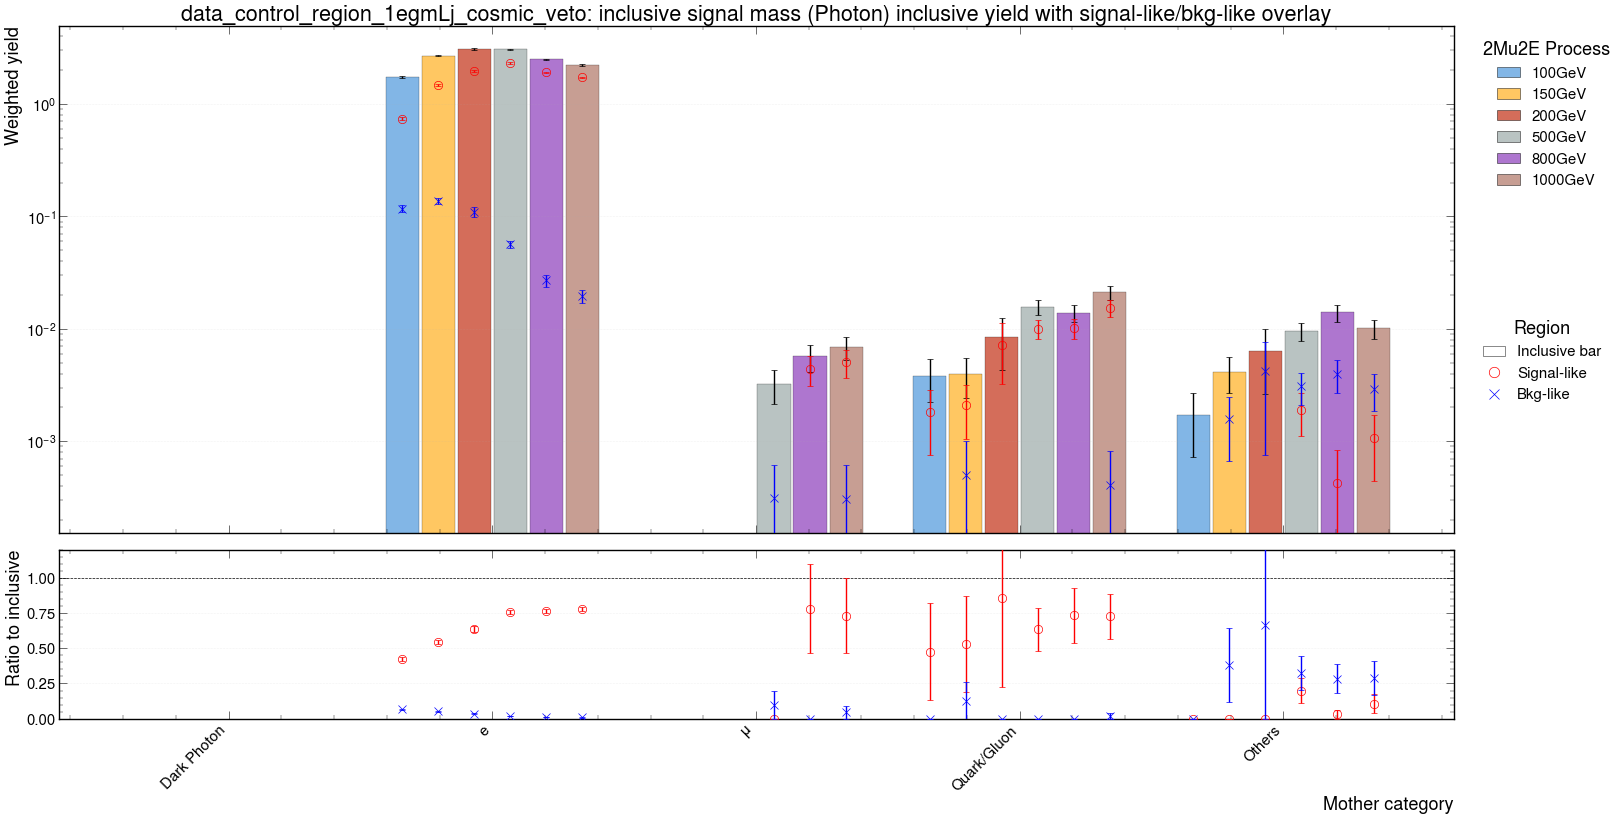

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


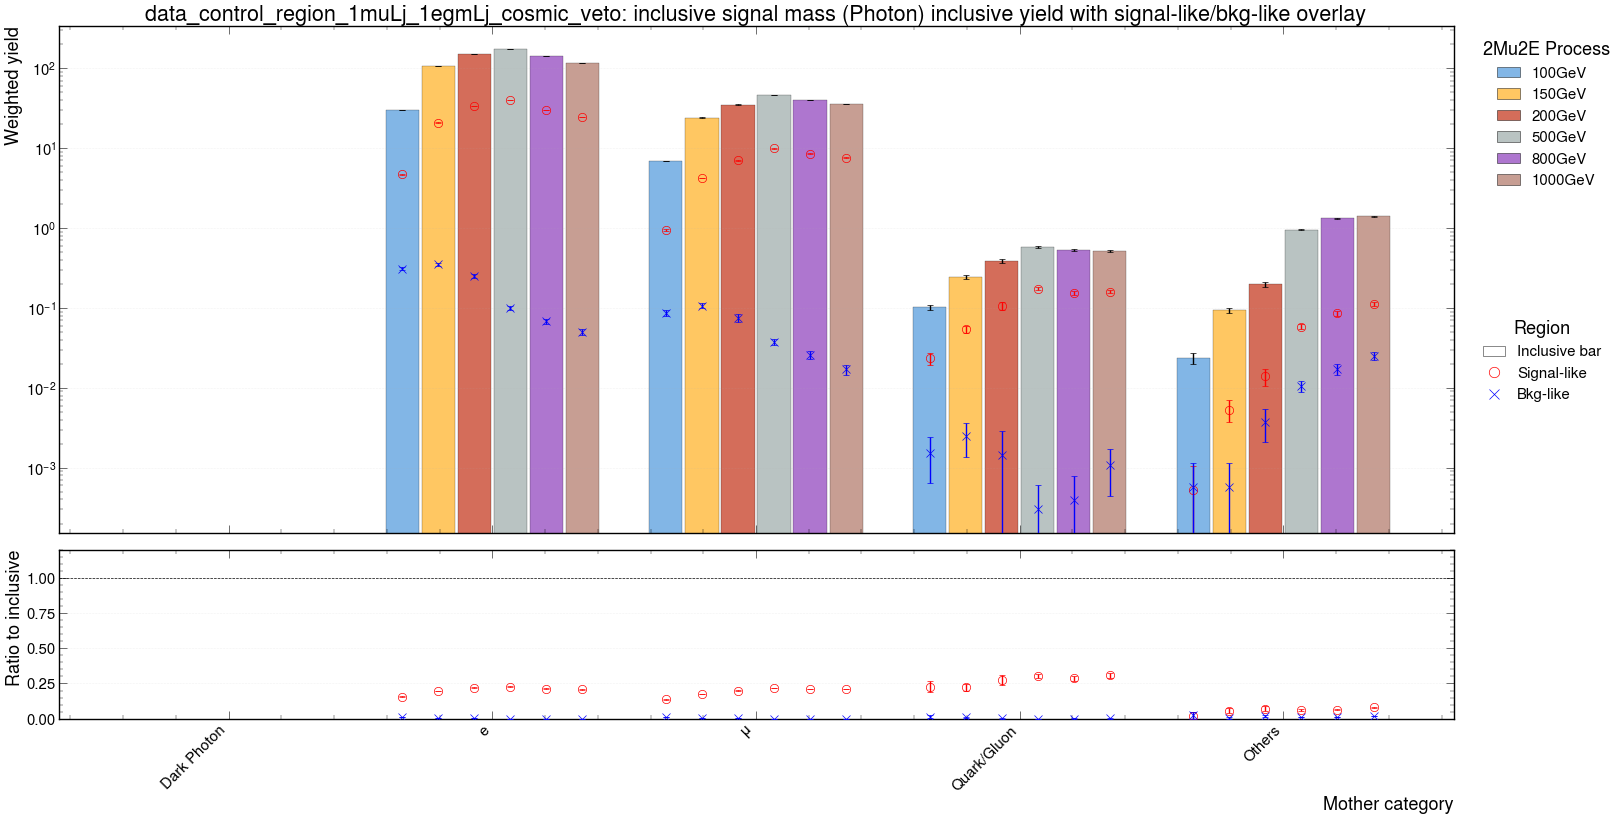

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


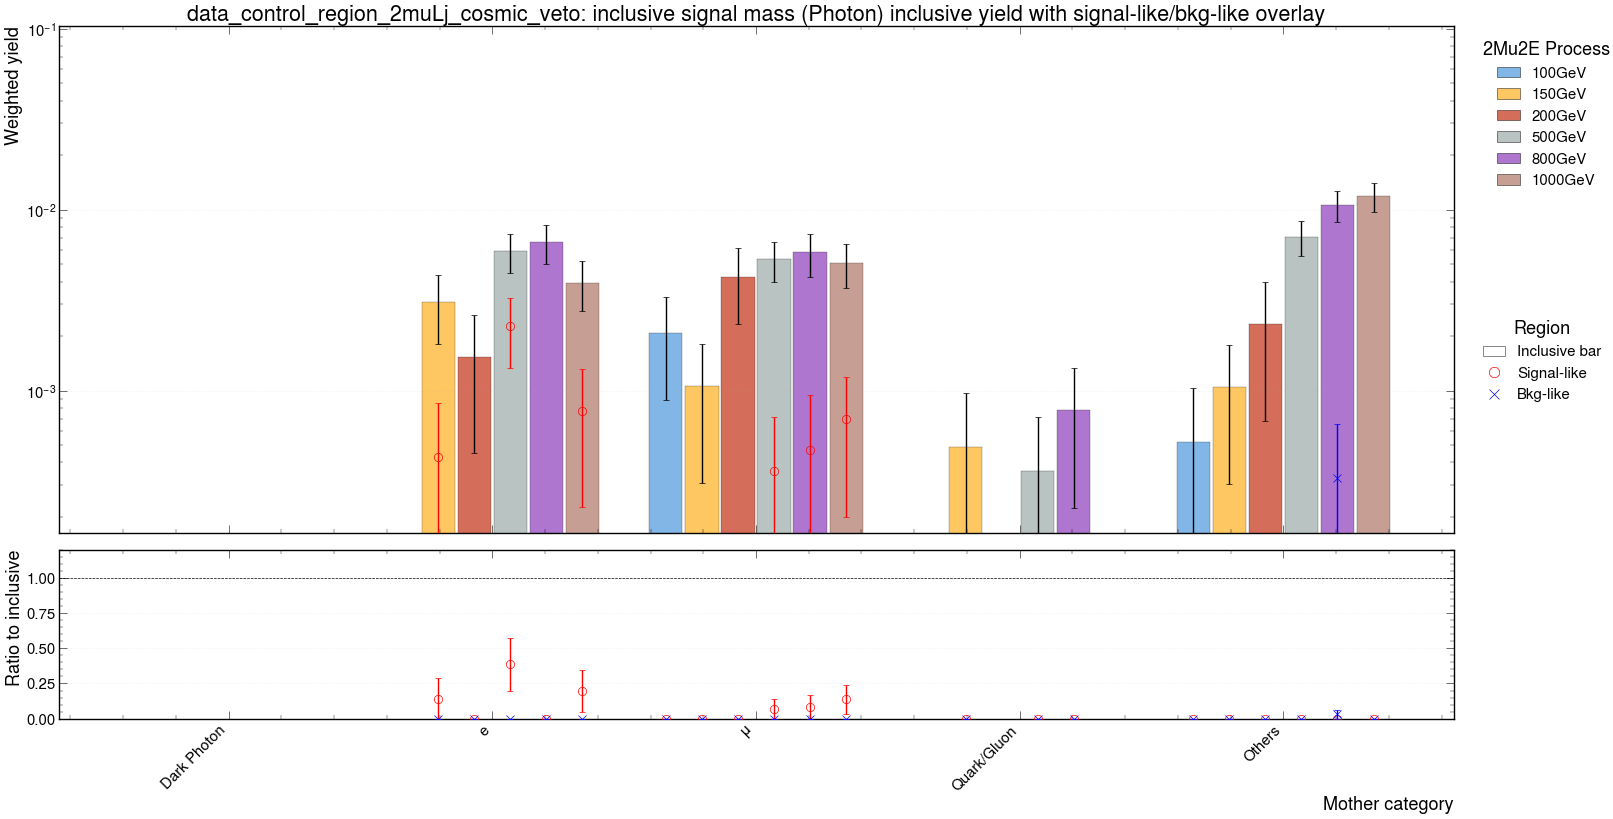


signal mass and dark-photon mass detail: Inclusive


/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


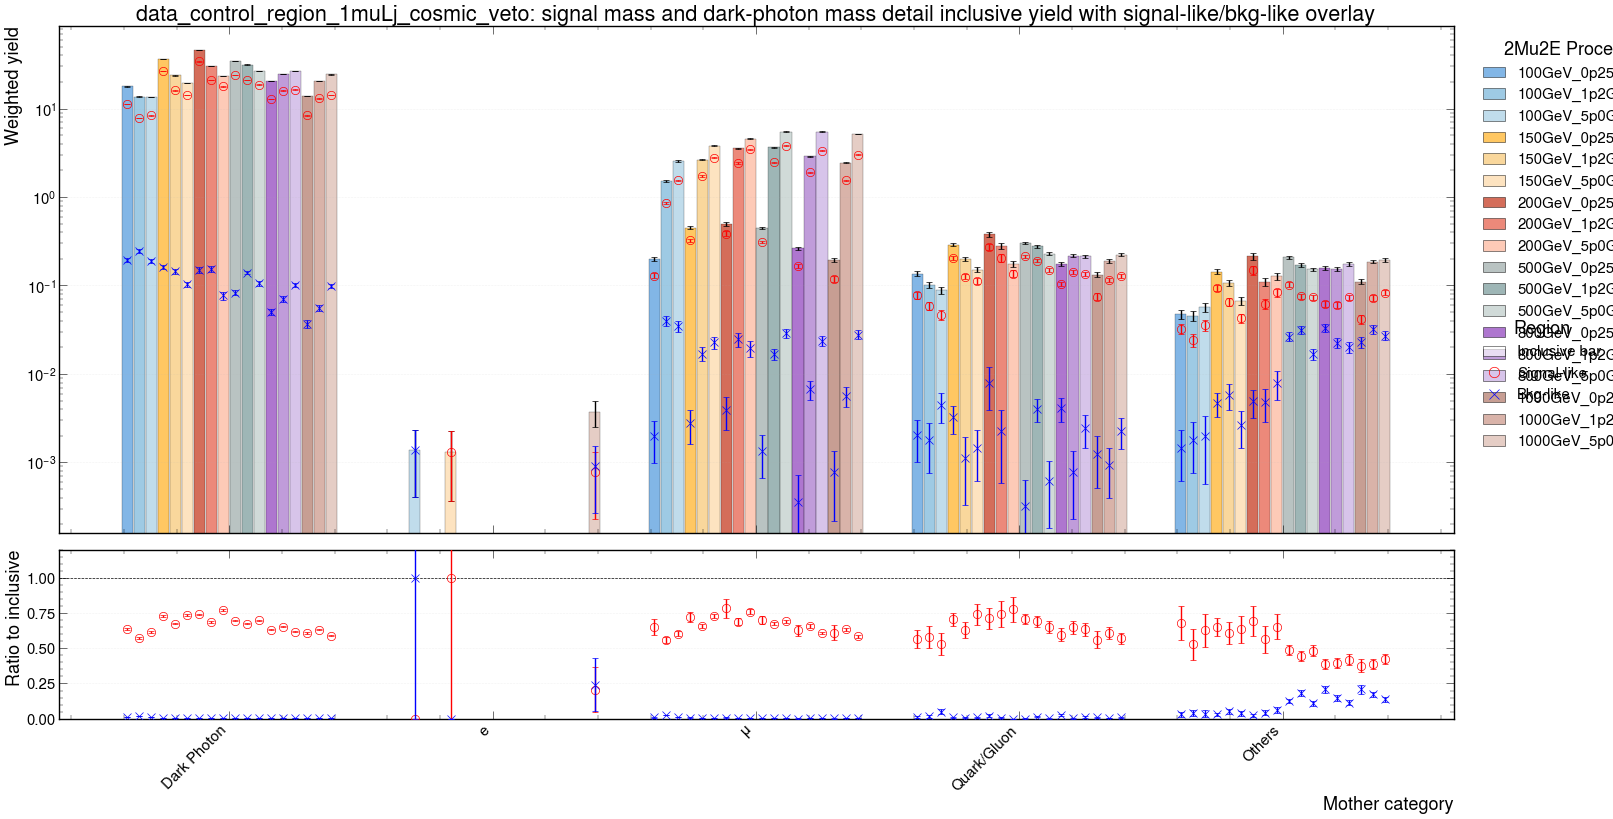

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


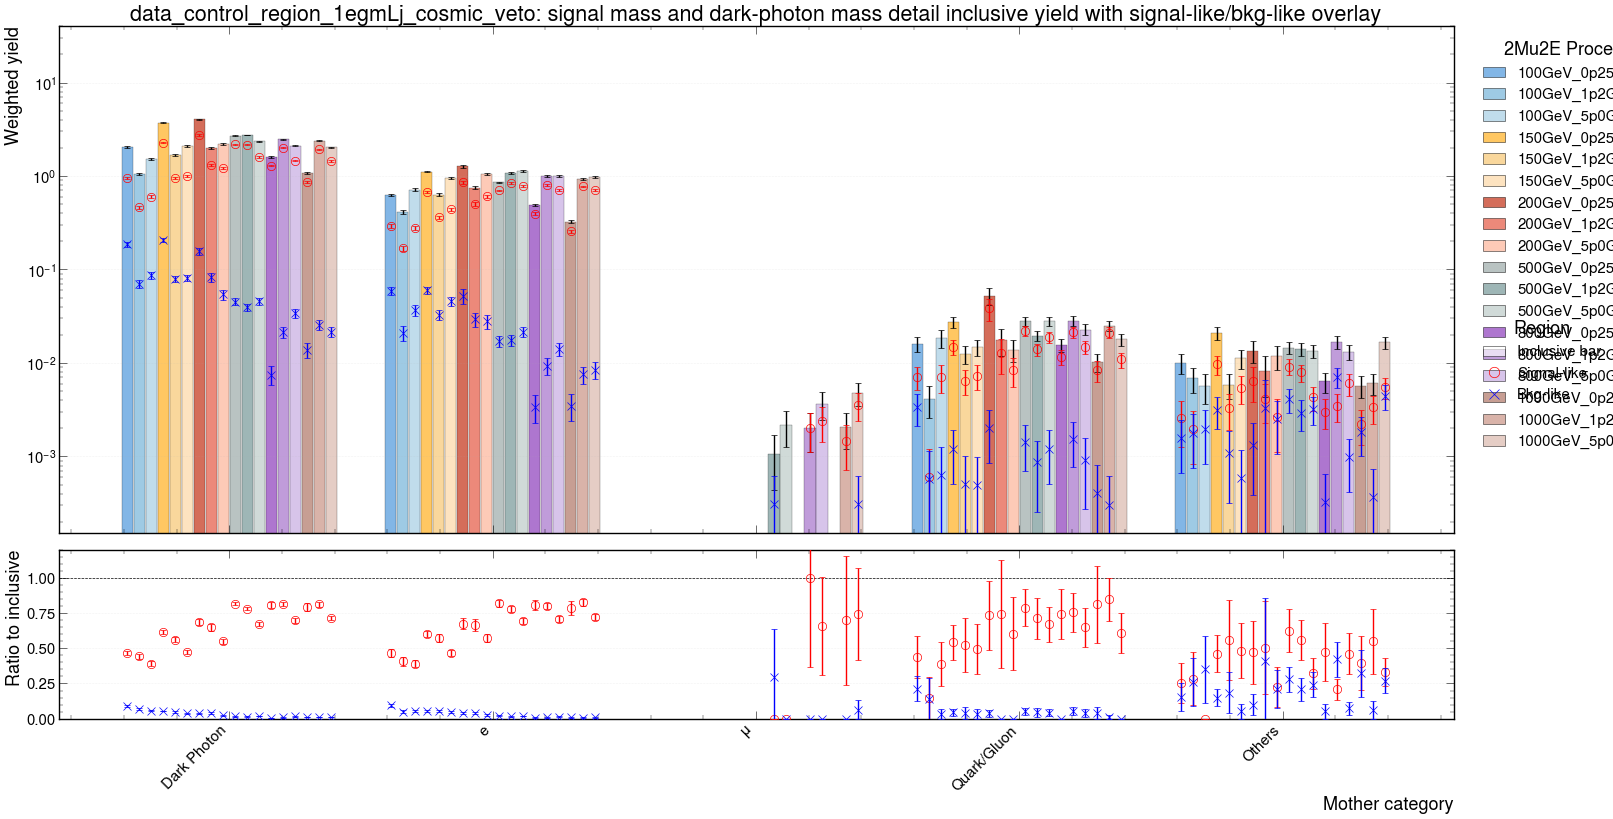

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


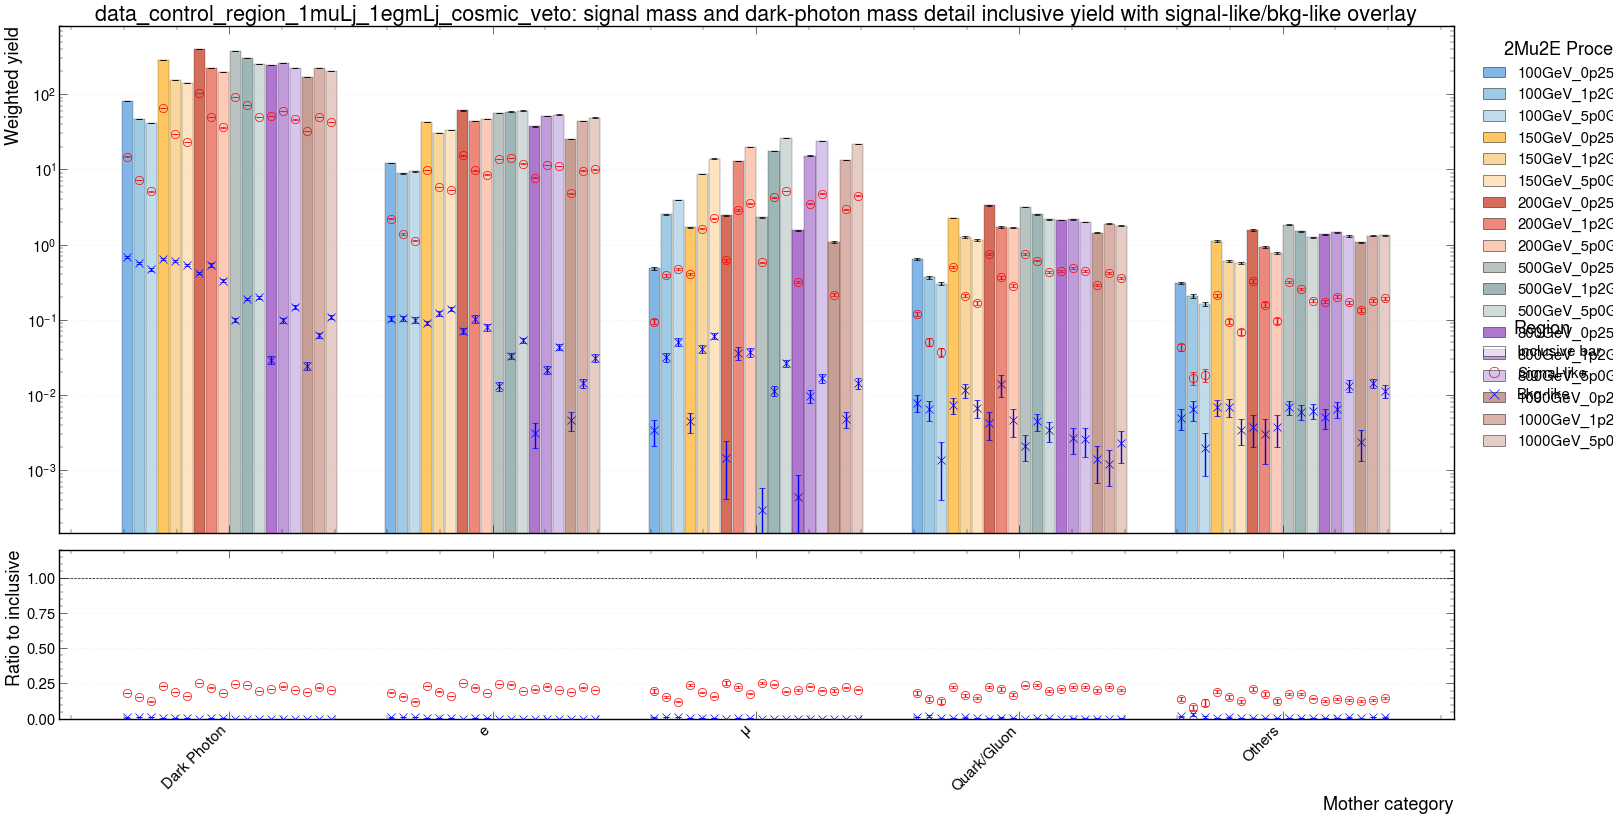

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


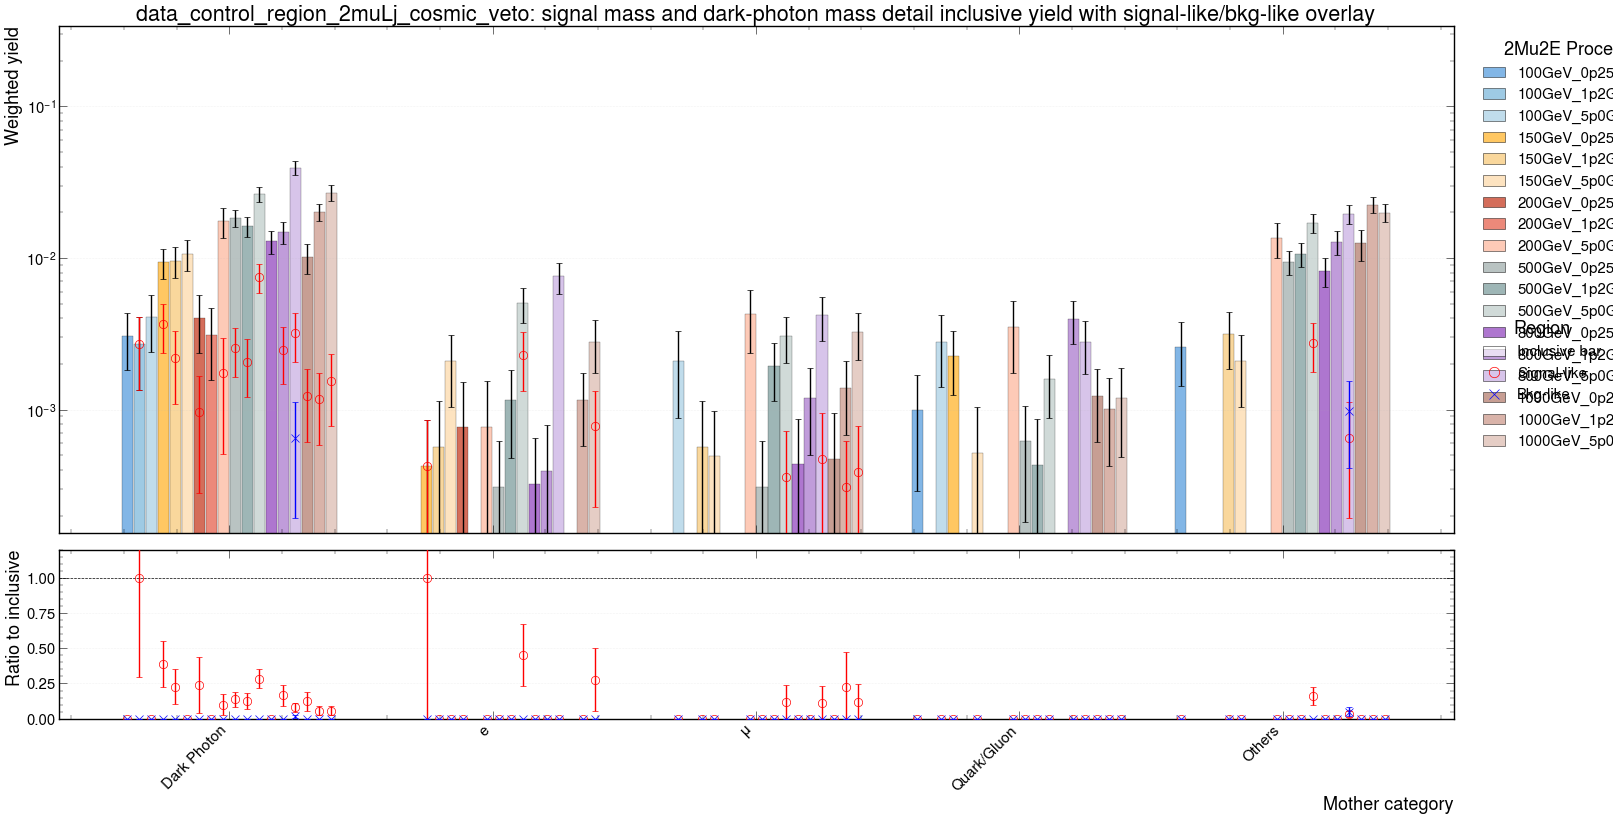


signal mass and dark-photon mass detail: Electron


/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


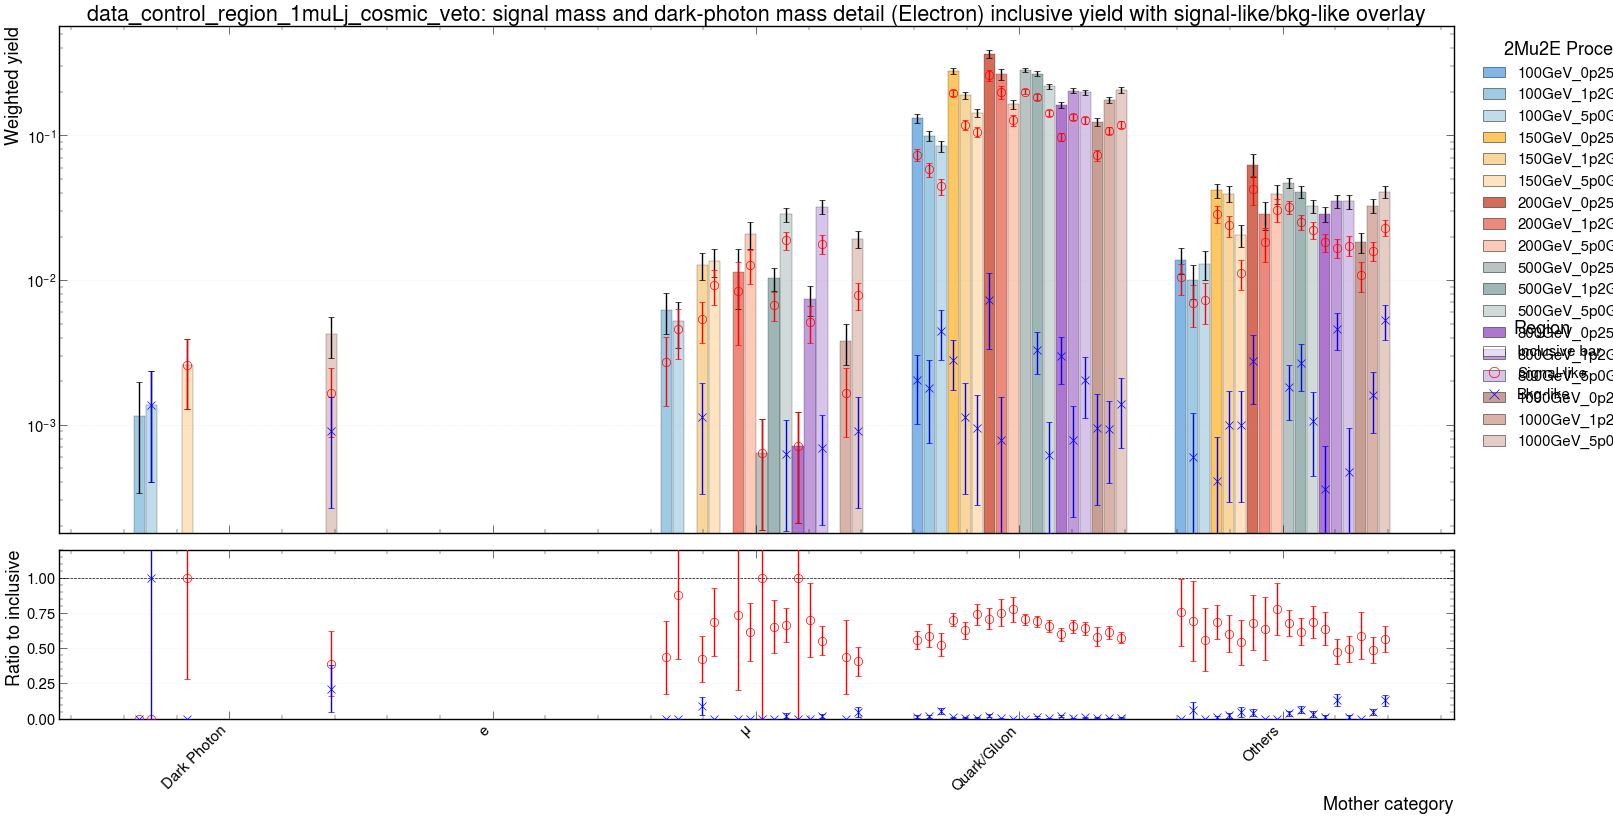

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


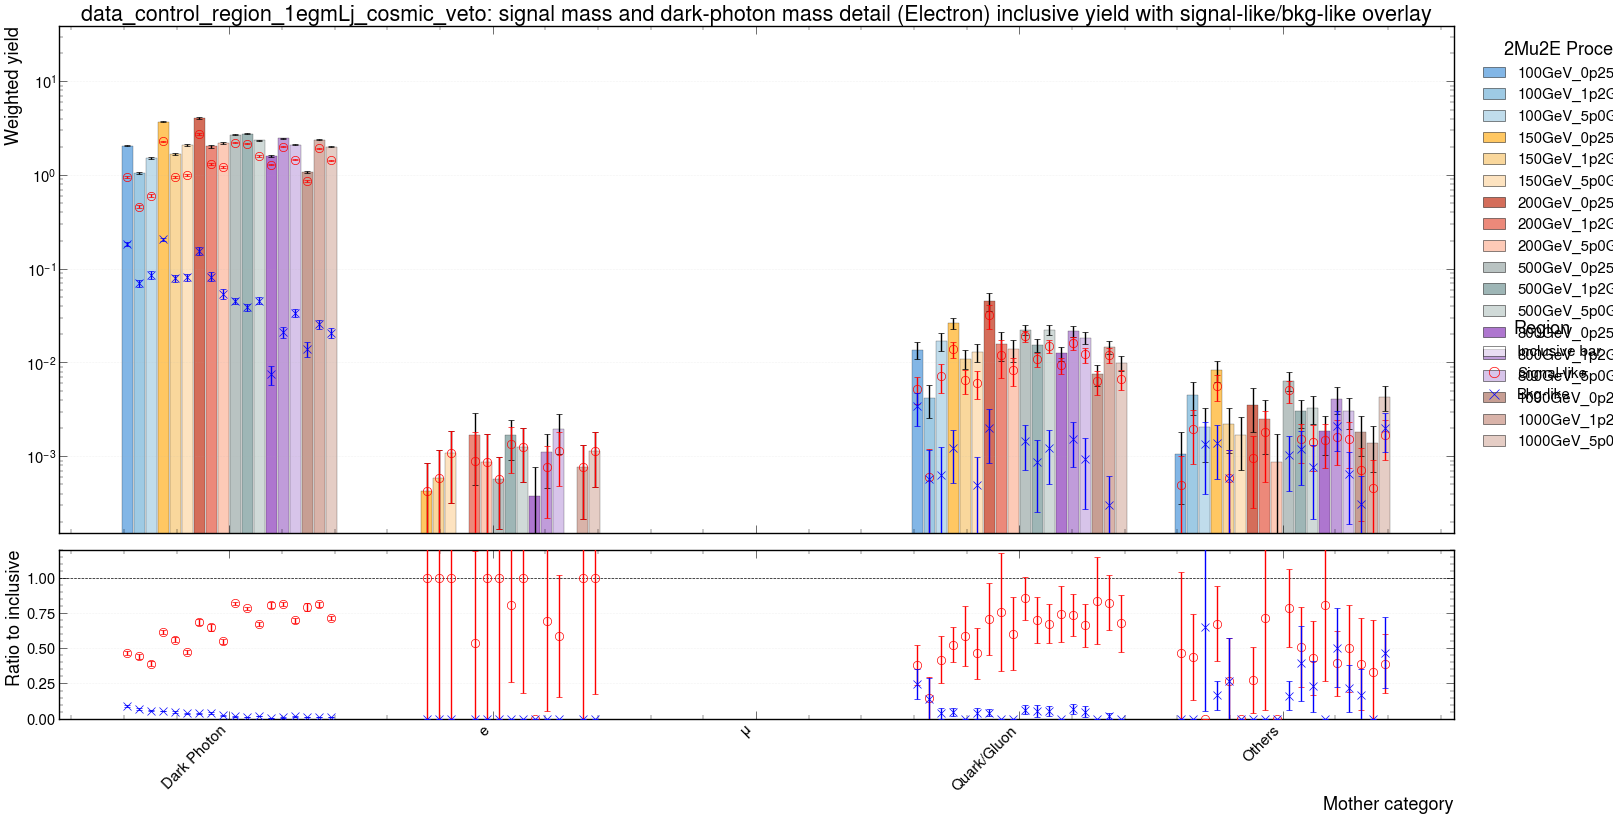

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


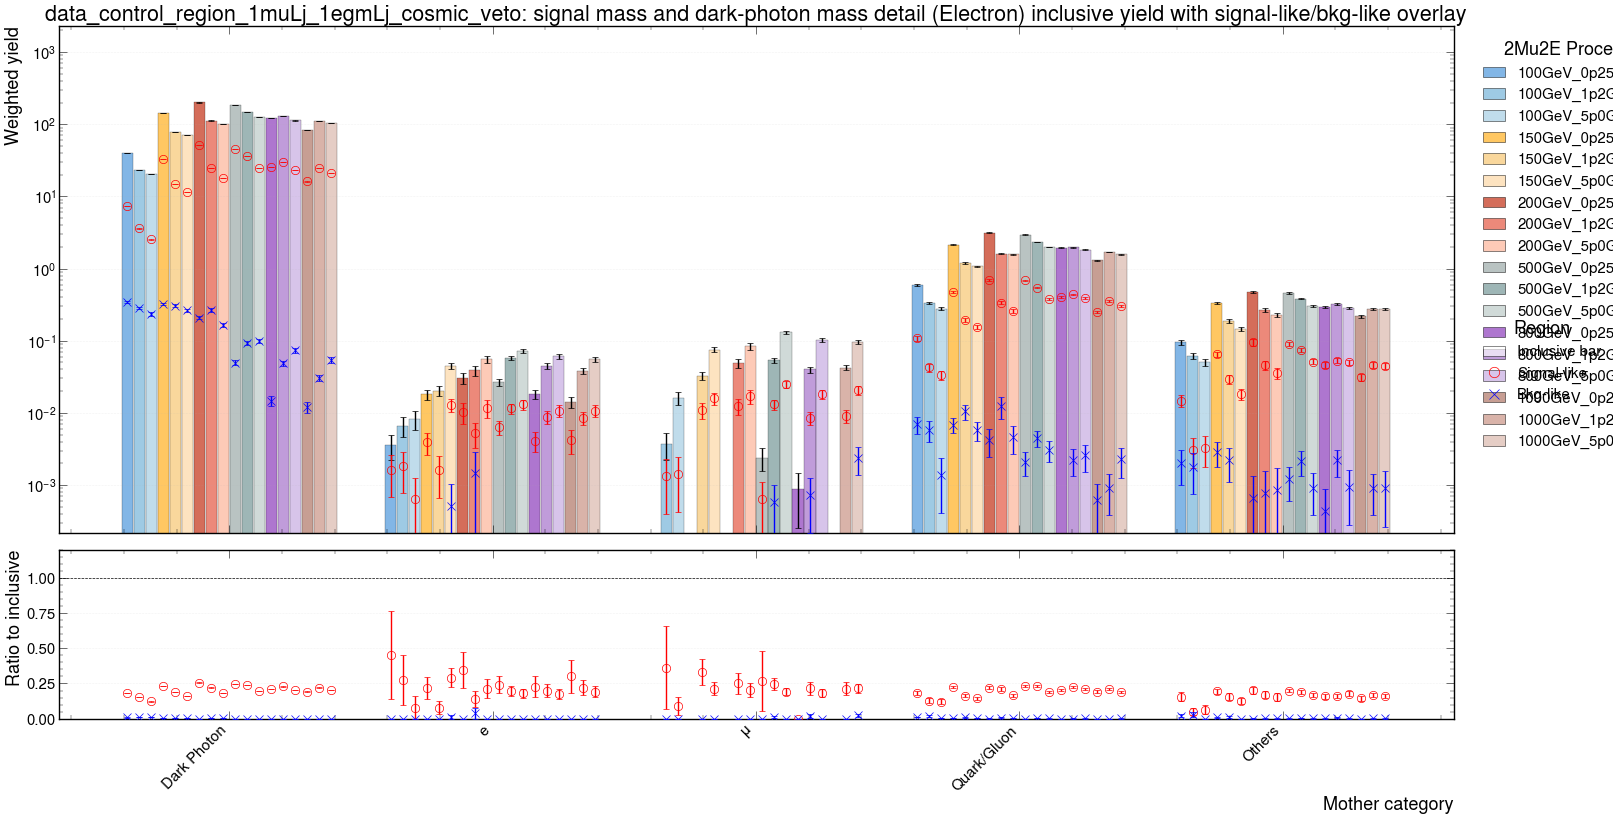

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


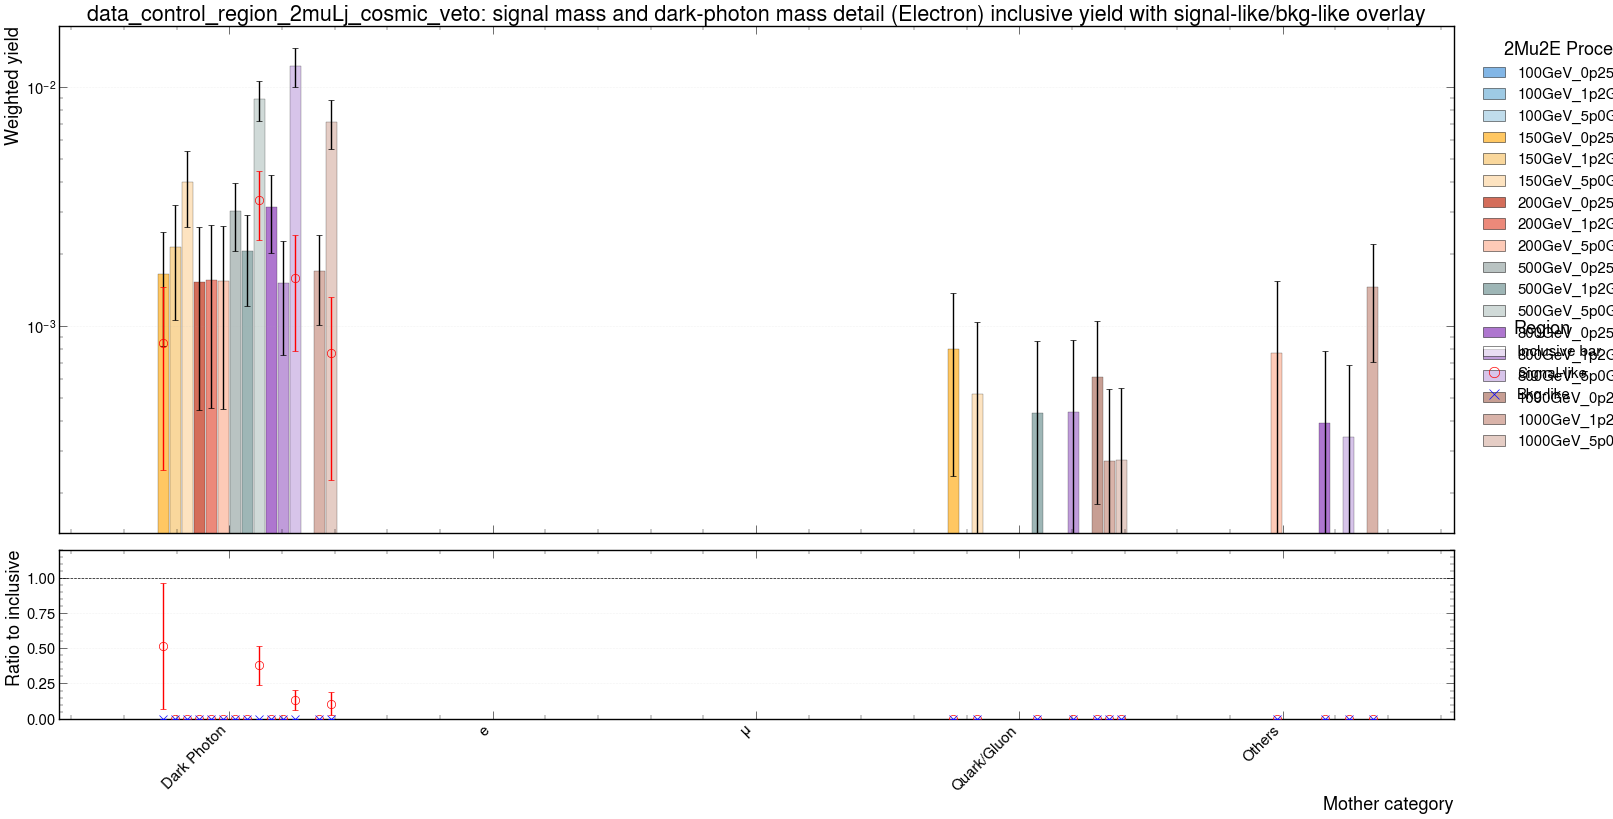


signal mass and dark-photon mass detail: Muon


/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


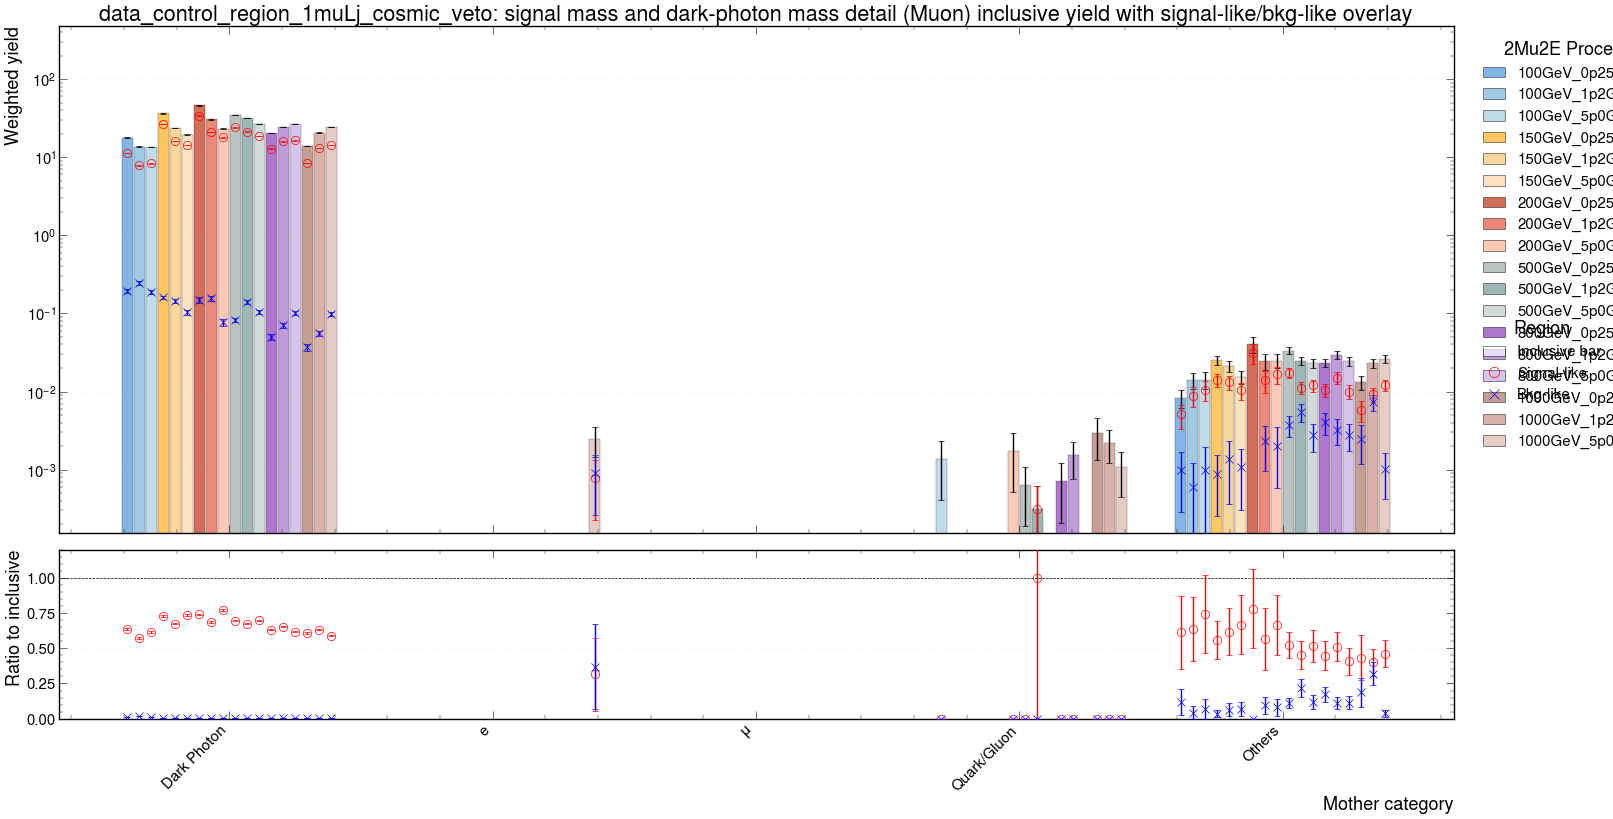

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


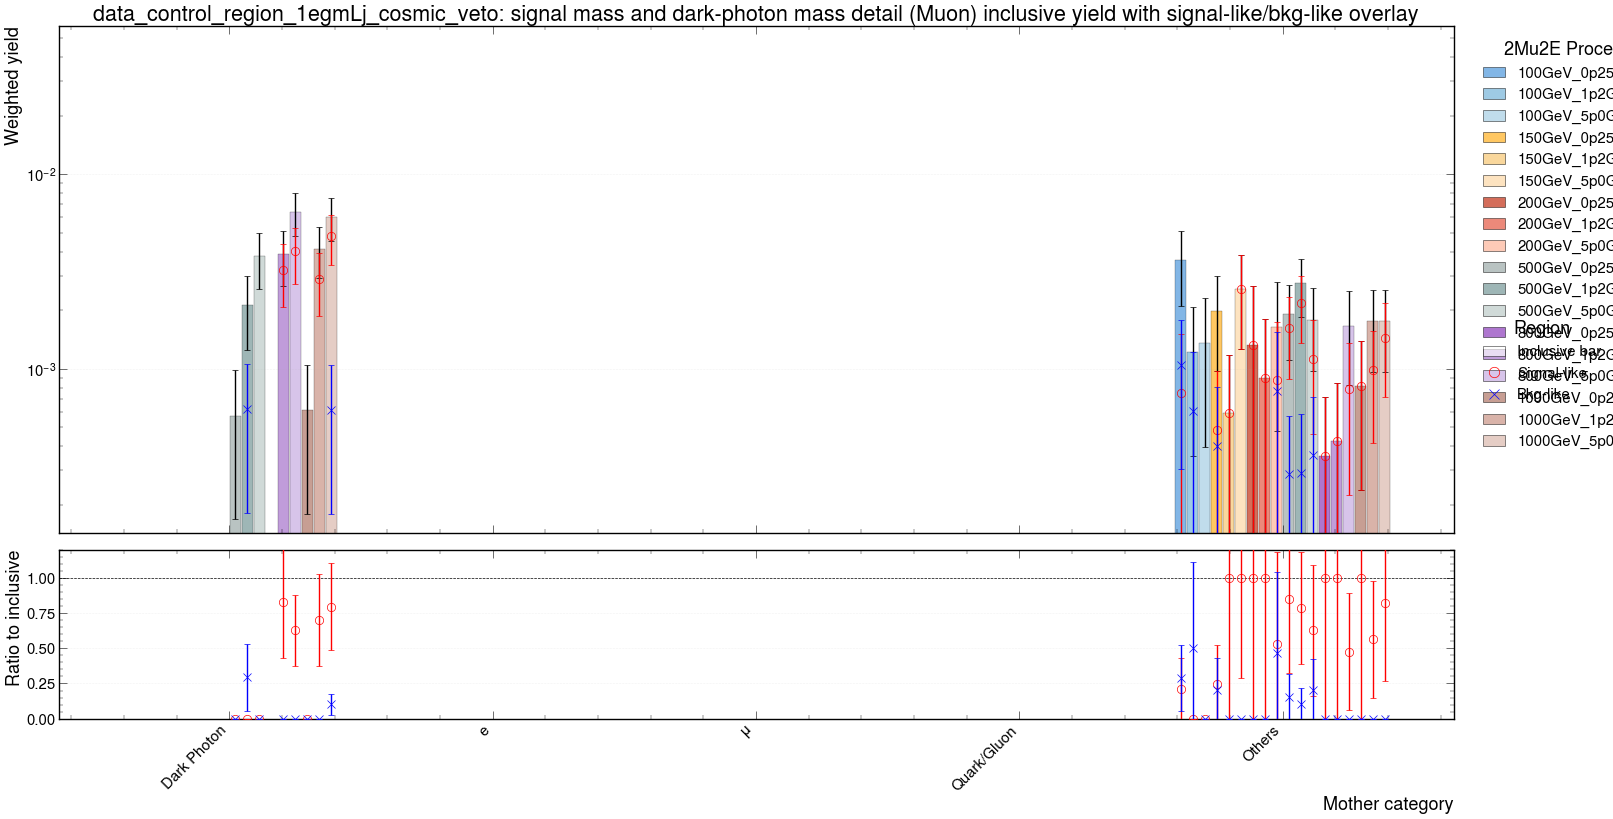

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


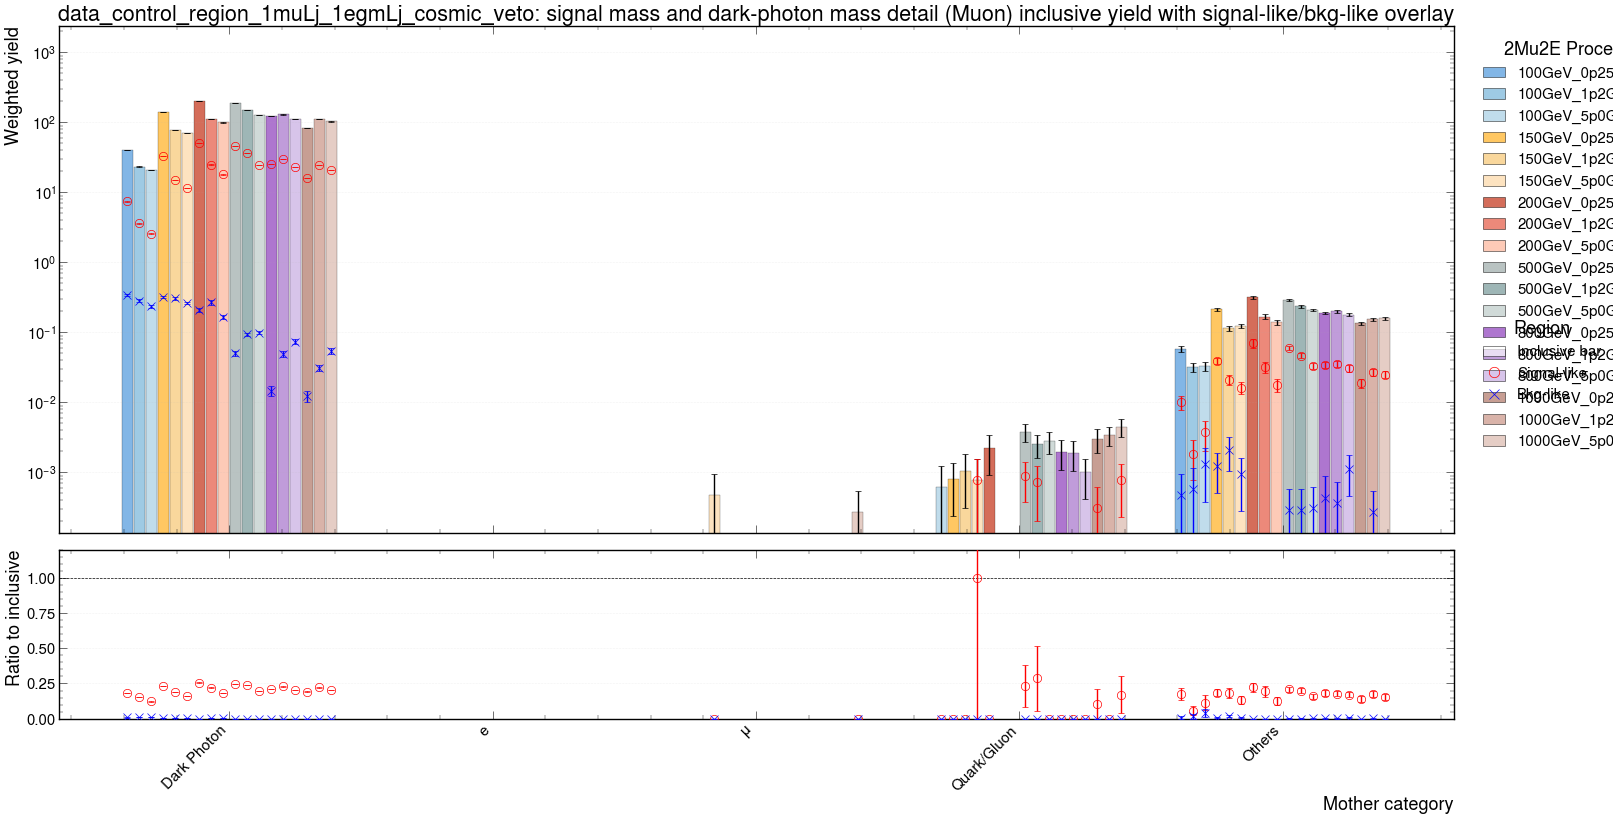

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


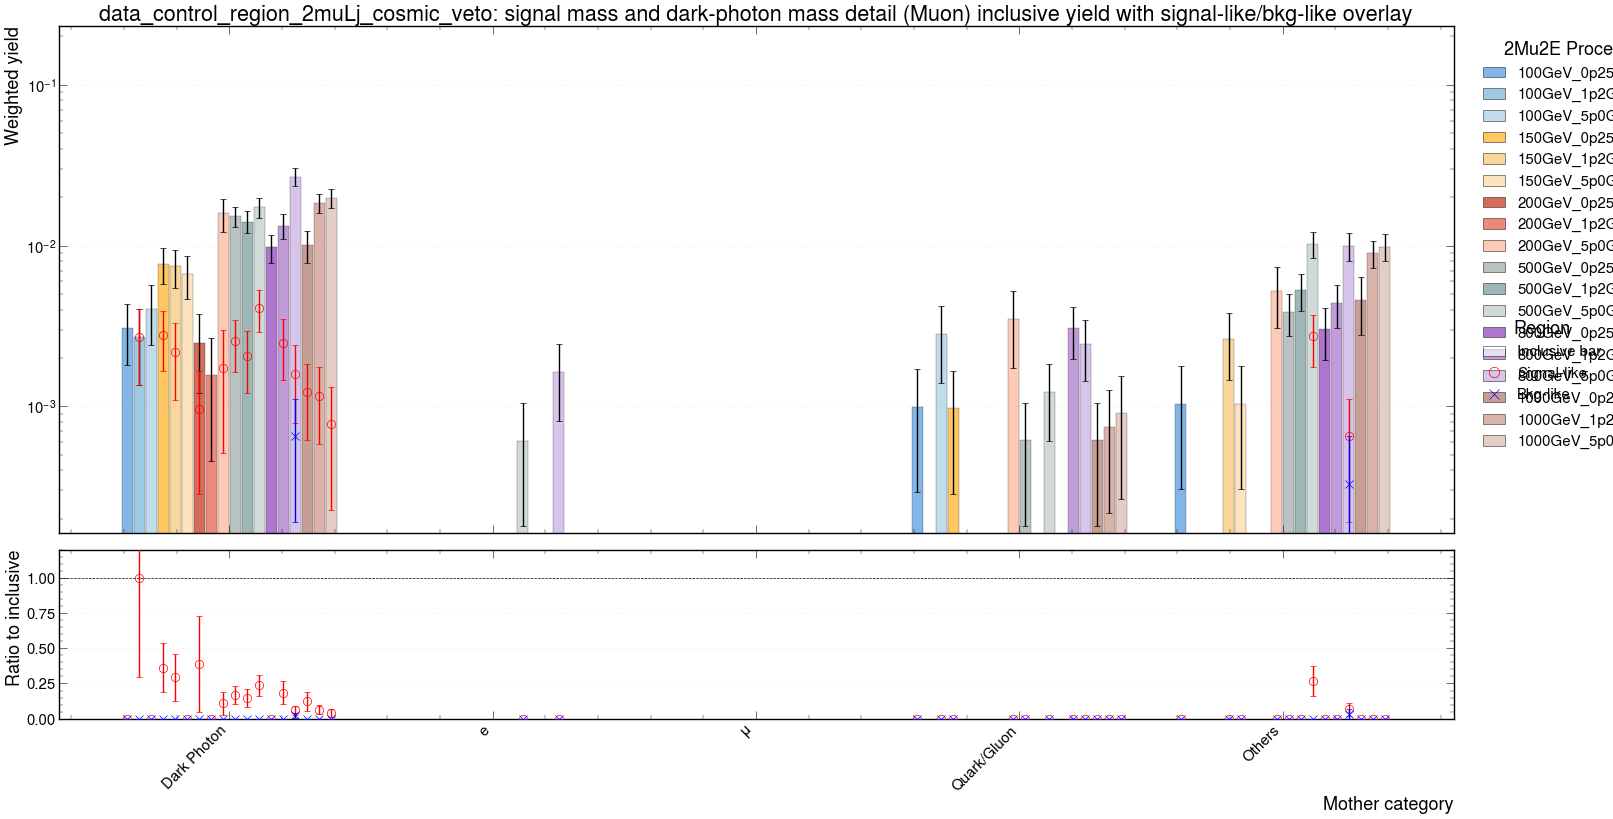


signal mass and dark-photon mass detail: Photon


/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


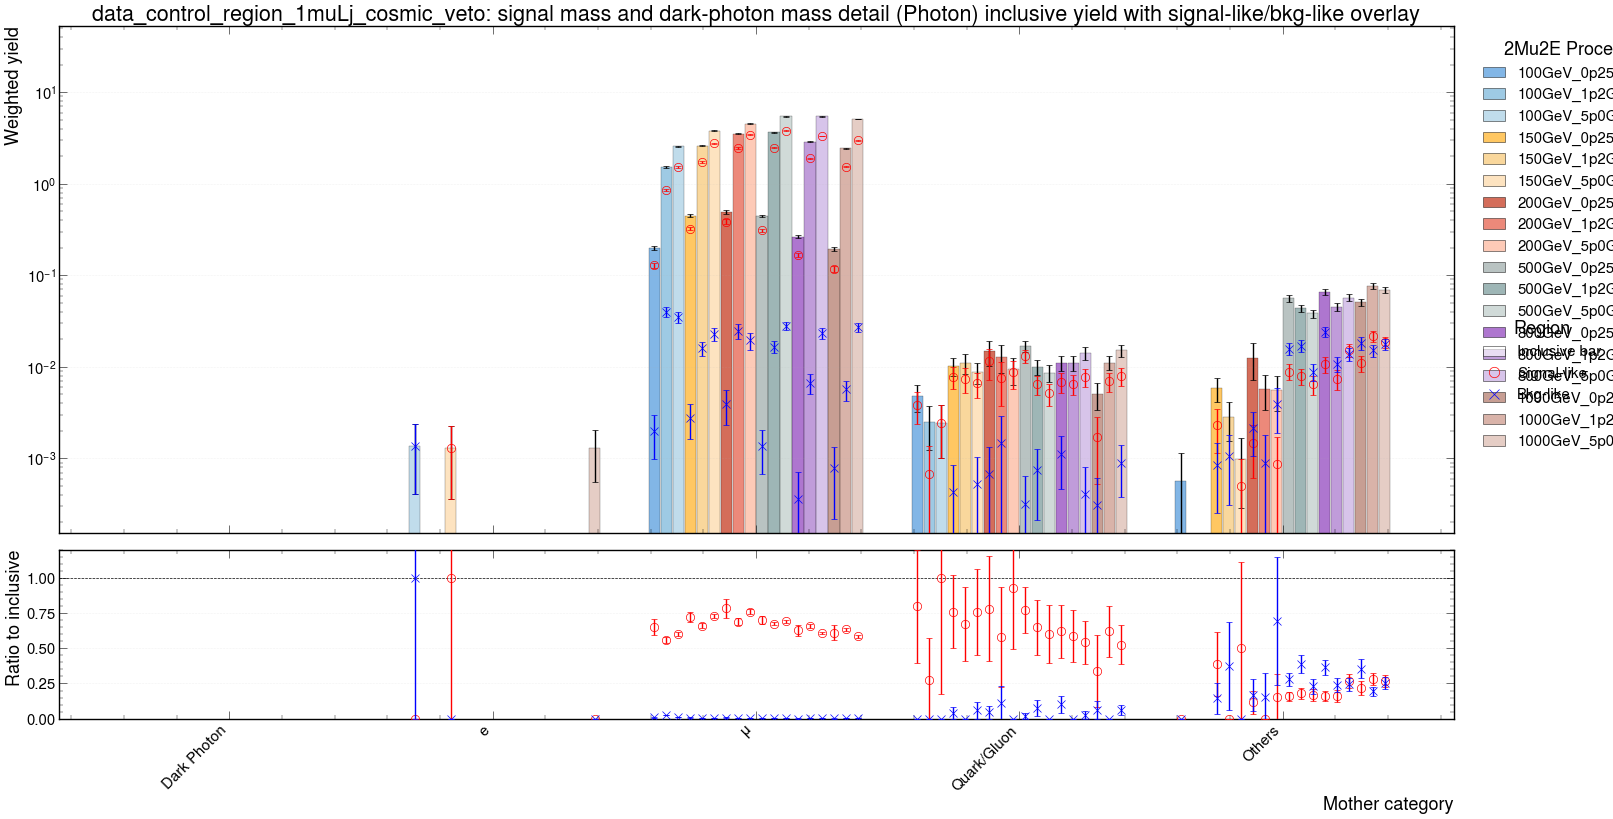

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


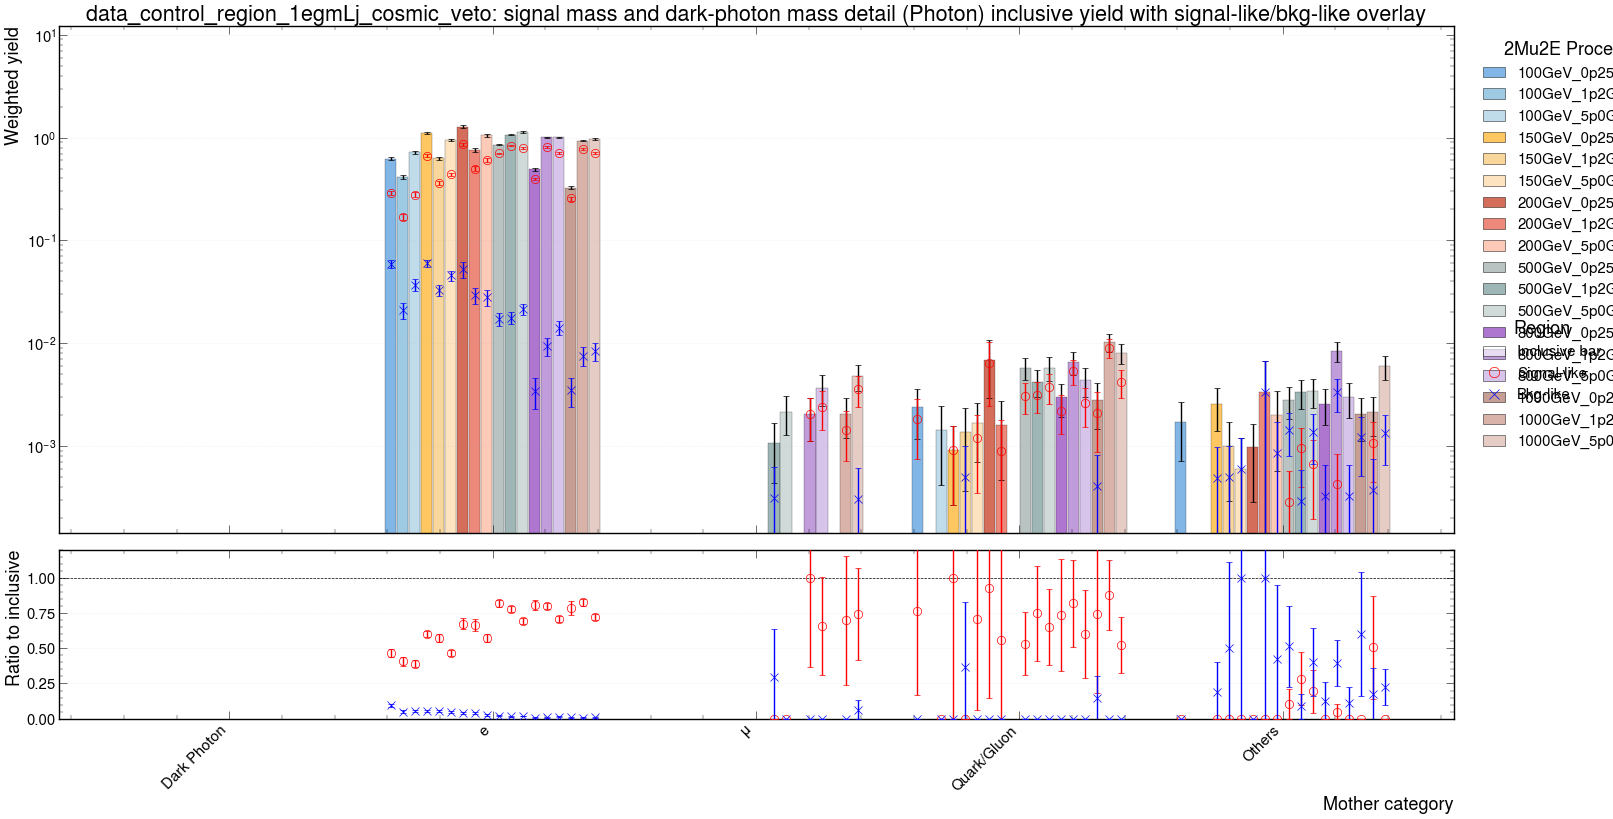

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


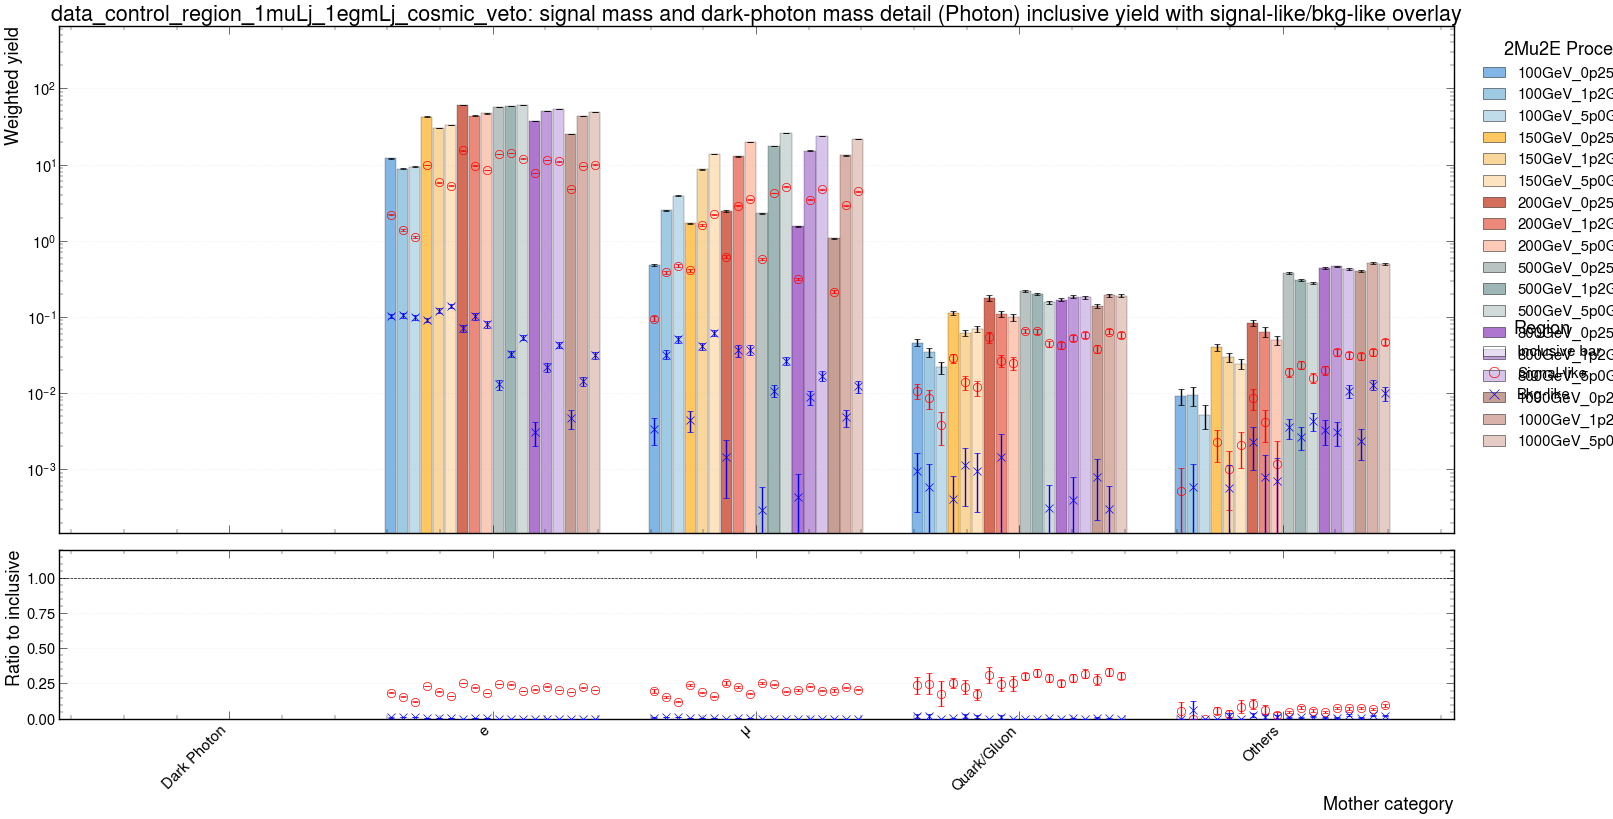

/tmp/ipykernel_1456/2615168883.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


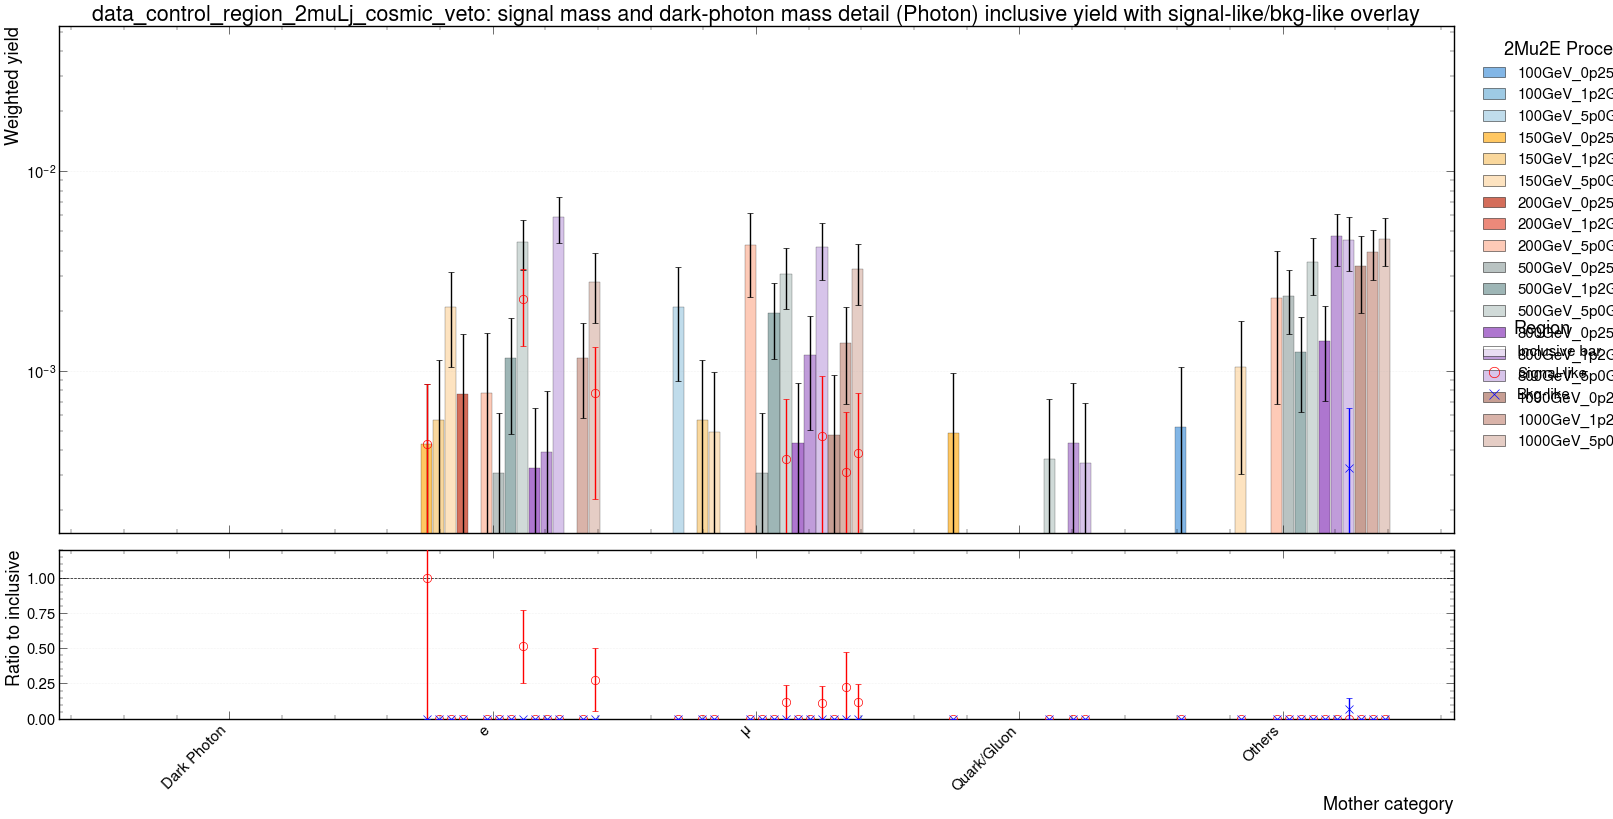

In [42]:
# ============================================================
# Process-aware inclusive yield with signal-like/bkg-like overlay
#   signal-like: isolation pass + displacement pass (_both_pass)
#   bkg-like: isolation fail + displacement fail (_both_fail)
# ============================================================

INCLUSIVE_DIR = "Mother_Tracking_LJ_Kinematics_SIG"
APPLY_CUTS_DIR = "Mother_Tracking_LJ_Kinematics_SIG"

REGION_LABELS = {
    "inclusive": "Inclusive",
    "both_pass": "Signal-like",
    "both_fail": "Bkg-like",
}

REGION_MARKER_COLORS = {
    "Signal-like": "red",
    "Bkg-like": "blue",
}

OVERLAY_HISTOGRAMS = {
    "Inclusive": "fs_gen_mother_id",
    **OBJECT_HISTOGRAMS,
}

OVERLAY_SAMPLE_GROUP_SETS = {
    "inclusive signal mass": signal_mass_groups,
    "signal mass and dark-photon mass detail": signal_detail_groups,
}

CR_CHANNEL_MAP = {
    channel: {
        "inclusive": channel,
        "both_pass": f"{channel}_both_pass",
        "both_fail": f"{channel}_both_fail",
    }
    for channel in channels
}

def resolve_mother_tracking_path(dirname):
    candidates = [
        dirname,
        os.path.join("sidm", "studies", "Mother_Tracking", dirname),
        os.path.join(os.getcwd(), dirname),
    ]

    for candidate in candidates:
        if os.path.isdir(candidate):
            return candidate

    raise FileNotFoundError(f"Could not find directory: {dirname}")

def load_coffea_outputs(sample_names, dirname):
    output = {}
    directory = resolve_mother_tracking_path(dirname)

    for sample in sample_names:
        path = os.path.join(directory, f"{sample}.coffea")
        if not os.path.exists(path):
            print(f"[WARNING] missing coffea file: {path}")
            continue

        loaded = coffea.util.load(path)
        output[sample] = get_sample_output(loaded, sample)

    return output

def unique_group_samples(sample_groups):
    samples = []
    for group_samples in sample_groups.values():
        for sample in group_samples:
            if sample not in samples:
                samples.append(sample)
    return samples

def unique_samples_from_group_sets(sample_group_sets):
    samples = []
    for sample_groups in sample_group_sets.values():
        for sample in unique_group_samples(sample_groups):
            if sample not in samples:
                samples.append(sample)
    return samples

def make_process_region_tables(
    inclusive_output,
    apply_cuts_output,
    sample_groups,
    channel,
    histogram_name="fs_gen_mother_id",
):
    channel_map = CR_CHANNEL_MAP[channel]

    inclusive_yield, inclusive_error, _ = make_category_tables(
        inclusive_output,
        sample_groups,
        channel_map["inclusive"],
        histogram_name,
        categorize_signal_mother,
        SIGNAL_CATEGORY_ORDER,
    )
    pass_yield, pass_error, _ = make_category_tables(
        apply_cuts_output,
        sample_groups,
        channel_map["both_pass"],
        histogram_name,
        categorize_signal_mother,
        SIGNAL_CATEGORY_ORDER,
    )
    fail_yield, fail_error, _ = make_category_tables(
        apply_cuts_output,
        sample_groups,
        channel_map["both_fail"],
        histogram_name,
        categorize_signal_mother,
        SIGNAL_CATEGORY_ORDER,
    )

    inclusive_yield = inclusive_yield.fillna(0.0)
    pass_yield = pass_yield.reindex_like(inclusive_yield).fillna(0.0)
    fail_yield = fail_yield.reindex_like(inclusive_yield).fillna(0.0)

    inclusive_error = inclusive_error.reindex_like(inclusive_yield).fillna(0.0)
    pass_error = pass_error.reindex_like(inclusive_yield).fillna(0.0)
    fail_error = fail_error.reindex_like(inclusive_yield).fillna(0.0)

    return {
        REGION_LABELS["inclusive"]: inclusive_yield,
        REGION_LABELS["both_pass"]: pass_yield,
        REGION_LABELS["both_fail"]: fail_yield,
        "_errors": {
            REGION_LABELS["inclusive"]: inclusive_error,
            REGION_LABELS["both_pass"]: pass_error,
            REGION_LABELS["both_fail"]: fail_error,
        },
    }

def ratio_uncertainty(numerator, numerator_error, denominator, denominator_error):
    numerator = np.asarray(numerator, dtype=float)
    numerator_error = np.asarray(numerator_error, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    denominator_error = np.asarray(denominator_error, dtype=float)

    ratio = np.full(numerator.shape, np.nan, dtype=float)
    error = np.full(numerator.shape, np.nan, dtype=float)

    valid = (
        np.isfinite(numerator)
        & np.isfinite(numerator_error)
        & np.isfinite(denominator)
        & np.isfinite(denominator_error)
        & (denominator > 0)
    )

    ratio[valid] = numerator[valid] / denominator[valid]

    positive_num = valid & (numerator > 0)
    error[positive_num] = ratio[positive_num] * np.sqrt(
        (numerator_error[positive_num] / numerator[positive_num]) ** 2
        + (denominator_error[positive_num] / denominator[positive_num]) ** 2
    )

    zero_num = valid & (numerator == 0)
    error[zero_num] = numerator_error[zero_num] / denominator[zero_num]

    return ratio, error

def plot_process_overlay_with_ratio(
    region_tables,
    title,
    figsize=(36, 18),
    logy=True,
    ratio_ylim=(0, 3),
):
    inclusive_table = region_tables["Inclusive"]
    pass_table = region_tables["Signal-like"]
    fail_table = region_tables["Bkg-like"]
    error_tables = region_tables.get("_errors", {})
    inclusive_error_table = error_tables.get("Inclusive", inclusive_table * 0.0)
    pass_error_table = error_tables.get("Signal-like", pass_table * 0.0)
    fail_error_table = error_tables.get("Bkg-like", fail_table * 0.0)

    processes = list(inclusive_table.index)
    categories = list(inclusive_table.columns)
    x = np.arange(len(categories))
    n_processes = len(processes)
    total_width = 0.82
    bar_width = total_width / max(n_processes, 1)
    offsets = (np.arange(n_processes) - (n_processes - 1) / 2) * bar_width

    fig, (ax, rax) = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    for i, process in enumerate(processes):
        positions = x + offsets[i]
        color = PROCESS_COLORS.get(process)
        inclusive_yield = inclusive_table.loc[process, categories].to_numpy(dtype=float)
        inclusive_error = inclusive_error_table.loc[process, categories].to_numpy(dtype=float)
        pass_yield = pass_table.loc[process, categories].to_numpy(dtype=float)
        pass_error = pass_error_table.loc[process, categories].to_numpy(dtype=float)
        fail_yield = fail_table.loc[process, categories].to_numpy(dtype=float)
        fail_error = fail_error_table.loc[process, categories].to_numpy(dtype=float)

        ax.bar(
            positions,
            inclusive_yield,
            width=bar_width * 0.92,
            label=process,
            color=color,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.65,
            zorder=1,
        )
        ax.errorbar(
            positions[inclusive_yield > 0],
            inclusive_yield[inclusive_yield > 0],
            yerr=inclusive_error[inclusive_yield > 0],
            fmt="none",
            ecolor="black",
            elinewidth=2,
            capsize=4,
            zorder=3,
        )

        pass_mask = np.isfinite(pass_yield) & (pass_yield > 0)
        fail_mask = np.isfinite(fail_yield) & (fail_yield > 0)
        ax.errorbar(
            positions[pass_mask],
            pass_yield[pass_mask],
            yerr=pass_error[pass_mask],
            marker="o",
            markersize=12,
            markerfacecolor="none",
            markeredgecolor=REGION_MARKER_COLORS["Signal-like"],
            linestyle="none",
            ecolor=REGION_MARKER_COLORS["Signal-like"],
            elinewidth=2,
            capsize=4,
            zorder=4,
        )
        ax.errorbar(
            positions[fail_mask],
            fail_yield[fail_mask],
            yerr=fail_error[fail_mask],
            marker="x",
            markersize=12,
            color=REGION_MARKER_COLORS["Bkg-like"],
            linestyle="none",
            ecolor=REGION_MARKER_COLORS["Bkg-like"],
            elinewidth=2,
            capsize=4,
            zorder=5,
        )

        pass_ratio, pass_ratio_error = ratio_uncertainty(
            pass_yield,
            pass_error,
            inclusive_yield,
            inclusive_error,
        )
        fail_ratio, fail_ratio_error = ratio_uncertainty(
            fail_yield,
            fail_error,
            inclusive_yield,
            inclusive_error,
        )

        pass_ratio_mask = np.isfinite(pass_ratio)
        fail_ratio_mask = np.isfinite(fail_ratio)
        rax.errorbar(
            positions[pass_ratio_mask],
            pass_ratio[pass_ratio_mask],
            yerr=pass_ratio_error[pass_ratio_mask],
            marker="o",
            markersize=12,
            markerfacecolor="none",
            markeredgecolor=REGION_MARKER_COLORS["Signal-like"],
            linestyle="none",
            ecolor=REGION_MARKER_COLORS["Signal-like"],
            elinewidth=2,
            capsize=4,
            zorder=4,
        )
        rax.errorbar(
            positions[fail_ratio_mask],
            fail_ratio[fail_ratio_mask],
            yerr=fail_ratio_error[fail_ratio_mask],
            marker="x",
            markersize=12,
            color=REGION_MARKER_COLORS["Bkg-like"],
            linestyle="none",
            ecolor=REGION_MARKER_COLORS["Bkg-like"],
            elinewidth=2,
            capsize=4,
            zorder=5,
        )

    ax.set_title(title)
    ax.set_ylabel("Weighted yield")
    ax.grid(axis="y", alpha=0.3, zorder=0)

    if logy:
        ax.set_yscale("log")
        positive_min = pd.concat([inclusive_table, pass_table, fail_table]).replace(0, np.nan).min().min()
        if pd.notna(positive_min):
            ax.set_ylim(bottom=max(positive_min * 0.5, 1e-6))

    process_handles = [
        Patch(
            facecolor=PROCESS_COLORS.get(process, "gray"),
            edgecolor="black",
            alpha=0.65,
            label=process,
        )
        for process in processes
    ]
    region_handles = [
        Patch(facecolor="White", edgecolor="black", alpha=0.65, label="Inclusive bar"),
        Line2D([0], [0], marker="o", color=REGION_MARKER_COLORS["Signal-like"], markerfacecolor="none", linestyle="None", label="Signal-like", markersize=15),
        Line2D([0], [0], marker="x", color=REGION_MARKER_COLORS["Bkg-like"], linestyle="None", label="Bkg-like", markersize=15),
    ]

    process_legend = ax.legend(
        handles=process_handles,
        title="2Mu2E Process",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
    )
    ax.add_artist(process_legend)
    ax.legend(
        handles=region_handles,
        title="Region",
        bbox_to_anchor=(1.01, 0.45),
        loc="upper left",
    )

    rax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    rax.set_ylabel("Ratio to inclusive")
    rax.set_ylim(*ratio_ylim)
    rax.grid(axis="y", alpha=0.3)
    rax.set_xticks(x)
    rax.set_xticklabels(categories, rotation=45, ha="right")
    rax.set_xlabel("Mother category")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_cr_process_overlay(
    inclusive_output,
    apply_cuts_output,
    sample_groups,
    set_label,
    histogram_name="fs_gen_mother_id",
    object_label="Inclusive",
    channels_to_plot=None,
    logy=True,
    ratio_ylim=(0, 3),
):
    if channels_to_plot is None:
        channels_to_plot = channels

    overlay_tables = {}
    for channel in channels_to_plot:
        region_tables = make_process_region_tables(
            inclusive_output,
            apply_cuts_output,
            sample_groups,
            channel,
            histogram_name,
        )
        overlay_tables[channel] = region_tables

        title_detail = set_label if object_label == "Inclusive" else f"{set_label} ({object_label})"
        plot_process_overlay_with_ratio(
            region_tables,
            f"{channel}: {title_detail} inclusive yield with signal-like/bkg-like overlay",
            logy=logy,
            ratio_ylim=ratio_ylim,
        )

    return overlay_tables

def plot_all_overlay_sets(
    inclusive_output,
    apply_cuts_output,
    sample_group_sets,
    histogram_map=OVERLAY_HISTOGRAMS,
    channels_to_plot=None,
    logy=True,
    ratio_ylim=(0, 3),
):
    all_tables = {}

    for set_label, sample_groups in sample_group_sets.items():
        all_tables[set_label] = {}
        for object_label, histogram_name in histogram_map.items():
            print()
            print("=" * 120)
            print(f"{set_label}: {object_label}")
            print("=" * 120)

            all_tables[set_label][object_label] = plot_cr_process_overlay(
                inclusive_output,
                apply_cuts_output,
                sample_groups,
                set_label=set_label,
                histogram_name=histogram_name,
                object_label=object_label,
                channels_to_plot=channels_to_plot,
                logy=logy,
                ratio_ylim=ratio_ylim,
            )

    return all_tables

all_overlay_samples = unique_samples_from_group_sets(OVERLAY_SAMPLE_GROUP_SETS)

inclusive_out = load_coffea_outputs(all_overlay_samples, INCLUSIVE_DIR)
apply_cuts_out = load_coffea_outputs(all_overlay_samples, APPLY_CUTS_DIR)

process_overlay_tables = plot_all_overlay_sets(
    inclusive_out,
    apply_cuts_out,
    OVERLAY_SAMPLE_GROUP_SETS,
    histogram_map=OVERLAY_HISTOGRAMS,
    logy=True,
    ratio_ylim=(0, 1.2),
)